In [153]:
%load_ext autoreload
%autoreload 2

import pickle

import jax
import jaxopt
import jax.nn as jnn
import jax.numpy as jnp
import jax.scipy as jsp
from functools import partial

import time as tt
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 18

import os
import corner
import numpy as np
import multiprocessing as mp

from potentials import *
from integrants_with_binning import *
from ghMoments import *
from utils import *
from constants import EPSILON

from potentials import NFW_acceleration
from densities import MiyamotoNagai_density

from CylindricalSpline import get_phi_m, get_acc, evaluate_phi_axisymmetric

path = '/home/hz420/python_script/SchwarMAX/'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# @jax.jit
def potential_func(x, y, z, dict_phi, params_halo):
    """ Returns Phi(R, z) """
    phi_halo = NFW_potential(x, y, z, params_halo)
    phi_disk = evaluate_phi_axisymmetric(x, y, z, dict_phi)
    return phi_halo + phi_disk

# @jax.jit
def density_func(x, y, z, params):
    """ Returns Stellar Density nu(R, z) """
    # Double Exponential Disk
    val = MiyamotoNagai_density(x, y, z, params)
    return val

# @jax.jit
def dPhi_dz(x, y, z, dict_phi, params_halo):
    # Numerical derivative of Potential w.r.t z
    d = 5e-3
    return (potential_func(x, y, z+d, dict_phi, params_halo) - potential_func(x, y, z-d, dict_phi, params_halo)) / (2*d)

# @jax.jit
def dPhi_dR(x, y, z, dict_phi, params_halo):
    # Numerical derivative of Potential w.r.t R
    d = 5e-3
    R = jnp.sqrt(x**2 + y**2)
    return (potential_func(R+d, 0, z, dict_phi, params_halo) - potential_func(R-d, 0, z, dict_phi, params_halo)) / (2*d)

# @jax.jit
def get_jeans_moments(x_star, y_star, z_star, dict_phi, params_disc, params_halo, anisotropy_b=1.0):
    """
    Computes (v_mean, sigma_R, sigma_z, sigma_phi) for a star at (R, z).
    
    Parameters:
    -----------
    x_star, y_star, z_star : float
        Coordinates of the particle.
    density_fn : function
        Function returning stellar density nu(R, z).
    anisotropy_b : float
        sigma_R^2 / sigma_z^2. Default 1.0 (isotropic).
    """
    R_star = jnp.sqrt(x_star**2 + y_star**2)
    
    # --- Step 1: Compute Sigma_z (Vertical Integration) ---
    
    # Integrand: nu(R, z) * dPhi/dz
    def integrand(z_prime):
        return density_func(x_star, y_star, z_prime, params_disc) * dPhi_dz(x_star, y_star, z_prime, dict_phi, params_halo)
    
    # Integrate from z_star to infinity (e.g., 20 kpc)
    # Note: We assume symmetry, so we integrate |z| to infinity
    pts = jnp.linspace(jnp.abs(z_star), 10.0, 1000)
    dx = pts[1] - pts[0]
    # integrand_val = integrand(pts)
    integrand_val = jax.vmap(integrand, in_axes = (0))(pts)
    integral_val = jsp.integrate.trapezoid(integrand_val, pts, dx)
    
    nu_val = density_func(x_star, y_star, z_star, params_disc)
    # if nu_val <= 0: return 0, 0, 0, 0
    
    sigma_z2 = (1.0 / nu_val) * integral_val
    
    sigma_z2 = jnp.maximum(sigma_z2, 0.0)

    sigma_z = jnp.sqrt(sigma_z2)
    
    # --- Step 2: Compute Sigma_R (Anisotropy assumption) ---
    sigma_R2 = anisotropy_b * sigma_z2
    sigma_R = jnp.sqrt(sigma_R2)
    
    # --- Step 3: Compute v_phi_total^2 (Radial Equation) ---
    # We need d(nu * sigma_R^2) / dR
    # Since sigma_R^2 = b * sigma_z^2, we need d(b * Integral) / dR
    
    # Define a helper to calculate the "Vertical Pressure" P_zz = nu * sigma_z^2 at any R
    def vertical_pressure(r_in):
        # We need to re-integrate at radius r_in to get the pressure there
        def integrand_r(z_prime):
            return density_func(r_in, 0, z_prime, params_disc) * dPhi_dz(r_in, 0, z_prime, dict_phi, params_halo)
        
        pts = jnp.linspace(jnp.abs(z_star), 10.0, 1000)
        dx = pts[1] - pts[0]
        # integrand_val = integrand(pts)
        integrand_val = jax.vmap(integrand_r, in_axes = (0))(pts)
        integral_val = jsp.integrate.trapezoid(integrand_val, pts, dx)
        return integral_val # This is (nu * sigma_z^2)

    # Calculate derivative w.r.t R using central difference
    dR = 5e-3
    Pzz_plus = vertical_pressure(R_star + dR)
    Pzz_minus = vertical_pressure(R_star - dR)
    d_nu_sigR2_dR = anisotropy_b * (Pzz_plus - Pzz_minus) / (2*dR)
    
    # Radial Jeans Equation:
    # v_phi_sq = sigma_R^2 + (R/nu) * d(nu*sigR^2)/dR + R * dPhi/dR
    term1 = sigma_R2
    term2 = (R_star / nu_val) * d_nu_sigR2_dR
    term3 = R_star * dPhi_dR(x_star, y_star, z_star, dict_phi, params_halo)
    
    v_phi_total_sq = term1 + term2 + term3
    
    # --- Step 4: Separate Rotation vs Dispersion ---
    # Assumption: sigma_phi approx sigma_R (Round velocity ellipsoid in plane)
    sigma_phi = sigma_R
    
    v_streaming_sq = v_phi_total_sq - sigma_phi**2

    v_streaming_sq = jnp.maximum(v_streaming_sq, 0.0)
    v_mean_phi = jnp.sqrt(v_streaming_sq)

    output = jax.lax.cond(nu_val<=0, lambda: (0.0, 0.0, 0.0, 0.0), lambda: (v_mean_phi, sigma_R, sigma_z, sigma_phi))
    
    return output


# @jax.jit
def _nll_z(z, 
            A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4, 
            y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
            sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, l2):

    x = jnn.softplus(z)  # strictly positive
    # x = jnp.exp(z)  # strictly positive
    # jax.debug.print("A_Rzphi's shape: {x_norm}", x_norm=A_Rzphi.shape)
    # jax.debug.print("x's shape: {x_norm}", x_norm=x.shape)
    r_3dRzphi = (A_Rzphi @ x - y_Rzphi) / sig_Rzphi

    mass_tot = jnp.sum(y_Rzphi)
    N_orb = len(x)
    wi = ( mass_tot / N_orb ) * jnp.ones_like(x)

    density_2DXY = A_xy @ x
    r_2dXY = (density_2DXY - y_xy) / sig_xy

    A_h1, A_h2, A_h3, A_h4 = (A_h1 * A_xy), (A_h2 * A_xy), (A_h3 * A_xy), (A_h4 * A_xy)

    y_h1_model = (A_h1 @ x) / y_xy
    y_h2_model = (A_h2 @ x) / y_xy
    y_h3_model = (A_h3 @ x) / y_xy
    y_h4_model = (A_h4 @ x) / y_xy

    clip_val = 10.0
    y_h1_model = jnp.where(y_h1_model > clip_val, clip_val, y_h1_model)
    y_h2_model = jnp.where(y_h2_model > clip_val, clip_val, y_h2_model)
    y_h3_model = jnp.where(y_h3_model > clip_val, clip_val, y_h3_model)
    y_h4_model = jnp.where(y_h4_model > clip_val, clip_val, y_h4_model)
    y_h1_model = jnp.where(y_h1_model < -clip_val, -clip_val, y_h1_model)
    y_h2_model = jnp.where(y_h2_model < -clip_val, -clip_val, y_h2_model)
    y_h3_model = jnp.where(y_h3_model < -clip_val, -clip_val, y_h3_model)
    y_h4_model = jnp.where(y_h4_model < -clip_val, -clip_val, y_h4_model)

    r_h1 = ( y_h1_model - y_h1 ) / sig_A1
    r_h2 = ( y_h2_model - y_h2 ) / sig_A2
    r_h3 = ( y_h3_model - y_h3 ) / sig_A3
    r_h4 = ( y_h4_model - y_h4 ) / sig_A4

    val1 = 0.5 * jnp.dot(r_3dRzphi, r_3dRzphi) / len(r_3dRzphi) * 5
    val2 = 0.5 * jnp.dot(r_2dXY, r_2dXY) / len(r_2dXY) * 5
    val4 = 0.5 * jnp.dot(r_h1, r_h1) / len(r_h1)# * 5
    val5 = 0.5 * jnp.dot(r_h2, r_h2) / len(r_h2)# * 5
    val3 = 0.5 * jnp.dot(r_h3, r_h3) / len(r_h3)# * 5
    val6 = 0.5 * jnp.dot(r_h4, r_h4) / len(r_h4)# * 5

    x_renormalised = x / wi
    # regularisation_factor = (l2 / N_orb) * jnp.dot(x_renormalised, x_renormalised)
    regularisation_factor = (l2 / N_orb) * jnp.sum(x_renormalised * jnp.log(x_renormalised + EPSILON))

    jax.debug.print("z={val1}", 
                    val1=z,)
    jax.debug.print("NLL components: Rzphi={val1}, XY={val2}, h1={val3}, h2={val4}, h3={val5}, h4={val6}, reg={reg}, tot={tot}", 
                    val1=val1, val2=val2, val3=val3, val4=val4, val5=val5, val6=val6, reg=regularisation_factor, 
                    tot=val1 + val2 + val3 + val4 + val5 + val6 + regularisation_factor)


    return val1 + val2 + val3 + val4 + val5 + val6 + regularisation_factor#
_nll_z = jax.value_and_grad(_nll_z)

# @jax.jit
def solve_lbfgs_softplus(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                        y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                        sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4,
                        l2=1, maxiter=500, tol=1e-6):
    
    jax.debug.print("A_Rzphi shape: {x_norm}", x_norm=A_Rzphi.shape)
    jax.debug.print("total mass in Rzphi data: {x_norm}", x_norm=jnp.sum(y_Rzphi))
    jax.debug.print("initial guess: {x_norm}", x_norm=(jnp.sum(y_Rzphi) / A_Rzphi.shape[1]))
    z0 = jnp.ones(A_Rzphi.shape[1], A_Rzphi.dtype) * (jnp.sum(y_Rzphi) / A_Rzphi.shape[1])  # initial guess
    # z0 = jnp.zeros(A_Rzphi.shape[1], A_Rzphi.dtype)
    solver = jaxopt.LBFGS(fun=_nll_z, value_and_grad=True, maxiter=maxiter, tol=tol, implicit_diff=True)
    res = solver.run(z0, 
                    A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                    y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                    sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, l2)
    x_hat = jnn.softplus(res.params)
    # x_hat = jnp.exp(res.params)
    return x_hat

def solve_two_stage(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                    y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                    sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4,
                    l2=1, maxiter=300):
    
    # Stage 1: Fit density only
    def density_only_loss(z):
        x = jnn.softplus(z)
        r_3dRzphi = (A_Rzphi @ x - y_Rzphi) / sig_Rzphi
        r_2dXY = (A_xy @ x - y_xy) / sig_xy
        return 0.5 * jnp.dot(r_3dRzphi, r_3dRzphi) + 0.5 * jnp.dot(r_2dXY, r_2dXY)


    
    z0 = jnp.ones(A_Rzphi.shape[1]) * (jnp.sum(y_Rzphi) / A_Rzphi.shape[1])  # initial guess    
    # z0 = jnp.ones(A_Rzphi.shape[1], A_Rzphi.dtype) * (jnp.sum(y_Rzphi) / A_Rzphi.shape[1]) + (jax.random.normal(jax.random.PRNGKey(45678), (A_Rzphi.shape[1],)) * 0.5)
    solver1 = jaxopt.LBFGS(fun=density_only_loss, maxiter=maxiter//2, tol = 1e-3)
    res1 = solver1.run(z0)
    # x_hat = jnn.softplus(res1.params)

    # Stage 2: Refine with all constraints, starting from Stage 1 solution
    solver2 = jaxopt.LBFGS(fun=_nll_z, value_and_grad=True, maxiter=maxiter//2, tol = 1e-3)
    res2 = solver2.run(res1.params, A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                    y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                    sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, l2)

    x_hat = jnn.softplus(res2.params)
    return x_hat

from jaxopt import BoxOSQP
from functools import partial

# @partial(jax.jit, static_argnames=('maxiter',))
def solve_qp(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
             y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
             sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4,
             l2=1e-5, maxiter=500):
    """
    Quadratic programming for Schwarzschild modeling using BoxOSQP.
    """
    n_orbits = A_Rzphi.shape[1]
    
    # Linearized kinematic matrices
    A_h1_lin = (A_h1 * A_xy) / y_xy[:, None]
    A_h2_lin = (A_h2 * A_xy) / y_xy[:, None]
    A_h3_lin = (A_h3 * A_xy) / y_xy[:, None]
    A_h4_lin = (A_h4 * A_xy) / y_xy[:, None]
    
    # Stack all constraints
    A = jnp.vstack([
        A_Rzphi / sig_Rzphi[:, None],
        A_xy / sig_xy[:, None],
        A_h1_lin / sig_A1[:, None],
        A_h2_lin / sig_A2[:, None],
        A_h3_lin / sig_A3[:, None],
        A_h4_lin / sig_A4[:, None],
    ])
    
    y = jnp.concatenate([
        y_Rzphi / sig_Rzphi,
        y_xy / sig_xy,
        y_h1 / sig_A1,
        y_h2 / sig_A2,
        y_h3 / sig_A3,
        y_h4 / sig_A4,
    ])
    
    # QP matrices: min 0.5 * x^T Q x + c^T x
    Q = A.T @ A + l2 * jnp.eye(n_orbits)
    c = -A.T @ y
    
    # Constraint: l <= A_constraint @ x <= u
    # For x >= 0, use A_constraint = I, l = 0, u = inf
    A_constraint = jnp.eye(n_orbits)
    l = jnp.zeros(n_orbits)
    u = jnp.full(n_orbits, jnp.inf)
    
    qp = BoxOSQP(maxiter=maxiter, tol=1e-3)
    sol = qp.run(params_obj=(Q, c), params_eq=A_constraint, params_ineq=(l, u)).params
    
    return sol.primal[0]

from functools import partial

# @partial(jax.jit, static_argnames=('maxiter',))
def solve_fista(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4,
                l2=1e-5, maxiter=2000):
    """
    FISTA for non-negative least squares.
    
    Solves: min 0.5 * ||A @ x - y||^2 + 0.5 * l2 * ||x||^2
            s.t. x >= 0
    """
    n_orbits = A_Rzphi.shape[1]
    
    # Linearized kinematic matrices
    A_h1_lin = (A_h1 * A_xy) / y_xy[:, None]
    A_h2_lin = (A_h2 * A_xy) / y_xy[:, None]
    A_h3_lin = (A_h3 * A_xy) / y_xy[:, None]
    A_h4_lin = (A_h4 * A_xy) / y_xy[:, None]
    
    # Stack all constraints
    A = jnp.vstack([
        A_Rzphi / sig_Rzphi[:, None],
        A_xy / sig_xy[:, None],
        A_h1_lin / sig_A1[:, None],
        A_h2_lin / sig_A2[:, None],
        A_h3_lin / sig_A3[:, None],
        A_h4_lin / sig_A4[:, None],
    ])
    
    y = jnp.concatenate([
        y_Rzphi / sig_Rzphi,
        y_xy / sig_xy,
        y_h1 / sig_A1,
        y_h2 / sig_A2,
        y_h3 / sig_A3,
        y_h4 / sig_A4,
    ])
    
    # Precompute normal equations
    AtA = A.T @ A + l2 * jnp.eye(n_orbits)
    Aty = A.T @ y
    
    # Lipschitz constant
    L = jnp.linalg.norm(AtA, ord=2)
    step_size = 1.0 / L
    
    def fista_step(carry, _):
        x, x_old, t = carry
        
        # Gradient step
        grad = AtA @ x - Aty
        x_new = jnp.clip(x - step_size * grad, 0, None)
        
        # FISTA momentum
        t_new = (1 + jnp.sqrt(1 + 4 * t**2)) / 2
        x_accel = jnp.clip(x_new + ((t - 1) / t_new) * (x_new - x_old), 0, None)
        
        return (x_accel, x_new, t_new), None
    
    x0 = jnp.ones(n_orbits) / n_orbits
    (x_final, _, _), _ = jax.lax.scan(fista_step, (x0, x0, 1.0), None, length=maxiter)
    
    return x_final

# @jax.jit
def integrate(params_halo_pot, params_disk_rho, dict_data):

    w0 = dict_data['w0']
    n_particles = w0.shape[0]
    v0 = dict_data['v0']
    s = dict_data['s']

    #=========================================== GET DISC POTENTIAL =====================================================

    NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax = 50, 30, 1e-2, 30.0, 1e-3, 15.0, 8.
    Nphi = 200
    N_int = 10_000
    dict_phi = get_phi_m(MiyamotoNagai_density, params_disk_rho, NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax, Nphi, N_int)

    #=========================================== GET INITIAL VELOCITY ===================================================

    get_jeans_moments_vmap = jax.vmap(get_jeans_moments, in_axes=(0,0,0,None,None,None,None))
    # jeans_moments = get_jeans_moments(x_p, y_p, z_p, dict_phi, params_disk_rho,params_halo_pot, anisotropy_b=1.0)
    jeans_moments = get_jeans_moments_vmap(w0[:,0], w0[:,1], w0[:,2], dict_phi, params_disk_rho, params_halo_pot, 1.)

    v_rot, sig_R, sig_z, sig_phi = jeans_moments
    key1, key2, key3 = jax.random.PRNGKey(42), jax.random.PRNGKey(109), jax.random.PRNGKey(2026)
    g1, g2, g3 = jax.random.normal(key1, (n_particles,)), jax.random.normal(key2, (n_particles,)), jax.random.normal(key3, (n_particles,))
    vR = g1 * sig_R
    vz = g2 * sig_z
    vphi = v_rot + g3 * sig_phi

    x, y, vx, vy = getCartesianFromCylindrical_clockwise(jnp.sqrt(w0[:,0]**2 + w0[:,1]**2), jnp.arctan2(w0[:,1], w0[:,0]), vR, vphi)

    w0_new = jnp.array([x, y, w0[:,2], vx, vy, vz]).T

    #=========================================== Integrate orbits =======================================================
    # @jax.jit
    def acc_fn(x, y, z):
        a_halo = NFW_acceleration(x, y, z,  params_halo_pot)
        a_disk = get_acc(x, y, z, dict_phi)
        return a_halo + a_disk

    time = 10. #Gyr
    n_steps = 5000
    dt = time / n_steps
    unroll = False
    initial_time = 0.0

    Rzphi_bin_counts, Nxy, h1, h2, h3, h4 = jax.vmap(integrate_leapfrog_grid, in_axes=(0, None, None, None, None, None, None, None, None, None, None, None, None, None))\
                        (w0_new, acc_fn, n_steps, dt, initial_time, unroll,
                        jnp.array([[0,10.],[-1.5,1.5],[-jnp.pi, jnp.pi]]), jnp.array([[-8.,8.],[-1.,1.]]),
                        jnp.array([10,6,6]), jnp.array([40,30]), 360, 1200,
                        v0, s)

    # jax.debug.print("h1 shape: {x_norm}", x_norm=h1.shape)
    # jax.debug.print("h1 nan: {x_norm}", x_norm=jnp.isnan(h1).sum())
    # print("h1 shape: {x_norm}",h1.shape)
    # print("h1 nan: {x_norm}",jnp.isnan(h1).sum())
    # print("h1 non zero: {x_norm}",(h1!=0).sum())
    # print("h2 shape: {x_norm}",h2.shape)
    # print("h2 nan: {x_norm}",jnp.isnan(h2).sum())
    # print("h2 non zero: {x_norm}",(h2!=0).sum())
    # print("h3 shape: {x_norm}",h3.shape)
    # print("h3 nan: {x_norm}",jnp.isnan(h3).sum())
    # print("h3 non zero: {x_norm}",(h3!=0).sum())
    # print("h4 shape: {x_norm}",h4.shape)
    # print("h4 nan: {x_norm}",jnp.isnan(h4).sum())
    # print("h4 non zero: {x_norm}",(h4!=0).sum())
    # print("Nxy nan: {x_norm}",jnp.isnan(Nxy).sum())
    # print("Nxy non zero: {x_norm}",(Nxy!=0).sum())
    #=========================================== Orbital weights optimisation ============================================
    A_Rzphi = Rzphi_bin_counts.T / n_steps
    A_xy = Nxy.T / n_steps
    A_h1 = h1.T
    A_h2 = h2.T
    A_h3 = h3.T
    A_h4 = h4.T

    return A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4, v0, s

# @jax.jit
def integrate_voronoi(params_halo_pot, params_disk_rho, dict_data):

    w0 = dict_data['w0']
    n_particles = w0.shape[0]
    v0 = dict_data['v0']
    s = dict_data['s']
    num_per_bin = dict_data['num_per_bin']
    bin_mapping = dict_data['bin_mapping']
    num_Vbin = dict_data['total_bins']

    alpha, beta, gamma = params_disk_rho['alpha'], params_disk_rho['beta'], params_disk_rho['gamma']
    rotation_matrix = makeRotationMatrix(alpha, beta, gamma)
    #=========================================== GET DISC POTENTIAL =====================================================

    NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax = 50, 30, 1e-2, 30.0, 1e-3, 15.0, 8.
    Nphi = 200
    N_int = 10_000
    dict_phi = get_phi_m(MiyamotoNagai_density, params_disk_rho, NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax, Nphi, N_int)

    #=========================================== GET INITIAL VELOCITY ===================================================

    get_jeans_moments_vmap = jax.vmap(get_jeans_moments, in_axes=(0,0,0,None,None,None,None))
    # jeans_moments = get_jeans_moments(x_p, y_p, z_p, dict_phi, params_disk_rho,params_halo_pot, anisotropy_b=1.0)
    jeans_moments = get_jeans_moments_vmap(w0[:,0], w0[:,1], w0[:,2], dict_phi, params_disk_rho, params_halo_pot, 1.)

    v_rot, sig_R, sig_z, sig_phi = jeans_moments
    key1, key2, key3 = jax.random.PRNGKey(42), jax.random.PRNGKey(109), jax.random.PRNGKey(2026)
    # g1, g2, g3 = jax.random.normal(key1, (n_particles,)), jax.random.normal(key2, (n_particles,)), jax.random.normal(key3, (n_particles,))
    g1, g2, g3 = (jax.random.uniform(key1, (n_particles,))-0.5)*2, (jax.random.uniform(key2, (n_particles,))-0.5)*2, (jax.random.uniform(key3, (n_particles,))-0.5)*2
    vR = g1 * sig_R * 2
    vz = g2 * sig_z * 2
    vphi = v_rot + g3 * sig_phi * 2

    x, y, vx, vy = getCartesianFromCylindrical_clockwise(jnp.sqrt(w0[:,0]**2 + w0[:,1]**2), jnp.arctan2(w0[:,1], w0[:,0]), vR, vphi)

    w0_new = jnp.array([x, y, w0[:,2], vx, vy, vz]).T

    #=========================================== Integrate orbits =======================================================
    @jax.jit
    def acc_fn(x, y, z):
        a_halo = NFW_acceleration(x, y, z,  params_halo_pot)
        a_disk = get_acc(x, y, z, dict_phi)
        return a_halo + a_disk

    time = 10. #Gyr
    n_steps = 5000
    dt = time / n_steps
    unroll = False
    initial_time = 0.0

    Rzphi_bin_counts, surface_density, h1, h2, h3, h4 = jax.vmap(integrate_leapfrog_rot, 
                                                     in_axes=(0, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None))\
                        (w0_new, acc_fn, n_steps, dt, initial_time, unroll,
                        num_Vbin, bin_mapping, num_per_bin,
                        jnp.array([[0,10.],[-3,3],[-jnp.pi, jnp.pi]]), jnp.array([[-12.,12.],[-4.,4.]]),
                        jnp.array([10,6,6]), jnp.array([60,40]), 360,
                        v0, s, rotation_matrix)
    # Rzphi_bin_counts, surface_density, h1, h2, h3, h4 = jax.vmap(integrate_leapfrog_voronoi, 
    #                                                 in_axes=(0, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None))\
    #                 (w0_new, acc_fn, n_steps, dt, initial_time, unroll,
    #                 num_Vbin, bin_mapping, num_per_bin,
    #                 jnp.array([[0,10.],[-3,3],[-jnp.pi, jnp.pi]]), jnp.array([[-10.,10.],[-3.,3.]]),
    #                 jnp.array([10,6,6]), jnp.array([60,40]), 360,
    #                 v0, s)

    # jax.debug.print("h1 shape: {x_norm}", x_norm=h1.shape)
    # jax.debug.print("h1 nan: {x_norm}", x_norm=jnp.isnan(h1).sum())
    # print("h1 shape: {x_norm}",h1.shape)
    # print("h1 nan: {x_norm}",jnp.isnan(h1).sum())
    # print("h1 non zero: {x_norm}",(h1!=0).sum())
    # print("h2 shape: {x_norm}",h2.shape)
    # print("h2 nan: {x_norm}",jnp.isnan(h2).sum())
    # print("h2 non zero: {x_norm}",(h2!=0).sum())
    # print("h3 shape: {x_norm}",h3.shape)
    # print("h3 nan: {x_norm}",jnp.isnan(h3).sum())
    # print("h3 non zero: {x_norm}",(h3!=0).sum())
    # print("h4 shape: {x_norm}",h4.shape)
    # print("h4 nan: {x_norm}",jnp.isnan(h4).sum())
    # print("h4 non zero: {x_norm}",(h4!=0).sum())
    # print("Nxy nan: {x_norm}",jnp.isnan(Nxy).sum())
    # print("Nxy non zero: {x_norm}",(Nxy!=0).sum())
    #=========================================== Orbital weights optimisation ============================================
    A_Rzphi = Rzphi_bin_counts.T / n_steps
    A_xy = surface_density.T / n_steps
    A_h1 = h1.T
    A_h2 = h2.T
    A_h3 = h3.T
    A_h4 = h4.T

    return A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4, v0, s



def find_weights(dict_data, A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4, v0, s):

    # R_grid, dR = dict_data['R_grid'], dict_data['dR']
    # z_grid, dz = dict_data['z_grid'], dict_data['dz']
    # phi_grid, dphi = dict_data['phi_grid'], dict_data['dphi']

    # y_Rzphi = jnp.array([
    #     get_mass(R_grid[i], z_grid[i], phi_grid[i], dR, dz, dphi,
    #             dict_data['sample_for_integration']) for i in range(len(R_grid))
    # ]).astype(jnp.float32)

    # y_Rzphi = jax.vmap(get_mass, in_axes=(None,None, 0, 0, 0,None,None,None,None))(
    #     MiyamotoNagaiDisk, dict_data['MN_params'], R_grid, z_grid, phi_grid, dR, dz, dphi, dict_data['sample_for_integration']
    # ).astype(jnp.float32)

    y_Rzphi = dict_data['Rzphi_density_data'].astype(jnp.float32)
    y_xy = dict_data['XY_density_data'].astype(jnp.float32)
    y_h1 = dict_data['h1_data'].astype(jnp.float32)
    y_h2 = dict_data['h2_data'].astype(jnp.float32)
    y_h3 = dict_data['h3_data'].astype(jnp.float32)
    y_h4 = dict_data['h4_data'].astype(jnp.float32)

    sig_Rzphi = 0.02 * y_Rzphi + 1.0
    sig_xy = 0.01 * y_xy + 1.0
    # frac_err_min = 0.1
    h_err_min = 0.03
    sig_A1 = jnp.where(h_err_min > dict_data['h1_data_err'], h_err_min, dict_data['h1_data_err']) + EPSILON
    sig_A2 = jnp.where(h_err_min > dict_data['h2_data_err'], h_err_min, dict_data['h2_data_err']) + EPSILON
    sig_A3 = jnp.where(h_err_min > dict_data['h3_data_err'], h_err_min, dict_data['h3_data_err']) + EPSILON
    sig_A4 = jnp.where(h_err_min > dict_data['h4_data_err'], h_err_min, dict_data['h4_data_err']) + EPSILON


    mean_mass_per_orb = jnp.sum(y_Rzphi) / A_Rzphi.shape[1]

    y_xy = y_xy / mean_mass_per_orb
    # A_xy = A_xy / mean_mass_per_orb
    sig_xy = sig_xy / mean_mass_per_orb
    y_Rzphi = y_Rzphi / mean_mass_per_orb
    # A_Rzphi = A_Rzphi / mean_mass_per_orb
    sig_Rzphi = sig_Rzphi / mean_mass_per_orb

    weights = solve_lbfgs_softplus(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                                    y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                                    sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, 
                                    l2=10, maxiter=500)
    # weights = solve_two_stage(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
    #                                 y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
    #                                 sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, 
    #                                 l2=1, maxiter=800)
    # weights = solve_qp(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
    #                                 y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
    #                                 sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, 
    #                                 l2=1, maxiter=500)
    # weights = solve_fista(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
    #                                 y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
    #                                 sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, 
    #                                 l2=1, maxiter=500)

    # weights = jnn.softplus(weights)

    #===================================== Calculate the net kinematics of the model =========================================


    A_h1, A_h2, A_h3, A_h4 = (A_h1 * A_xy), (A_h2 * A_xy), (A_h3 * A_xy), (A_h4 * A_xy)
    density_2DXY = A_xy @ weights
    h1_model = (A_h1 @ weights) / y_xy
    h2_model = (A_h2 @ weights) / y_xy
    h3_model = (A_h3 @ weights) / y_xy
    h4_model = (A_h4 @ weights) / y_xy

    V_model, sigma_model = h_to_V_sigma(h1_model, h2_model, v0, s)

    weights_unity = jnp.ones_like(weights)
    density_2DXY_unity = A_xy @ weights_unity
    h1_model_unity = (A_h1 @ weights_unity) / y_xy
    h2_model_unity = (A_h2 @ weights_unity) / y_xy
    h3_model_unity = (A_h3 @ weights_unity) / y_xy
    h4_model_unity = (A_h4 @ weights_unity) / y_xy
    V_model_unity, sigma_model_unity = h_to_V_sigma(h1_model_unity, h2_model_unity, v0, s)

    return [density_2DXY, V_model, sigma_model, h1_model, h2_model, h3_model, h4_model, weights], [density_2DXY_unity, V_model_unity, sigma_model_unity, h1_model_unity, h2_model_unity, h3_model_unity, h4_model_unity]


In [ ]:
# with open(path + 'IC_axisymmetric_disc.pkl', 'rb') as f:
#     ic = pickle.load(f)

# n_particles =  10_000

# print(n_particles)
# np.random.seed(42)
# index = np.random.choice(len(ic['x']), size=n_particles, replace=False)
# w0 = jnp.array([ic['x'][index], ic['y'][index], ic['z'][index], ic['vx'][index], ic['vy'][index], ic['vz'][index]]).T
# # w0 = jnp.array([ic['x'], ic['y'], ic['z'], ic['vx'], ic['vy'], ic['vz']]).T

# with open(path + 'axisymmetric_disc.pkl', 'rb') as f:
#     data = pickle.load(f)

# df_Rzphi_data = pd.read_csv(path + 'axisymmetric_disc_Rzphi.csv')
# df_XY_data = pd.read_csv(path + 'axisymmetric_disc_XY_kine.csv')

# Rzphi_density_data = jnp.array(df_Rzphi_data['N_count'].to_numpy()).astype(jnp.float32)
# XY_density_data = jnp.array(df_XY_data['N_count'].to_numpy()).astype(jnp.float32)
# V_data = jnp.array(df_XY_data['V_mean'].to_numpy()).astype(jnp.float32)
# V_data_err = jnp.array(0.1 * df_XY_data['V_mean'].to_numpy() + 1.0).astype(jnp.float32)
# sigma_data = jnp.array(df_XY_data['V_sigma'].to_numpy()).astype(jnp.float32)
# sigma_data_err = jnp.array(0.1 * df_XY_data['V_sigma'].to_numpy() + 1.0).astype(jnp.float32)
# h1_data = jnp.array(df_XY_data['h1'].to_numpy()).astype(jnp.float32)
# h1_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h1'].to_numpy()) + 0.1).astype(jnp.float32)
# h2_data = jnp.array(df_XY_data['h2'].to_numpy()).astype(jnp.float32)
# h2_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h2'].to_numpy()) + 0.1).astype(jnp.float32)
# h3_data = jnp.array(df_XY_data['h3'].to_numpy()).astype(jnp.float32)
# h3_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h3'].to_numpy()) + 0.1).astype(jnp.float32)
# h4_data = jnp.array(df_XY_data['h4'].to_numpy()).astype(jnp.float32)
# h4_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h4'].to_numpy()) + 0.1).astype(jnp.float32)
# v0 = jnp.array(df_XY_data['v0_cell'].to_numpy()).astype(jnp.float32)
# s = jnp.array(df_XY_data['s_cell'].to_numpy()).astype(jnp.float32)

# non_empty_index = jnp.where(df_XY_data['nonempty'].to_numpy())[0]



# dict_data = {
#     'w0': w0,
#     'v0': v0,
#     's': s,
#     'Rzphi_density_data': Rzphi_density_data,
#     'XY_density_data': XY_density_data,
#     'V_data': V_data,
#     'V_data_err': V_data_err,
#     'sigma_data': sigma_data,
#     'sigma_data_err': sigma_data_err,
#     'h1_data': h1_data,
#     'h1_data_err': h1_data_err,
#     'h2_data': h2_data,
#     'h2_data_err': h2_data_err,
#     'h3_data': h3_data,
#     'h3_data_err': h3_data_err,
#     'h4_data': h4_data,
#     'h4_data_err': h4_data_err,
#     'non_empty_index': non_empty_index
# }

# N = 20
# i = 11
# ground_truth = {
#         'logM_halo': jnp.log10(0.8*10**12).item() + (i-N/2)/10,
#         'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
#         'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
#         'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
#         'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
# }

# params_halo_pot = {
#     'logM': ground_truth['logM_halo'],
#     'Rs':10 ** ground_truth['logRs_halo'],
#     'a':1.0,
#     'b':1.0,
#     'c':1.0,
#     'x_origin':0.0,
#     'y_origin':0.0,
#     'z_origin':0.0,
#     'dirx':0.0,
#     'diry':0.0,
#     'dirz':1.0
# }

# params_disk_rho = {
#     'logM': ground_truth['logM_disk'],
#     'Rs': 10 ** ground_truth['logRs_disk'],
#     'Hs': 10 ** ground_truth['logHs_disk'],
#     'x_origin': 0.0,
#     'y_origin': 0.0,
#     'z_origin': 0.0,
#     'dirx': 0.0,
#     'diry': 0.0,
#     'dirz': 1.0
# }

# # logL, V_model, sigma_model, h3_model, h4_model = logl(ground_truth, dict_data)
# A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4, v0, s = integrate(
#     params_halo_pot,
#     params_disk_rho,
#     dict_data
# )


10000


In [174]:
df_ic = pd.read_csv(path + 'mock_initial_conditions_xyz.csv')
df_ic = df_ic[np.sqrt(df_ic['x']**2 + df_ic['y']**2) < 15.0]
df_ic = df_ic[np.fabs(df_ic['z']) < 4.0]

n_particles =  20_000

print(n_particles)
np.random.seed(42)
index = np.random.choice(len(df_ic['x']), size=n_particles, replace=False)
df_ic = df_ic.iloc[index]
# w0 = jnp.array([df_ic['x'], df_ic['y'], df_ic['z'], df_ic['vx'], df_ic['vy'], df_ic['vz']]).T
w0 = jnp.array(df_ic[['x','y','z']].to_numpy())


with open(path + 'mock_axisymmetric_disc_XY_withRot.pkl', 'rb') as f:
    bin_dict = pickle.load(f)

# regular grid parameters
nX, nY = bin_dict['nX_nY']
X_min, X_max = bin_dict['X_minmax']
Y_min, Y_max = bin_dict['Y_minmax']
X_regular_grid = bin_dict['X_regular_grid']
Y_regular_grid = bin_dict['Y_regular_grid']

# voronoi binning mapping and data
xy_vbins = bin_dict['voronoi_bins_xy']
num_per_bin = jnp.array(bin_dict['num_per_bin'])
total_bins = jnp.array(bin_dict['total_bins'])
bin_mapping = jnp.array(bin_dict['bin_mapping'])
surface_density = jnp.array(bin_dict['surface_density'])
V_data = jnp.array(bin_dict['V_mean'])
sigma_data = jnp.array(bin_dict['V_sigma'])
h1_data = jnp.array(bin_dict['h1'])
h2_data = jnp.array(bin_dict['h2'])
h3_data = jnp.array(bin_dict['h3'])
h4_data = jnp.array(bin_dict['h4'])
v0 = jnp.array(bin_dict['v0'])
s = jnp.array(bin_dict['s'])
alpha, beta, gamma = bin_dict['orientation']
# alpha, beta, gamma = 0,0,0

V_data_err = jnp.where(0.1 * jnp.fabs(V_data) < 10, 10, 0.1 * V_data)
sigma_data_err = jnp.where(0.1 * jnp.fabs(sigma_data) < 5, 5, 0.1 * sigma_data)
h1_data_err = jnp.where(0.1 * jnp.fabs(h1_data) < 0.03, 0.03, 0.1 * jnp.fabs(h1_data))
h2_data_err = jnp.where(0.1 * jnp.fabs(h2_data) < 0.03, 0.03, 0.1 * jnp.fabs(h2_data))
h3_data_err = jnp.where(0.1 * jnp.fabs(h3_data) < 0.03, 0.03, 0.1 * jnp.fabs(h3_data))
h4_data_err = jnp.where(0.1 * jnp.fabs(h4_data) < 0.03, 0.03, 0.1 * jnp.fabs(h4_data))

df_Rzphi_data = pd.read_csv(path + 'mock_axisymmetric_disc_Rzphi.csv')
Rzphi_density_data = jnp.array(df_Rzphi_data['mass'].to_numpy()).astype(jnp.float32)
# with open(path + 'mock_axisymmetric_disc_Rzphi.pkl', 'rb') as f:
#     Rzphi_density_data = pickle.load(f)

# R_grid, z_grid, phi_grid = Rzphi_density_data['R_grid'], Rzphi_density_data['z_grid'], Rzphi_density_data['phi_grid']
# dR = np.unique(R_grid)[1] - np.unique(R_grid)[0]
# dz = np.unique(z_grid)[1] - np.unique(z_grid)[0]
# dphi = np.unique(phi_grid)[1] - np.unique(phi_grid)[0]
# sample_for_integration = Rzphi_density_data['sample_for_integration']
# Rzphi_density_data = jnp.array([
#         get_mass(R_grid[i], z_grid[i], phi_grid[i], dR, dz, dphi,
#                 dict_data['sample_for_integration']) for i in range(len(R_grid))
#     ]).astype(jnp.float32)
dict_data = {
    'w0': w0,
    'v0': v0,
    's': s,
    'Rzphi_density_data': Rzphi_density_data,
    'XY_density_data': surface_density,
    'V_data': V_data,
    'V_data_err': V_data_err,
    'sigma_data': sigma_data,
    'sigma_data_err': sigma_data_err,
    'h1_data': h1_data,
    'h1_data_err': h1_data_err,
    'h2_data': h2_data,
    'h2_data_err': h2_data_err,
    'h3_data': h3_data,
    'h3_data_err': h3_data_err,
    'h4_data': h4_data,
    'h4_data_err': h4_data_err,
    'num_per_bin': num_per_bin,
    'bin_mapping': bin_mapping,
    'total_bins': total_bins.item(),
    # 'R_grid': R_grid,
    # 'z_grid': z_grid,
    # 'phi_grid': phi_grid,
    # 'dR': dR,   
    # 'dz': dz,
    # 'dphi': dphi,
    # 'sample_for_integration': sample_for_integration
}

print(alpha, beta, gamma)

20000
30 20 0


In [191]:
def mapping_scale_uniform_to_norm(q, angle, min=0.5, max=1.5):
    """
    Computes the scale length/height from the direction vector components. Uniform [0.5, 1.5].
    """
    # r = jnp.sqrt(dirx**2 + diry**2)
    # q = 1 - jnp.exp(-r**2/2)
    # q = (max-min)*q + min

    q = (q-min) / (max-min)
    r = jnp.sqrt(-2*jnp.log(1-q))

    return r * jnp.cos(angle), r * jnp.sin(angle)


def mapping_norm_to_scale_uniform(dirx, diry, min=0.5, max=1.5):
    """
    Computes the scale length/height from the direction vector components. Uniform [0.5, 1.5].
    """
    r = jnp.sqrt(dirx**2 + diry**2)
    # q = jnp.exp(-r**2/2) * (jnp.sqrt(jnp.pi) * jnp.exp(r**2/2) * jax.scipy.special.erf(r/jnp.sqrt(2)) - jnp.sqrt(2)*r)/jnp.sqrt(jnp.pi)
    q = 1 - jnp.exp(-r**2/2)# * jnp.sqrt(1/jnp.pi/2)
    q = (max-min)*q + min

    return q

mapping_norm_to_scale_uniform(0.4,0.7, min=0.5, max=1.5)

Array(0.7774726, dtype=float32, weak_type=True)

In [193]:
mapping_scale_uniform_to_norm(0.7774726, np.arctan2(0.7,0.4), min=0.5, max=1.5)

(Array(0.4, dtype=float32), Array(0.6999999, dtype=float32))

In [175]:


with open(path + '/mock_axisymmetric_disc_potential_params.pkl', 'rb') as f:
    gt_params = pickle.load(f)

N = 20
i =10
ground_truth = {
        'logM_halo': gt_params['halo_params']['logM'].item() + (i-N/2)/10,
        'logRs_halo': jnp.log10(gt_params['halo_params']['scaleRadius']).item(),
        'logM_disk': gt_params['disc_params']['logM'].item(),
        'logRs_disk': jnp.log10(gt_params['disc_params']['scaleRadius']).item(),
        'logHs_disk': jnp.log10(gt_params['disc_params']['scaleHeight']).item(),
}
# ground_truth = {
#         'logM_halo': jnp.log10(0.8*10**12).item() + (i-N/2)/10,
#         'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
#         'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
#         'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
#         'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
# }

params_halo_pot = {
    'logM': ground_truth['logM_halo'],
    'Rs':10 ** ground_truth['logRs_halo'],
    'a':1.0,
    'b':1.0,
    'c':1.0,
    'x_origin':0.0,
    'y_origin':0.0,
    'z_origin':0.0,
    'dirx':0.0,
    'diry':0.0,
    'dirz':1.0
}

params_disk_rho = {
    'logM': ground_truth['logM_disk'],
    'Rs': 10 ** ground_truth['logRs_disk'],
    'Hs': 10 ** ground_truth['logHs_disk'],
    'x_origin': 0.0,
    'y_origin': 0.0,
    'z_origin': 0.0,
    'dirx': 0.0,
    'diry': 0.0,
    'dirz': 1.0,
    'alpha': alpha,
    'beta': beta,
    'gamma': gamma
}

A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4, v0, s = integrate_voronoi(
    params_halo_pot,
    params_disk_rho,
    dict_data
)

A_Rzphi.block_until_ready()

Array([[0.    , 0.    , 0.    , ..., 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , ..., 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , ..., 0.    , 0.    , 0.0044],
       ...,
       [0.0054, 0.    , 0.    , ..., 0.0046, 0.006 , 0.    ],
       [0.0092, 0.    , 0.    , ..., 0.0046, 0.005 , 0.    ],
       [0.    , 0.    , 0.    , ..., 0.0028, 0.0036, 0.    ]],      dtype=float32)

In [176]:
[ density_2DXY, V_model, sigma_model, h1_model, h2_model, h3_model, h4_model, weights], \
[ density_2DXY_unity, V_model_unity, sigma_model_unity, h1_model_unity, h2_model_unity, h3_model_unity, h4_model_unity] = find_weights(
    dict_data,
    A_Rzphi,
    A_xy,
    A_h1,
    A_h2,
    A_h3,
    A_h4,
    v0,
    s
)

A_Rzphi shape: (Array(360, dtype=int32, weak_type=True), Array(20000, dtype=int32, weak_type=True))
total mass in Rzphi data: 20000.0
initial guess: 1.0
z=[1. 1. 1. ... 1. 1. 1.]
NLL components: Rzphi=18246.55078125, XY=256.8762512207031, h1=9920.2294921875, h2=149.38021850585938, h3=6118.404296875, h4=35865.0703125, reg=3.5788216590881348, tot=70560.09375
z=[1. 1. 1. ... 1. 1. 1.]
NLL components: Rzphi=18246.541015625, XY=256.87628173828125, h1=9920.2314453125, h2=149.38021850585938, h3=6118.40478515625, h4=35865.06640625, reg=3.5788211822509766, tot=70560.078125
z=[-7.7998915  1.0240321  0.966667  ... -6.8116164 -8.880872  -1.5228357]
NLL components: Rzphi=2420.77978515625, XY=1844.6632080078125, h1=567.4666748046875, h2=8.058785438537598, h3=403.08880615234375, h4=1605.4010009765625, reg=0.9006636738777161, tot=6850.35888671875
z=[-7.7998915  1.0240321  0.966667  ... -6.8116164 -8.880872  -1.5228357]
NLL components: Rzphi=2420.780517578125, XY=1844.6644287109375, h1=567.466796875, h

((array([1.280e+02, 2.460e+02, 5.270e+02, 2.510e+03, 5.776e+03, 3.265e+03,
         4.559e+03, 2.744e+03, 2.000e+00, 0.000e+00]),
  array([-20., -17., -14., -11.,  -8.,  -5.,  -2.,   1.,   4.,   7.,  10.]),
  <BarContainer object of 10 artists>),
 Array([2.8842554e-04, 1.3086944e+00, 6.3524070e+00, ..., 6.2917970e-04,
        9.2705661e-05, 4.5093602e-01], dtype=float32))

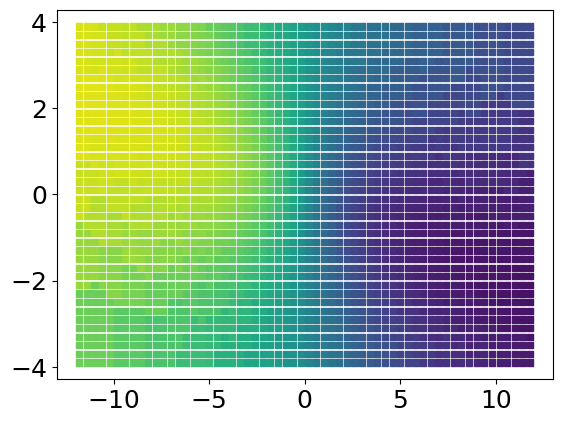

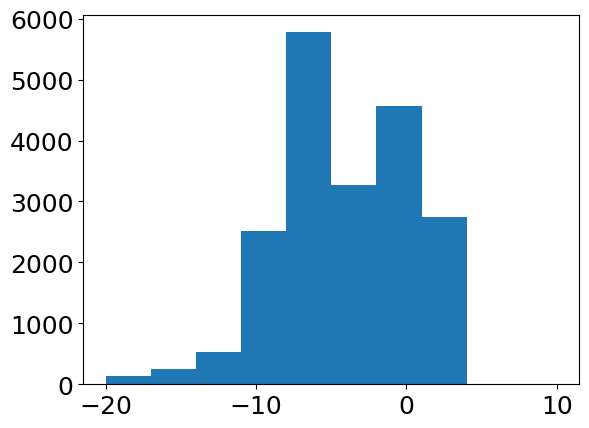

In [177]:
_v0 = v0[bin_mapping[:-1]]

plt.figure()
cb = plt.scatter(X_regular_grid, Y_regular_grid, c=_v0,
                s = 20, cmap='viridis', marker = 's', vmin = -200, vmax = 200)

plt.figure()
plt.hist(jnp.log(weights), range = [-20, 10]), weights,

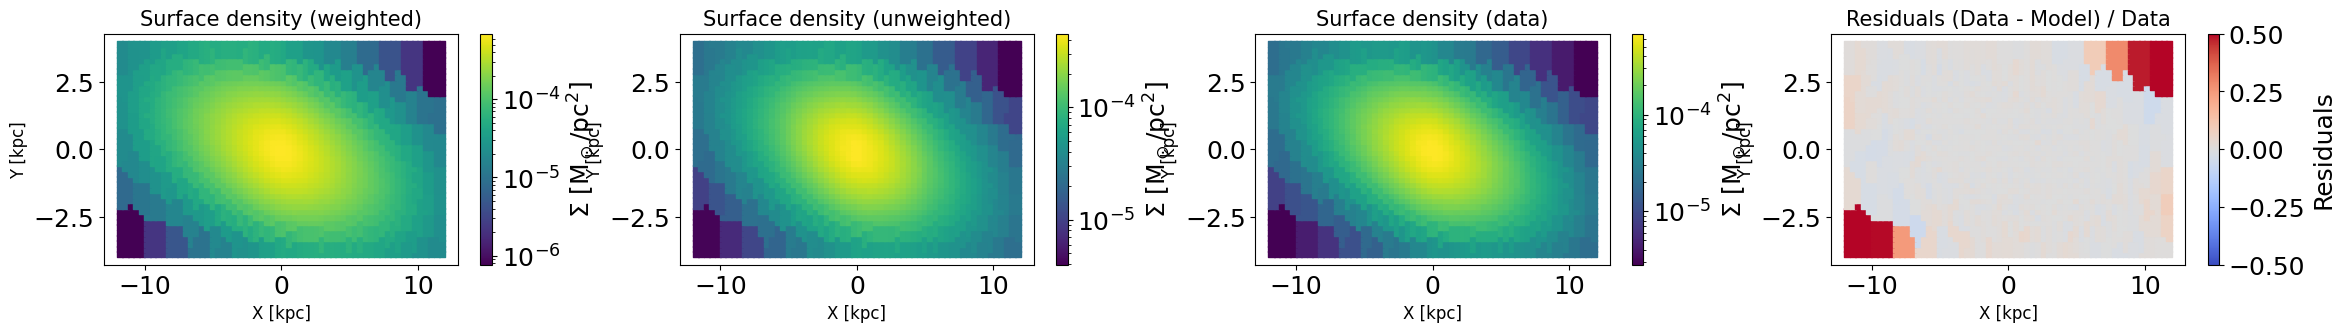

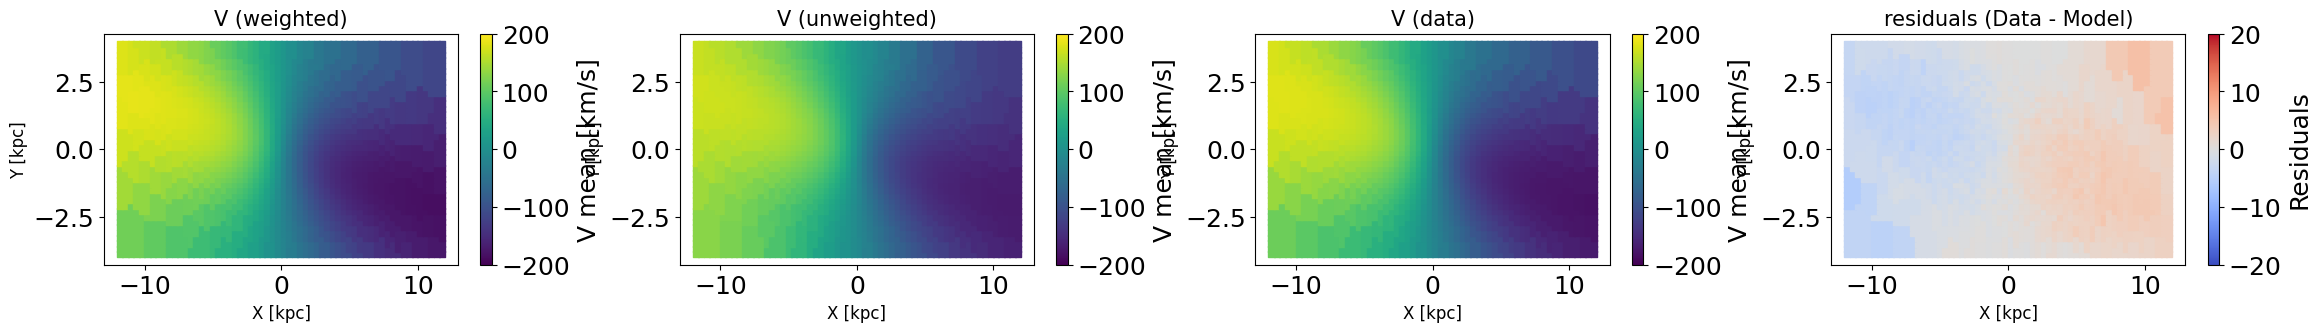

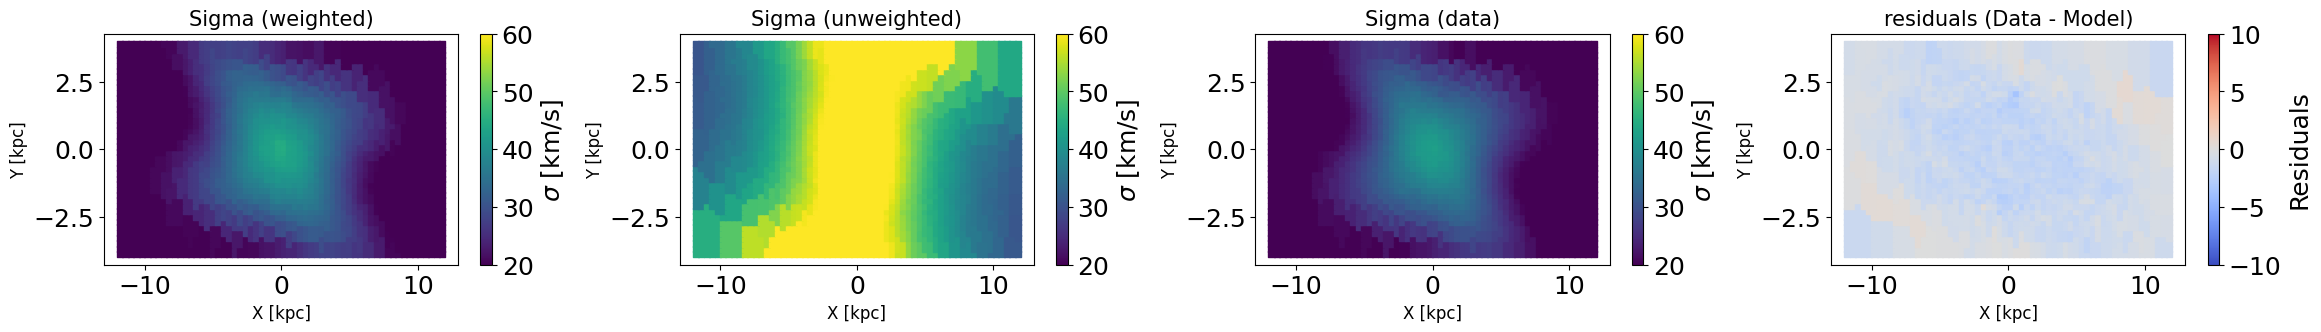

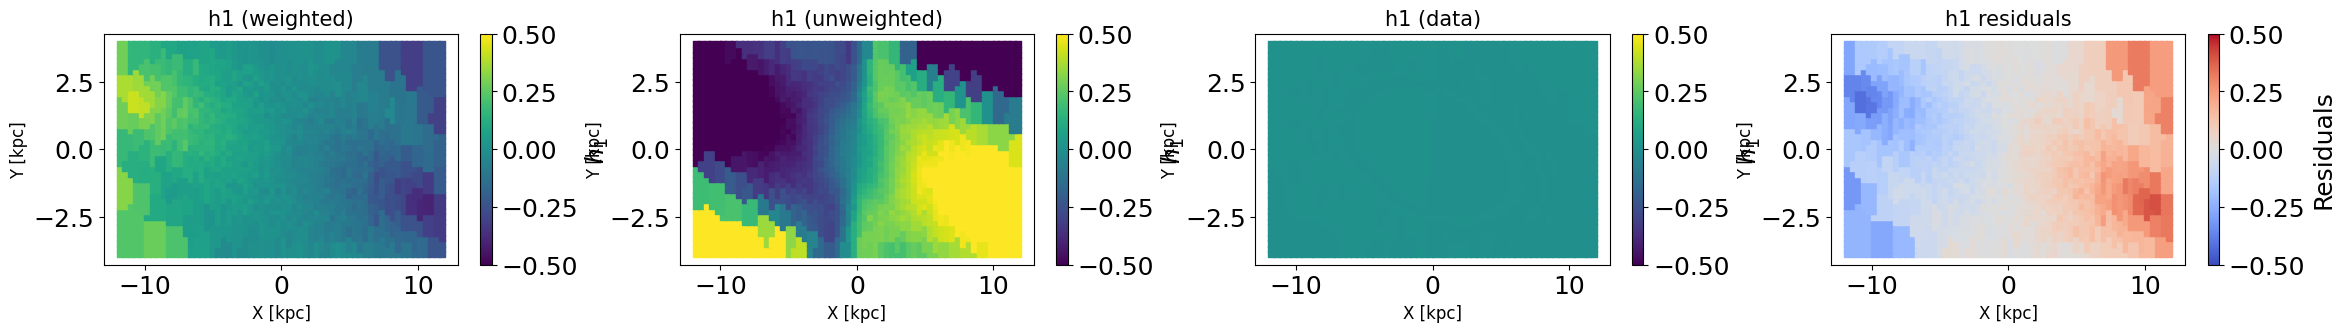

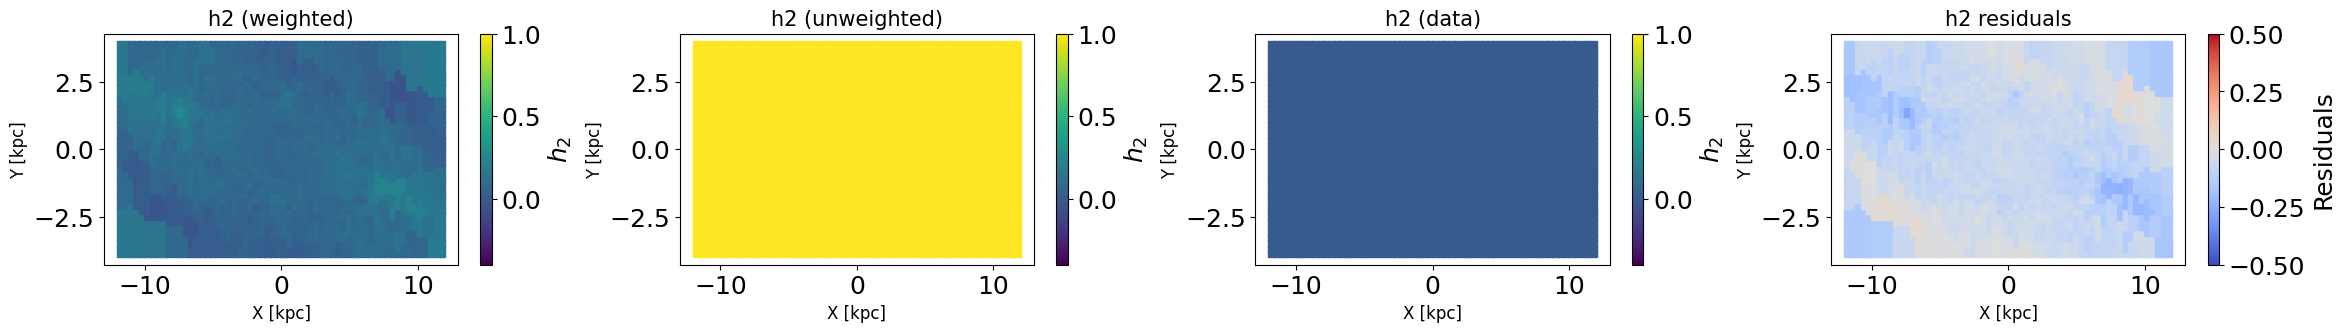

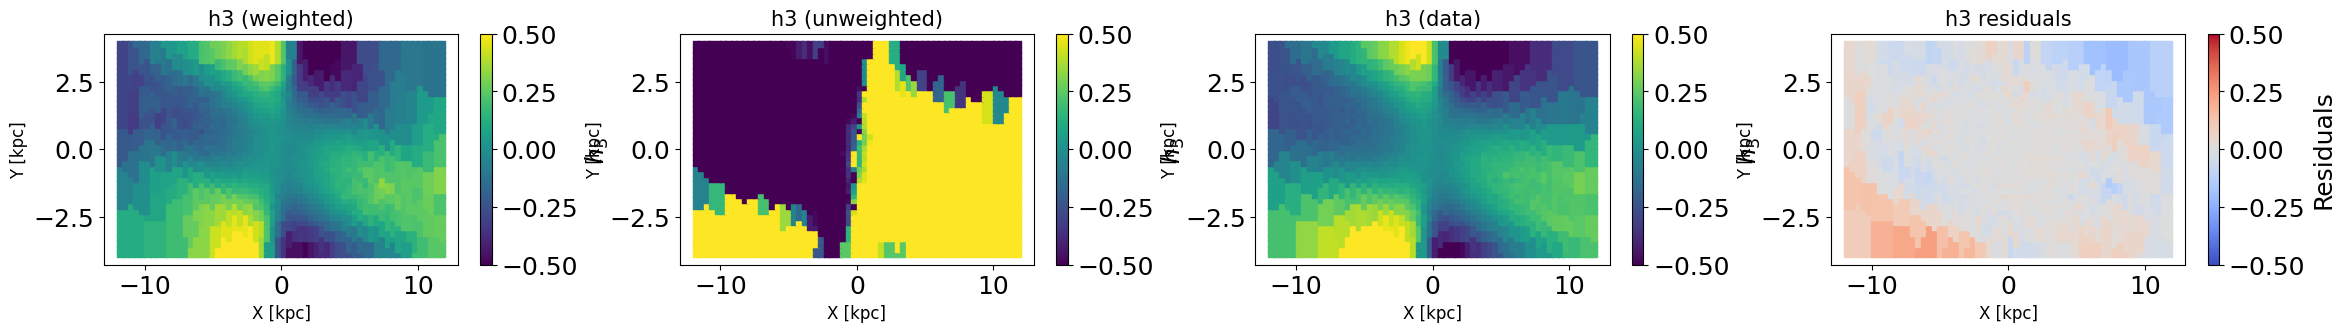

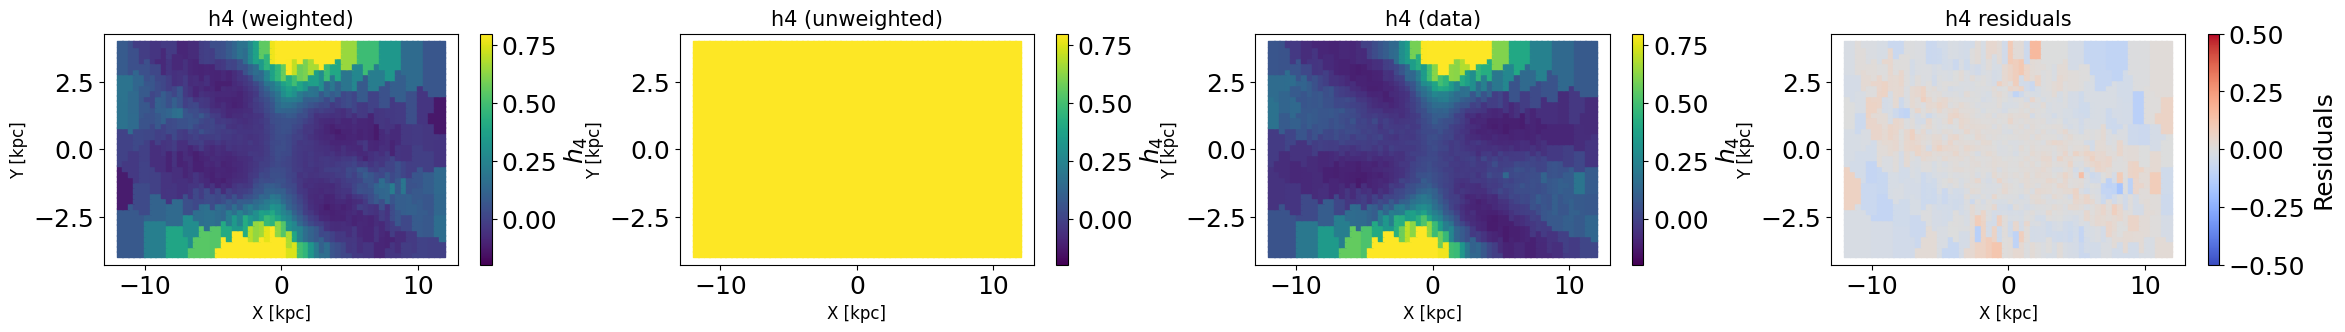

In [178]:
mean_mass_per_orb = jnp.sum(Rzphi_density_data) / A_Rzphi.shape[1]
index_remap = bin_mapping[:-1]

density_2DXY_weighted = density_2DXY[index_remap]
V_model_weighted = V_model[index_remap]
sigma_model_weighted = sigma_model[index_remap]
h1_model_weighted = h1_model[index_remap]
h2_model_weighted = h2_model[index_remap]
h3_model_weighted = h3_model[index_remap]
h4_model_weighted = h4_model[index_remap]

_density_2DXY_unity = density_2DXY_unity[index_remap]
_V_model_unity = V_model_unity[index_remap]
_sigma_model_unity = sigma_model_unity[index_remap]
_h1_model_unity = h1_model_unity[index_remap]
_h2_model_unity = h2_model_unity[index_remap]
_h3_model_unity = h3_model_unity[index_remap]
_h4_model_unity = h4_model_unity[index_remap]

density_2DXY_data = surface_density[index_remap]
V_model_data = V_data[index_remap]
sigma_model_data = sigma_data[index_remap]
h1_model_data = h1_data[index_remap]
h2_model_data = h2_data[index_remap]
h3_model_data = h3_data[index_remap]
h4_model_data = h4_data[index_remap]

# fig1,ax1 = plt.subplots(2,4,figsize=(30,7), gridspec_kw={'hspace':0.5, 'wspace':0.3})
# fig1.suptitle('2D spatial and kinematic maps in Voronoi bins', fontsize=20, y = 1.03)
# cb1 = ax1[0,0].scatter(X_regular_grid, Y_regular_grid, c=density_2DXY_weighted, 
#                 s = 20, cmap='viridis', marker = 's', norm = 'log')
# fig1.colorbar(cb1, ax=ax1[0,0], label=r'$\Sigma$ [M$_\odot$/pc$^2$]')
# ax1[0,0].set_title('Surface density')
# ax1[0,0].set_xlabel('X [kpc]')
# ax1[0,0].set_ylabel('Y [kpc]')

fig0, ax0 = plt.subplots(1,4, figsize = (28,3), gridspec_kw={'hspace':0.5, 'wspace':0.3})

cb = ax0[0].scatter(X_regular_grid, Y_regular_grid, c=density_2DXY_weighted,
                s = 20, cmap='viridis', marker = 's', norm = 'log')
ax0[0].set_title('Surface density (weighted)', fontsize=15)
ax0[0].set_xlabel('X [kpc]', fontsize=12)
ax0[0].set_ylabel('Y [kpc]', fontsize=12)
fig0.colorbar(cb, ax=ax0[0], label=r'$\Sigma$ [M$_\odot$/pc$^2$]')

cb = ax0[1].scatter(X_regular_grid, Y_regular_grid, c=_density_2DXY_unity,
                s = 20, cmap='viridis', marker = 's', norm = 'log')
ax0[1].set_title('Surface density (unweighted)', fontsize=15)
ax0[1].set_xlabel('X [kpc]', fontsize=12)
ax0[1].set_ylabel('Y [kpc]', fontsize=12)
fig0.colorbar(cb, ax=ax0[1], label=r'$\Sigma$ [M$_\odot$/pc$^2$]')

cb = ax0[2].scatter(X_regular_grid, Y_regular_grid, c=density_2DXY_data / mean_mass_per_orb,
                s = 20, cmap='viridis', marker = 's', norm = 'log')
ax0[2].set_title('Surface density (data)', fontsize=15)
ax0[2].set_xlabel('X [kpc]', fontsize=12)
ax0[2].set_ylabel('Y [kpc]', fontsize=12)
fig0.colorbar(cb, ax=ax0[2], label=r'$\Sigma$ [M$_\odot$/pc$^2$]')

res = (density_2DXY_data / mean_mass_per_orb - density_2DXY_weighted) / (density_2DXY_data / mean_mass_per_orb)
cb = ax0[3].scatter(X_regular_grid, Y_regular_grid, c=res,
                s = 20, cmap='coolwarm', marker = 's', vmin = -0.5, vmax = 0.5)
ax0[3].set_title('Residuals (Data - Model) / Data', fontsize=15)
ax0[3].set_xlabel('X [kpc]', fontsize=12)
ax0[3].set_ylabel('Y [kpc]', fontsize=12)
fig0.colorbar(cb, ax=ax0[3], label='Residuals')

# =============================================================================================

fig1, ax1 = plt.subplots(1,4, figsize = (28,3), gridspec_kw={'hspace':0.5, 'wspace':0.3})

cb = ax1[0].scatter(X_regular_grid, Y_regular_grid, c=V_model_weighted,
                s = 20, cmap='viridis', marker = 's', vmin = -200, vmax = 200)
ax1[0].set_title('V (weighted)', fontsize=15)
ax1[0].set_xlabel('X [kpc]', fontsize=12)
ax1[0].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[0], label=r'V mean [km/s]')

cb = ax1[1].scatter(X_regular_grid, Y_regular_grid, c=_V_model_unity,
                s = 20, cmap='viridis', marker = 's', vmin = -200, vmax = 200)
ax1[1].set_title('V (unweighted)', fontsize=15)
ax1[1].set_xlabel('X [kpc]', fontsize=12)
ax1[1].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[1], label=r'V mean [km/s]')

cb = ax1[2].scatter(X_regular_grid, Y_regular_grid, c=V_model_data,
                s = 20, cmap='viridis', marker = 's', vmin = -200, vmax = 200)
ax1[2].set_title('V (data)', fontsize=15)
ax1[2].set_xlabel('X [kpc]', fontsize=12)
ax1[2].set_ylabel('Y [kpc]', fontsize=12) 
fig1.colorbar(cb, ax=ax1[2], label=r'V mean [km/s]')

res = (V_model_data - V_model_weighted)
cb = ax1[3].scatter(X_regular_grid, Y_regular_grid, c=res,
                s = 20, cmap='coolwarm', marker = 's', vmin = -20, vmax = 20)
ax1[3].set_title('residuals (Data - Model)', fontsize=15)
ax1[3].set_xlabel('X [kpc]', fontsize=12)
ax1[3].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[3], label='Residuals')

# =============================================================================================

fig1, ax1 = plt.subplots(1,4, figsize = (28,3), gridspec_kw={'hspace':0.5, 'wspace':0.3})

cb = ax1[0].scatter(X_regular_grid, Y_regular_grid, c=sigma_model_weighted,
                s = 20, cmap='viridis', marker = 's', vmin = 20, vmax = 60)
ax1[0].set_title('Sigma (weighted)', fontsize=15)
ax1[0].set_xlabel('X [kpc]', fontsize=12)
ax1[0].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[0], label=r'$\sigma$ [km/s]')

cb = ax1[1].scatter(X_regular_grid, Y_regular_grid, c=_sigma_model_unity,
                s = 20, cmap='viridis', marker = 's', vmin = 20, vmax = 60)
ax1[1].set_title('Sigma (unweighted)', fontsize=15)
ax1[1].set_xlabel('X [kpc]', fontsize=12)
ax1[1].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[1], label=r'$\sigma$ [km/s]')

cb = ax1[2].scatter(X_regular_grid, Y_regular_grid, c=sigma_model_data,
                s = 20, cmap='viridis', marker = 's', vmin = 20, vmax = 60)
ax1[2].set_title('Sigma (data)', fontsize=15)
ax1[2].set_xlabel('X [kpc]', fontsize=12)
ax1[2].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[2], label=r'$\sigma$ [km/s]')

res = (sigma_model_data - sigma_model_weighted)
cb = ax1[3].scatter(X_regular_grid, Y_regular_grid, c=res,
                s = 20, cmap='coolwarm', marker = 's', vmin = -10, vmax = 10)
ax1[3].set_title('residuals (Data - Model)', fontsize=15)
ax1[3].set_xlabel('X [kpc]', fontsize=12)
ax1[3].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[3], label='Residuals')

# =============================================================================================

fig1, ax1 = plt.subplots(1,4, figsize = (28,3), gridspec_kw={'hspace':0.5, 'wspace':0.3})

cb = ax1[0].scatter(X_regular_grid, Y_regular_grid, c=h1_model_weighted,
                s = 20, cmap='viridis', marker = 's', vmin = -0.5, vmax = 0.5)
ax1[0].set_title('h1 (weighted)', fontsize=15)
ax1[0].set_xlabel('X [kpc]', fontsize=12)
ax1[0].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[0], label=r'$h_1$')

cb = ax1[1].scatter(X_regular_grid, Y_regular_grid, c=_h1_model_unity,
                s = 20, cmap='viridis', marker = 's', vmin = -0.5, vmax = 0.5)
ax1[1].set_title('h1 (unweighted)', fontsize=15)
ax1[1].set_xlabel('X [kpc]', fontsize=12)
ax1[1].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[1], label=r'$h_1$')

cb = ax1[2].scatter(X_regular_grid, Y_regular_grid, c=h1_model_data,
                s = 20, cmap='viridis', marker = 's', vmin = -0.5, vmax = 0.5)
ax1[2].set_title('h1 (data)', fontsize=15)
ax1[2].set_xlabel('X [kpc]', fontsize=12)
ax1[2].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[2], label=r'$h_1$')

res = (h1_model_data - h1_model_weighted)
cb = ax1[3].scatter(X_regular_grid, Y_regular_grid, c=res,
                s = 20, cmap='coolwarm', marker = 's', vmin = -0.5, vmax = 0.5)
ax1[3].set_title('h1 residuals', fontsize=15)
ax1[3].set_xlabel('X [kpc]', fontsize=12)
ax1[3].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[3], label='Residuals')

# =============================================================================================

fig1, ax1 = plt.subplots(1,4, figsize = (28,3), gridspec_kw={'hspace':0.5, 'wspace':0.3})

cb = ax1[0].scatter(X_regular_grid, Y_regular_grid, c=h2_model_weighted,
                s = 20, cmap='viridis', marker = 's', vmin = -0.4, vmax = 1)
ax1[0].set_title('h2 (weighted)', fontsize=15)
ax1[0].set_xlabel('X [kpc]', fontsize=12)
ax1[0].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[0], label=r'$h_2$')

cb = ax1[1].scatter(X_regular_grid, Y_regular_grid, c=_h2_model_unity,
                s = 20, cmap='viridis', marker = 's', vmin = -0.4, vmax = 1)
ax1[1].set_title('h2 (unweighted)', fontsize=15)
ax1[1].set_xlabel('X [kpc]', fontsize=12)
ax1[1].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[1], label=r'$h_2$')

cb = ax1[2].scatter(X_regular_grid, Y_regular_grid, c=h2_model_data,
                s = 20, cmap='viridis', marker = 's', vmin = -0.4, vmax = 1)
ax1[2].set_title('h2 (data)', fontsize=15)
ax1[2].set_xlabel('X [kpc]', fontsize=12)
ax1[2].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[2], label=r'$h_2$')

res = (h2_model_data - h2_model_weighted)
cb = ax1[3].scatter(X_regular_grid, Y_regular_grid, c=res,
                s = 20, cmap='coolwarm', marker = 's', vmin = -0.5, vmax = 0.5)
ax1[3].set_title('h2 residuals', fontsize=15)
ax1[3].set_xlabel('X [kpc]', fontsize=12)
ax1[3].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[3], label='Residuals')

# =============================================================================================

fig1, ax1 = plt.subplots(1,4, figsize = (28,3), gridspec_kw={'hspace':0.5, 'wspace':0.3})

cb = ax1[0].scatter(X_regular_grid, Y_regular_grid, c=h3_model_weighted,
                s = 20, cmap='viridis', marker = 's', vmin = -0.5, vmax = 0.5)
ax1[0].set_title('h3 (weighted)', fontsize=15)
ax1[0].set_xlabel('X [kpc]', fontsize=12)
ax1[0].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[0], label=r'$h_3$')

cb = ax1[1].scatter(X_regular_grid, Y_regular_grid, c=_h3_model_unity,
                s = 20, cmap='viridis', marker = 's', vmin = -0.5, vmax = 0.5)
ax1[1].set_title('h3 (unweighted)', fontsize=15)
ax1[1].set_xlabel('X [kpc]', fontsize=12)
ax1[1].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[1], label=r'$h_3$')

cb = ax1[2].scatter(X_regular_grid, Y_regular_grid, c=h3_model_data,
                s = 20, cmap='viridis', marker = 's', vmin = -0.5, vmax = 0.5)
ax1[2].set_title('h3 (data)', fontsize=15)
ax1[2].set_xlabel('X [kpc]', fontsize=12)
ax1[2].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[2], label=r'$h_3$')

res = (h3_model_data - h3_model_weighted)
cb = ax1[3].scatter(X_regular_grid, Y_regular_grid, c=res,
                s = 20, cmap='coolwarm', marker = 's', vmin = -0.5, vmax = 0.5)
ax1[3].set_title('h3 residuals', fontsize=15)
ax1[3].set_xlabel('X [kpc]', fontsize=12)
ax1[3].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[3], label='Residuals')

# =============================================================================================

fig1, ax1 = plt.subplots(1,4, figsize = (28,3), gridspec_kw={'hspace':0.5, 'wspace':0.3})

cb = ax1[0].scatter(X_regular_grid, Y_regular_grid, c=h4_model_weighted,
                s = 20, cmap='viridis', marker = 's', vmin = -0.2, vmax = 0.8)
ax1[0].set_title('h4 (weighted)', fontsize=15)
ax1[0].set_xlabel('X [kpc]', fontsize=12)
ax1[0].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[0], label=r'$h_4$')

cb = ax1[1].scatter(X_regular_grid, Y_regular_grid, c=_h4_model_unity,
                s = 20, cmap='viridis', marker = 's', vmin = -0.2, vmax = 0.8)
ax1[1].set_title('h4 (unweighted)', fontsize=15)
ax1[1].set_xlabel('X [kpc]', fontsize=12)
ax1[1].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[1], label=r'$h_4$')

cb = ax1[2].scatter(X_regular_grid, Y_regular_grid, c=h4_model_data,
                s = 20, cmap='viridis', marker = 's', vmin = -0.2, vmax = 0.8)
ax1[2].set_title('h4 (data)', fontsize=15)
ax1[2].set_xlabel('X [kpc]', fontsize=12)
ax1[2].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[2], label=r'$h_4$')

res = (h4_model_data - h4_model_weighted)
cb = ax1[3].scatter(X_regular_grid, Y_regular_grid, c=res,
                s = 20, cmap='coolwarm', marker = 's', vmin = -0.5, vmax = 0.5)
ax1[3].set_title('h4 residuals', fontsize=15)
ax1[3].set_xlabel('X [kpc]', fontsize=12)
ax1[3].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[3], label='Residuals')

In [115]:
A_xy.shape

(1051, 10000)

((array([ 137.,  622., 1575., 1409., 1203., 1039., 1061., 1275., 1197.,
          482.]),
  array([ 0.        ,  1.35868752,  2.71737504,  4.07606268,  5.43475008,
          6.79343748,  8.15212536,  9.51081276, 10.86950016, 12.22818756,
         13.58687496]),
  <BarContainer object of 10 artists>),
 Array([10.017187 ,  6.0582676,  5.791952 , ...,  1.9387985,  8.025369 ,
         4.768551 ], dtype=float32))

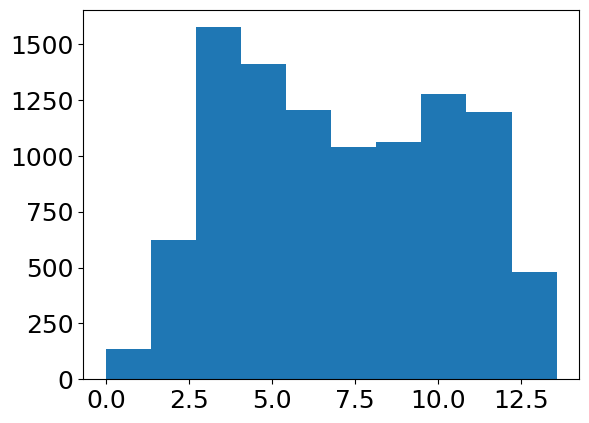

In [5]:
plt.hist(weights), weights

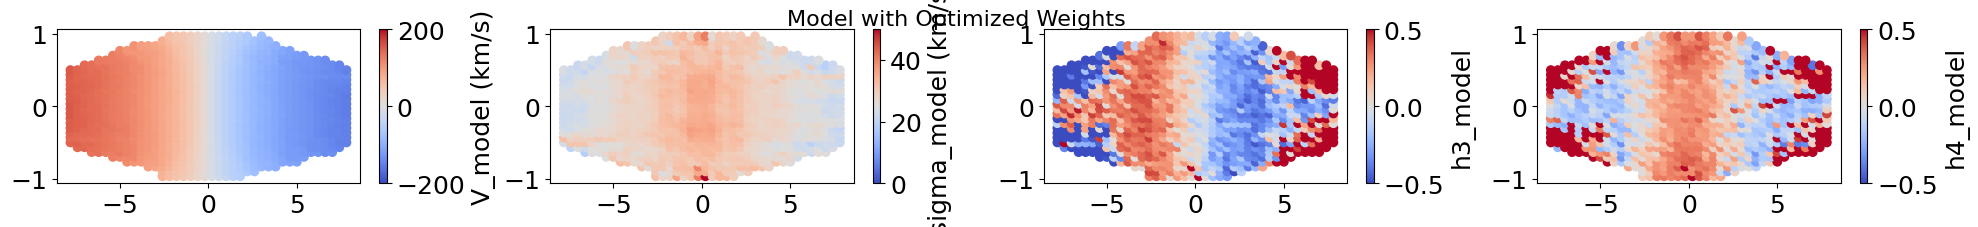

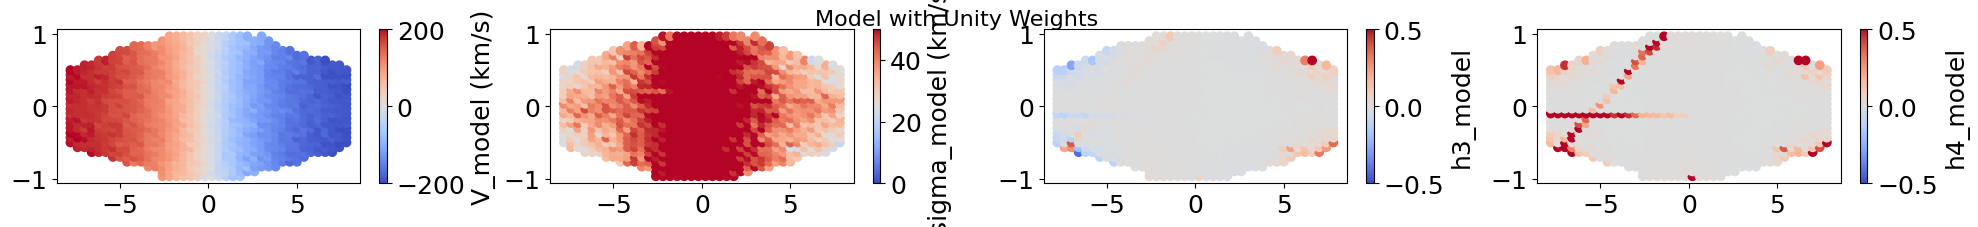

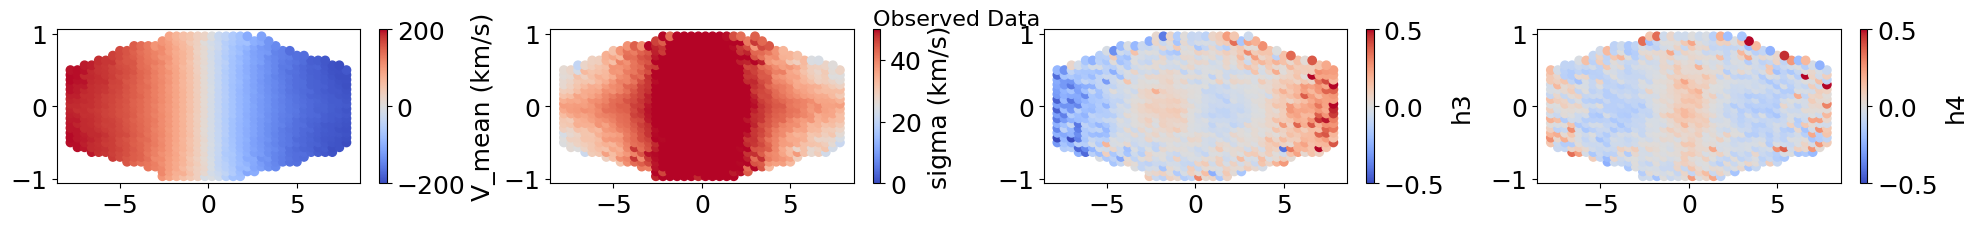

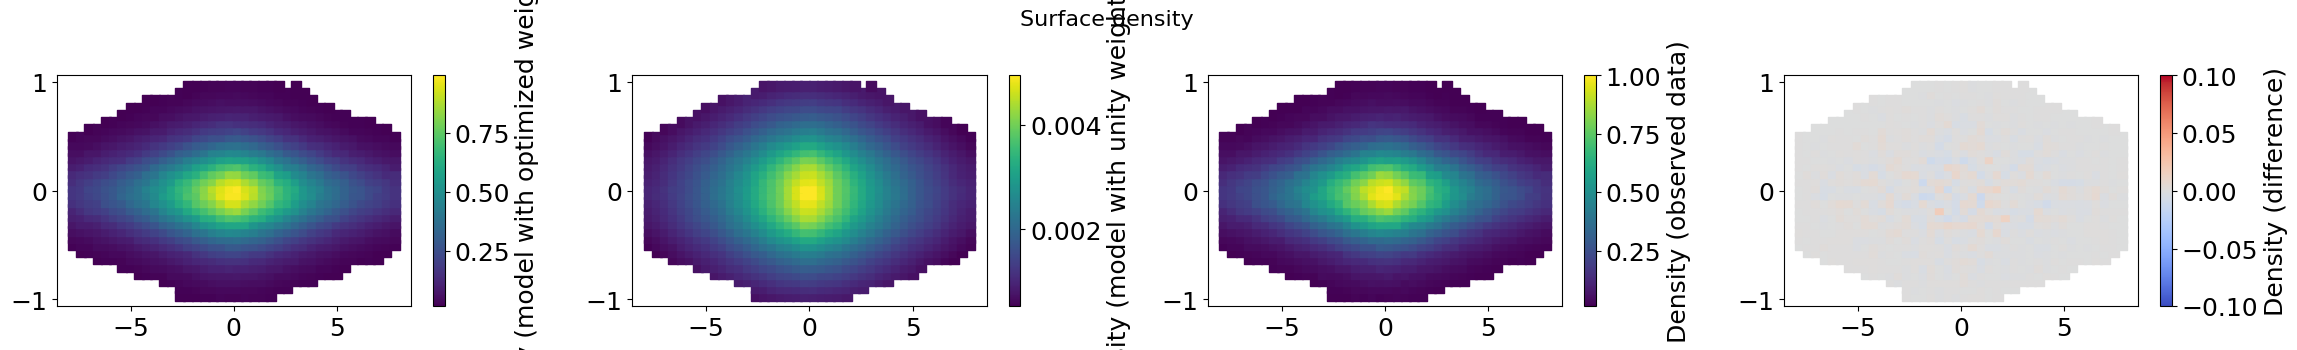

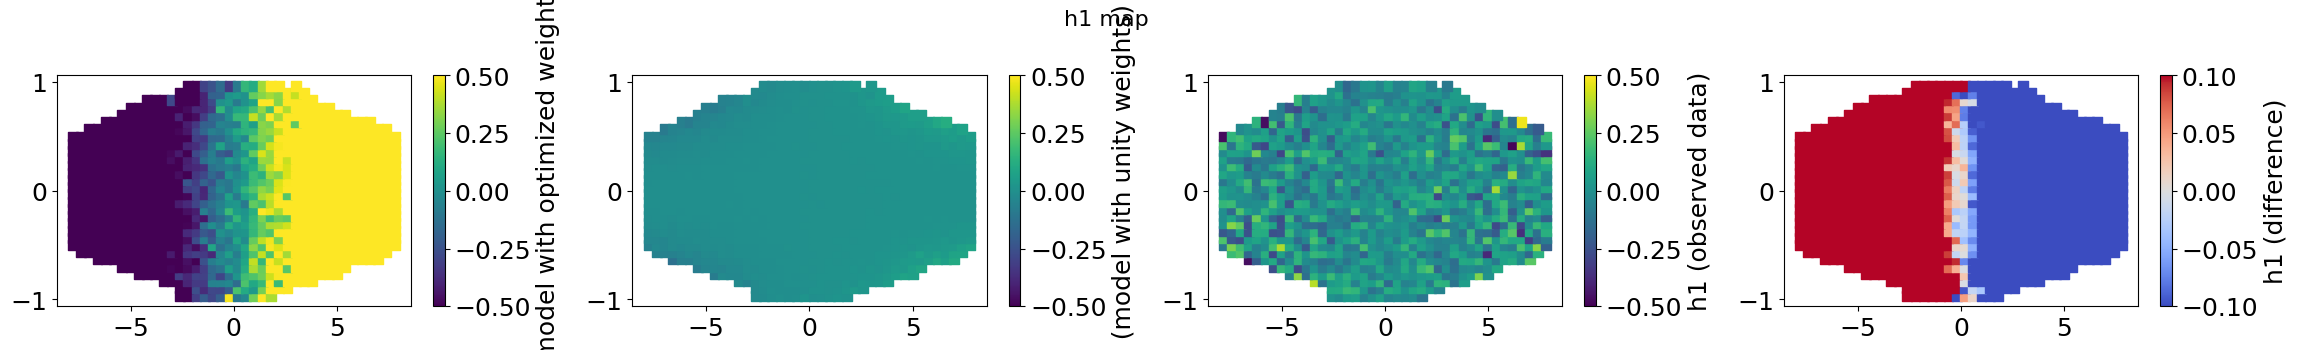

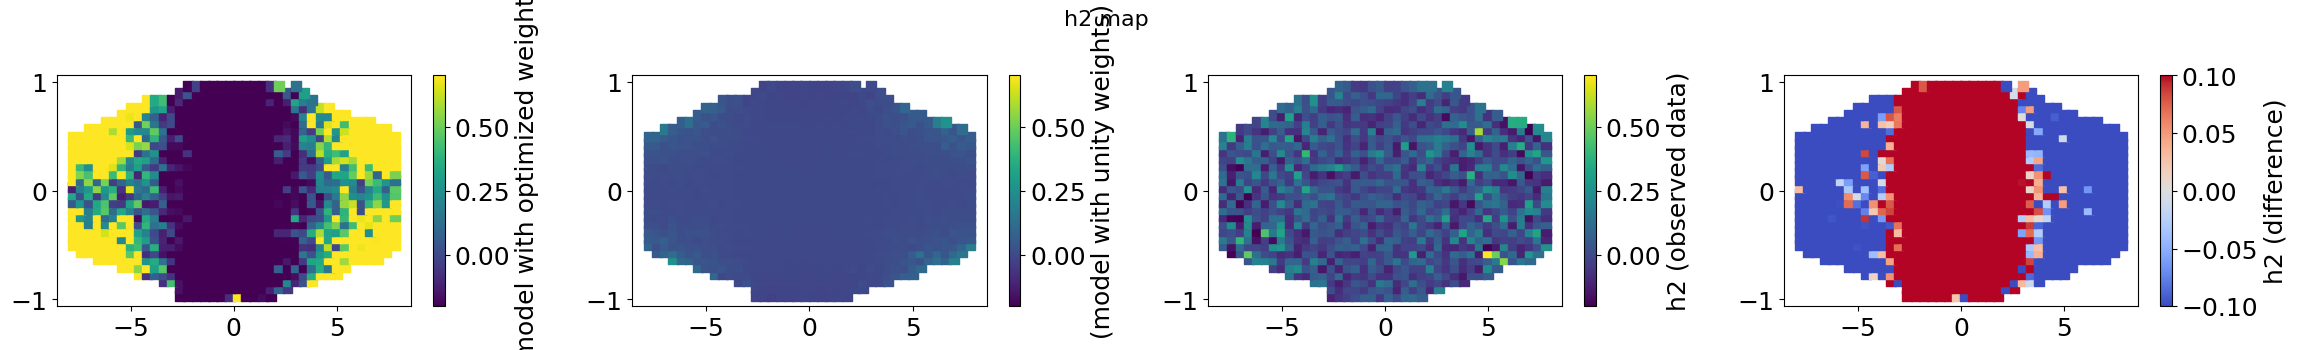

In [99]:
fig0, ax0 = plt.subplots(1,4, figsize=(24,2), gridspec_kw={'wspace': 0.3})
fig2, ax2 = plt.subplots(1,4, figsize=(24,2), gridspec_kw={'wspace': 0.3})
fig1, ax1 = plt.subplots(1,4, figsize=(24,2), gridspec_kw={'wspace': 0.3})

fig0.suptitle('Model with Optimized Weights', fontsize=16)
fig1.suptitle('Observed Data', fontsize=16)
fig2.suptitle('Model with Unity Weights', fontsize=16)

cb = ax0[0].scatter(df_XY_data['X_grid'][non_empty_index], df_XY_data['Y_grid'][non_empty_index], c=V_model, vmin=-200, vmax=200, cmap='coolwarm', rasterized = True)
fig0.colorbar(cb, ax=ax0[0], label='V_model (km/s)')

cb = ax2[0].scatter(df_XY_data['X_grid'][non_empty_index], df_XY_data['Y_grid'][non_empty_index], c=V_model_unity, vmin=-200, vmax=200, cmap='coolwarm', rasterized = True)
fig2.colorbar(cb, ax=ax2[0], label='V_model (km/s)')

cb = ax1[0].scatter(df_XY_data['X_grid'][non_empty_index], df_XY_data['Y_grid'][non_empty_index], c=df_XY_data['V_mean'][non_empty_index], vmin=-200, vmax=200, cmap='coolwarm', rasterized = True)
fig1.colorbar(cb, ax=ax1[0], label='V_mean (km/s)')


cb = ax0[1].scatter(df_XY_data['X_grid'][non_empty_index], df_XY_data['Y_grid'][non_empty_index], c=sigma_model, vmin=0, vmax=50, cmap='coolwarm', rasterized = True)
fig0.colorbar(cb, ax=ax0[1], label='sigma_model (km/s)')

cb = ax2[1].scatter(df_XY_data['X_grid'][non_empty_index], df_XY_data['Y_grid'][non_empty_index], c=sigma_model_unity, vmin=0, vmax=50, cmap='coolwarm', rasterized = True)
fig2.colorbar(cb, ax=ax2[1], label='sigma_model (km/s)')

cb = ax1[1].scatter(df_XY_data['X_grid'][non_empty_index], df_XY_data['Y_grid'][non_empty_index], c=df_XY_data['V_sigma'][non_empty_index], vmin=0, vmax=50, cmap='coolwarm', rasterized = True)
fig1.colorbar(cb, ax=ax1[1], label='sigma (km/s)')


cb = ax0[2].scatter(df_XY_data['X_grid'][non_empty_index], df_XY_data['Y_grid'][non_empty_index], c=h3_model, vmin=-0.5, vmax=0.5, cmap='coolwarm', rasterized = True)
fig0.colorbar(cb, ax=ax0[2], label='h3_model')

cb = ax2[2].scatter(df_XY_data['X_grid'][non_empty_index], df_XY_data['Y_grid'][non_empty_index], c=h3_model_unity, vmin=-0.5, vmax=0.5, cmap='coolwarm', rasterized = True)
fig2.colorbar(cb, ax=ax2[2], label='h3_model')

cb = ax1[2].scatter(df_XY_data['X_grid'][non_empty_index], df_XY_data['Y_grid'][non_empty_index], c=df_XY_data['h3'][non_empty_index], vmin=-0.5, vmax=0.5, cmap='coolwarm', rasterized = True)
fig1.colorbar(cb, ax=ax1[2], label='h3')


cb = ax0[3].scatter(df_XY_data['X_grid'][non_empty_index], df_XY_data['Y_grid'][non_empty_index], c=h4_model, vmin=-0.5, vmax=0.5, cmap='coolwarm', rasterized = True)
fig0.colorbar(cb, ax=ax0[3], label='h4_model')

cb = ax2[3].scatter(df_XY_data['X_grid'][non_empty_index], df_XY_data['Y_grid'][non_empty_index], c=h4_model_unity, vmin=-0.5, vmax=0.5, cmap='coolwarm', rasterized = True)
fig2.colorbar(cb, ax=ax2[3], label='h4_model')

cb = ax1[3].scatter(df_XY_data['X_grid'][non_empty_index], df_XY_data['Y_grid'][non_empty_index], c=df_XY_data['h4'][non_empty_index], vmin=-0.5, vmax=0.5, cmap='coolwarm', rasterized = True)
fig1.colorbar(cb, ax=ax1[3], label='h4')

fig3, ax3 = plt.subplots(1,4, figsize=(28,3), gridspec_kw={'wspace': 0.3})
fig3.suptitle('Surface density', fontsize=16, y = 1.1)

cb = ax3[0].scatter(df_XY_data['X_grid'][non_empty_index], df_XY_data['Y_grid'][non_empty_index], c=density_2DXY, 
cmap='viridis', s = 50, marker = 's', rasterized = True)
fig3.colorbar(cb, ax=ax3[0], label='Density (model with optimized weights)')

cb = ax3[1].scatter(df_XY_data['X_grid'][non_empty_index], df_XY_data['Y_grid'][non_empty_index], c=density_2DXY_unity, 
cmap='viridis', s = 50, marker = 's', rasterized = True)
fig3.colorbar(cb, ax=ax3[1], label='Density (model with unity weights)')

gt_density = dict_data['XY_density_data'][non_empty_index] / jnp.amax(dict_data['XY_density_data'][non_empty_index])
cb = ax3[2].scatter(df_XY_data['X_grid'][non_empty_index], df_XY_data['Y_grid'][non_empty_index], c=gt_density, 
cmap='viridis', s = 50, marker = 's', rasterized = True)
fig3.colorbar(cb, ax=ax3[2], label='Density (observed data)')

cb = ax3[3].scatter(df_XY_data['X_grid'][non_empty_index], df_XY_data['Y_grid'][non_empty_index], c = gt_density - density_2DXY,
                    cmap = 'coolwarm', s = 50, marker = 's', vmin = -0.1, vmax = 0.1, rasterized = True)
fig3.colorbar(cb, ax=ax3[3], label='Density (difference)')

fig4, ax4 = plt.subplots(1,4, figsize=(28,3), gridspec_kw={'wspace': 0.3})
fig4.suptitle('h1 map', fontsize=16, y = 1.1)

cb = ax4[0].scatter(df_XY_data['X_grid'][non_empty_index], df_XY_data['Y_grid'][non_empty_index], c=h1_model, 
cmap='viridis', s = 50, marker = 's', rasterized = True, vmin = -0.5, vmax = 0.5)
fig4.colorbar(cb, ax=ax4[0], label='h1 (model with optimized weights)')

cb = ax4[1].scatter(df_XY_data['X_grid'][non_empty_index], df_XY_data['Y_grid'][non_empty_index], c=h1_model_unity, 
cmap='viridis', s = 50, marker = 's', rasterized = True, vmin = -0.5, vmax = 0.5)
fig4.colorbar(cb, ax=ax4[1], label='h1 (model with unity weights)')

gt_h1 = dict_data['h1_data'][non_empty_index]# / jnp.amax(jnp.fabs(dict_data['h1_data'][non_empty_index]))
cb = ax4[2].scatter(df_XY_data['X_grid'][non_empty_index], df_XY_data['Y_grid'][non_empty_index], c=gt_h1,
cmap='viridis', s = 50, marker = 's', rasterized = True, vmin = -0.5, vmax = 0.5)
fig4.colorbar(cb, ax=ax4[2], label='h1 (observed data)')

cb = ax4[3].scatter(df_XY_data['X_grid'][non_empty_index], df_XY_data['Y_grid'][non_empty_index], c = gt_h1 - h1_model,
                    cmap = 'coolwarm', s = 50, marker = 's', vmin = -0.1, vmax = 0.1, rasterized = True)
fig4.colorbar(cb, ax=ax4[3], label='h1 (difference)')

fig5, ax5 = plt.subplots(1,4, figsize=(28,3), gridspec_kw={'wspace': 0.3})
fig5.suptitle('h2 map', fontsize=16, y = 1.1)

cb = ax5[0].scatter(df_XY_data['X_grid'][non_empty_index], df_XY_data['Y_grid'][non_empty_index], c=h2_model, 
cmap='viridis', s = 50, marker = 's', rasterized = True, vmin = -0.2, vmax = 0.7)
fig5.colorbar(cb, ax=ax5[0], label='h2 (model with optimized weights)')

cb = ax5[1].scatter(df_XY_data['X_grid'][non_empty_index], df_XY_data['Y_grid'][non_empty_index], c=h2_model_unity, 
cmap='viridis', s = 50, marker = 's', rasterized = True, vmin = -0.2, vmax = 0.7)
fig5.colorbar(cb, ax=ax5[1], label='h2 (model with unity weights)')

gt_h2 = dict_data['h2_data'][non_empty_index]# / jnp.amax(jnp.fabs(dict_data['h2_data'][non_empty_index]))
cb = ax5[2].scatter(df_XY_data['X_grid'][non_empty_index], df_XY_data['Y_grid'][non_empty_index], c=gt_h2,
cmap='viridis', s = 50, marker = 's', rasterized = True, vmin = -0.2, vmax = 0.7)
fig5.colorbar(cb, ax=ax5[2], label='h2 (observed data)')

cb = ax5[3].scatter(df_XY_data['X_grid'][non_empty_index], df_XY_data['Y_grid'][non_empty_index], c = gt_h2 - h2_model,
                    cmap = 'coolwarm', s = 50, marker = 's', vmin = -0.1, vmax = 0.1, rasterized = True)
fig5.colorbar(cb, ax=ax5[3], label='h2 (difference)')

# Test for methodology --- assuming we know the solution

In [61]:
# Generate an orbital library first

# @jax.jit
def integrate(params_halo_pot, params_disk_rho, dict_data):

    w0 = dict_data['w0']
    n_particles = w0.shape[0]
    v0 = dict_data['v0']
    s = dict_data['s']

    #=========================================== GET DISC POTENTIAL =====================================================

    NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax = 50, 30, 1e-2, 30.0, 1e-3, 15.0, 8.
    Nphi = 200
    N_int = 10_000
    dict_phi = get_phi_m(MiyamotoNagai_density, params_disk_rho, NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax, Nphi, N_int)

    #=========================================== GET INITIAL VELOCITY ===================================================

    get_jeans_moments_vmap = jax.vmap(get_jeans_moments, in_axes=(0,0,0,None,None,None,None))
    # jeans_moments = get_jeans_moments(x_p, y_p, z_p, dict_phi, params_disk_rho,params_halo_pot, anisotropy_b=1.0)
    jeans_moments = get_jeans_moments_vmap(w0[:,0], w0[:,1], w0[:,2], dict_phi, params_disk_rho, params_halo_pot, 1.)

    v_rot, sig_R, sig_z, sig_phi = jeans_moments
    key1, key2, key3 = jax.random.PRNGKey(42), jax.random.PRNGKey(109), jax.random.PRNGKey(2026)
    g1, g2, g3 = jax.random.normal(key1, (n_particles,)), jax.random.normal(key2, (n_particles,)), jax.random.normal(key3, (n_particles,))
    vR = g1 * sig_R
    vz = g2 * sig_z
    vphi = v_rot + g3 * sig_phi

    x, y, vx, vy = getCartesianFromCylindrical_clockwise(jnp.sqrt(w0[:,0]**2 + w0[:,1]**2), jnp.arctan2(w0[:,1], w0[:,0]), vR, vphi)

    w0_new = jnp.array([x, y, w0[:,2], vx, vy, vz]).T

    #=========================================== Integrate orbits =======================================================
    @jax.jit
    def acc_fn(x, y, z):
        a_halo = NFW_acceleration(x, y, z,  params_halo_pot)
        a_disk = get_acc(x, y, z, dict_phi)
        return a_halo + a_disk

    time = 10. #Gyr
    n_steps = 5000
    dt = time / n_steps
    unroll = False
    initial_time = 0.0

    Rzphi_bin_counts, Nxy, h1, h2, h3, h4 = jax.vmap(integrate_leapfrog_grid, in_axes=(0, None, None, None, None, None, None, None, None, None, None, None, None, None))\
                        (w0_new, acc_fn, n_steps, dt, initial_time, unroll,
                        jnp.array([[0,10.],[-1.5,1.5],[-jnp.pi, jnp.pi]]), jnp.array([[-8.,8.],[-1.,1.]]),
                        jnp.array([10,6,6]), jnp.array([40,30]), 360, 1200,
                        v0, s)

    # jax.debug.print("h1 shape: {x_norm}", x_norm=h1.shape)
    # jax.debug.print("h1 nan: {x_norm}", x_norm=jnp.isnan(h1).sum())
    # print("h1 shape: {x_norm}",h1.shape)
    # print("h1 nan: {x_norm}",jnp.isnan(h1).sum())
    # print("h1 non zero: {x_norm}",(h1!=0).sum())
    # print("h2 shape: {x_norm}",h2.shape)
    # print("h2 nan: {x_norm}",jnp.isnan(h2).sum())
    # print("h2 non zero: {x_norm}",(h2!=0).sum())
    # print("h3 shape: {x_norm}",h3.shape)
    # print("h3 nan: {x_norm}",jnp.isnan(h3).sum())
    # print("h3 non zero: {x_norm}",(h3!=0).sum())
    # print("h4 shape: {x_norm}",h4.shape)
    # print("h4 nan: {x_norm}",jnp.isnan(h4).sum())
    # print("h4 non zero: {x_norm}",(h4!=0).sum())
    # print("Nxy nan: {x_norm}",jnp.isnan(Nxy).sum())
    # print("Nxy non zero: {x_norm}",(Nxy!=0).sum())
    #=========================================== Orbital weights optimisation ============================================
    A_Rzphi = Rzphi_bin_counts.T# / n_steps
    A_xy = Nxy.T# / n_steps
    A_h1 = h1.T
    A_h2 = h2.T
    A_h3 = h3.T
    A_h4 = h4.T

    return A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4, v0, s


# @jax.jit
def integrate_without_binning(params_halo_pot, params_disk_rho, dict_data):

    w0 = dict_data['w0']
    n_particles = w0.shape[0]
    v0 = dict_data['v0']
    s = dict_data['s']

    #=========================================== GET DISC POTENTIAL =====================================================

    NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax = 50, 30, 1e-2, 30.0, 1e-3, 15.0, 8.
    Nphi = 200
    N_int = 10_000
    dict_phi = get_phi_m(MiyamotoNagai_density, params_disk_rho, NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax, Nphi, N_int)

    #=========================================== GET INITIAL VELOCITY ===================================================

    get_jeans_moments_vmap = jax.vmap(get_jeans_moments, in_axes=(0,0,0,None,None,None,None))
    # jeans_moments = get_jeans_moments(x_p, y_p, z_p, dict_phi, params_disk_rho,params_halo_pot, anisotropy_b=1.0)
    jeans_moments = get_jeans_moments_vmap(w0[:,0], w0[:,1], w0[:,2], dict_phi, params_disk_rho, params_halo_pot, 1.)

    v_rot, sig_R, sig_z, sig_phi = jeans_moments
    key1, key2, key3 = jax.random.PRNGKey(42), jax.random.PRNGKey(109), jax.random.PRNGKey(2026)
    g1, g2, g3 = jax.random.normal(key1, (n_particles,)), jax.random.normal(key2, (n_particles,)), jax.random.normal(key3, (n_particles,))
    vR = g1 * sig_R
    vz = g2 * sig_z
    vphi = v_rot + g3 * sig_phi

    x, y, vx, vy = getCartesianFromCylindrical_clockwise(jnp.sqrt(w0[:,0]**2 + w0[:,1]**2), jnp.arctan2(w0[:,1], w0[:,0]), vR, vphi)

    w0_new = jnp.array([x, y, w0[:,2], vx, vy, vz]).T

    #=========================================== Integrate orbits =======================================================
    @jax.jit
    def acc_fn(x, y, z):
        a_halo = NFW_acceleration(x, y, z,  params_halo_pot)
        a_disk = get_acc(x, y, z, dict_phi)
        return a_halo + a_disk

    time = 10. #Gyr
    n_steps = 5000
    dt = time / n_steps
    unroll = False
    initial_time = 0.0

    time, xv = jax.vmap(integrate_leapfrog_traj, in_axes=(0, None, None, None, None, None))(w0_new, acc_fn, n_steps, dt, initial_time, unroll)
    
    return time, xv

with open(path + 'IC_axisymmetric_disc.pkl', 'rb') as f:
    ic = pickle.load(f)

n_particles =  10_000

print(n_particles)
np.random.seed(42)
index = np.random.choice(len(ic['x']), size=n_particles, replace=False)
w0 = jnp.array([ic['x'][index], ic['y'][index], ic['z'][index], ic['vx'][index], ic['vy'][index], ic['vz'][index]]).T
# w0 = jnp.array([ic['x'], ic['y'], ic['z'], ic['vx'], ic['vy'], ic['vz']]).T

with open(path + 'axisymmetric_disc.pkl', 'rb') as f:
    data = pickle.load(f)

df_Rzphi_data = pd.read_csv(path + 'axisymmetric_disc_Rzphi.csv')
df_XY_data = pd.read_csv(path + 'axisymmetric_disc_XY_kine.csv')

Rzphi_density_data = jnp.array(df_Rzphi_data['N_count'].to_numpy()).astype(jnp.float32)
XY_density_data = jnp.array(df_XY_data['N_count'].to_numpy()).astype(jnp.float32)
V_data = jnp.array(df_XY_data['V_mean'].to_numpy()).astype(jnp.float32)
V_data_err = jnp.array(0.1 * df_XY_data['V_mean'].to_numpy() + 1.0).astype(jnp.float32)
sigma_data = jnp.array(df_XY_data['V_sigma'].to_numpy()).astype(jnp.float32)
sigma_data_err = jnp.array(0.1 * df_XY_data['V_sigma'].to_numpy() + 1.0).astype(jnp.float32)
h1_data = jnp.array(df_XY_data['h1'].to_numpy()).astype(jnp.float32)
h1_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h1'].to_numpy()) + 0.1).astype(jnp.float32)
h2_data = jnp.array(df_XY_data['h2'].to_numpy()).astype(jnp.float32)
h2_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h2'].to_numpy()) + 0.1).astype(jnp.float32)
h3_data = jnp.array(df_XY_data['h3'].to_numpy()).astype(jnp.float32)
h3_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h3'].to_numpy()) + 0.1).astype(jnp.float32)
h4_data = jnp.array(df_XY_data['h4'].to_numpy()).astype(jnp.float32)
h4_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h4'].to_numpy()) + 0.1).astype(jnp.float32)
v0 = jnp.array(df_XY_data['v0_cell'].to_numpy()).astype(jnp.float32)
s = jnp.array(df_XY_data['s_cell'].to_numpy()).astype(jnp.float32)

non_empty_index = jnp.where(df_XY_data['nonempty'].to_numpy())[0]



dict_data = {
    'w0': w0,
    'v0': v0,
    's': s,
    'Rzphi_density_data': Rzphi_density_data,
    'XY_density_data': XY_density_data,
    'V_data': V_data,
    'V_data_err': V_data_err,
    'sigma_data': sigma_data,
    'sigma_data_err': sigma_data_err,
    'h1_data': h1_data,
    'h1_data_err': h1_data_err,
    'h2_data': h2_data,
    'h2_data_err': h2_data_err,
    'h3_data': h3_data,
    'h3_data_err': h3_data_err,
    'h4_data': h4_data,
    'h4_data_err': h4_data_err,
    'non_empty_index': non_empty_index
}

N = 20
i = 16
ground_truth = {
        'logM_halo': jnp.log10(0.8*10**12).item() + (i-N/2)/10,
        'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
        'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
        'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
        'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
}

params_halo_pot = {
    'logM': ground_truth['logM_halo'],
    'Rs':10 ** ground_truth['logRs_halo'],
    'a':1.0,
    'b':1.0,
    'c':1.0,
    'x_origin':0.0,
    'y_origin':0.0,
    'z_origin':0.0,
    'dirx':0.0,
    'diry':0.0,
    'dirz':1.0
}

params_disk_rho = {
    'logM': ground_truth['logM_disk'],
    'Rs': 10 ** ground_truth['logRs_disk'],
    'Hs': 10 ** ground_truth['logHs_disk'],
    'x_origin': 0.0,
    'y_origin': 0.0,
    'z_origin': 0.0,
    'dirx': 0.0,
    'diry': 0.0,
    'dirz': 1.0
}

A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4, v0, s = integrate(
    params_halo_pot,
    params_disk_rho,
    dict_data
)

time, xv = integrate_without_binning(
    params_halo_pot,
    params_disk_rho,
    dict_data
)

10000


(array([ 860., 1285., 2094., 2316., 1869., 1012.,  408.,  129.,   23.,
           4.]),
 array([0.05      , 0.93949628, 1.82899249, 2.71848869, 3.60798502,
        4.49748135, 5.38697767, 6.27647352, 7.16596985, 8.05546665,
        8.9449625 ]),
 <BarContainer object of 10 artists>)

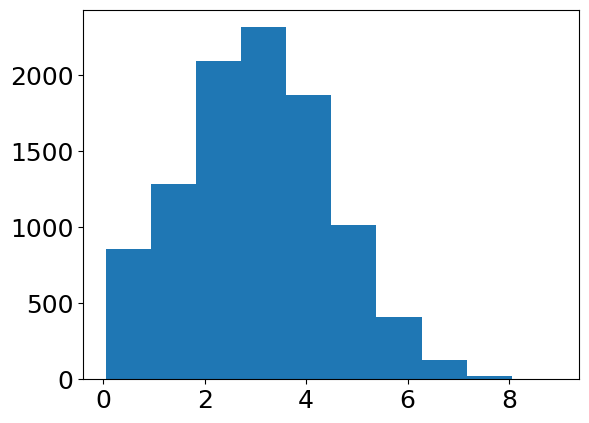

In [62]:
# Generate some random weights for testing
np.random.seed(4316423)
weights = jnp.array(np.random.normal(3, 1.5, size=xv.shape[0]))
weights = jnp.clip(weights, a_min=0.05, a_max=None)
weights_stacked = jnp.repeat(weights[:, jnp.newaxis], xv.shape[1], axis=1)
weights_stacked = weights_stacked.flatten()

plt.hist(weights)

Total counts in Rzphi bins: 360 and only 1 per bin: True
Total counts in XY bins: 1200 and only 1 per bin: True


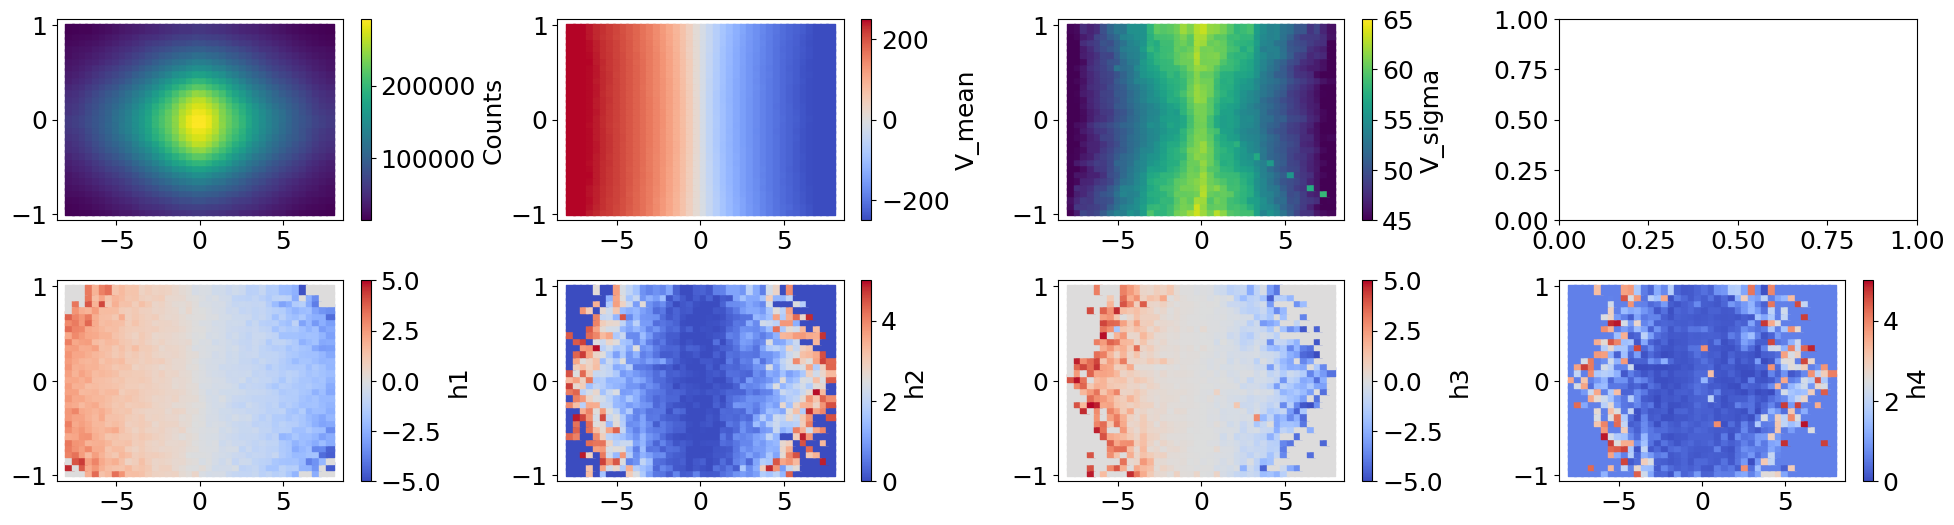

In [78]:
# Generate mock observed data from the integrated orbits with weights
R_min, R_max =0., 10.
z_min, z_max = -1.5, 1.5
n_R, n_z, n_phi =10, 6, 6

R_edge = jnp.linspace(R_min, R_max, n_R+1)
z_edge = jnp.linspace(z_min, z_max, n_z+1)
phi_edge = jnp.linspace(-jnp.pi, jnp.pi, n_phi+1)
R_mids, z_mids, phi_mids = 0.5 * (R_edge[:-1] + R_edge[1:]), 0.5 * (z_edge[:-1] + z_edge[1:]), 0.5 * (phi_edge[:-1] + phi_edge[1:])
dR, dz, dphi = R_edge[1]-R_edge[0], z_edge[1]-z_edge[0], phi_edge[1]-phi_edge[0]

R_mids_mesh, z_mids_mesh, phi_mids_mesh = jnp.meshgrid(R_mids, z_mids, phi_mids, indexing='ij')

Rzphi_mid_grid = jnp.stack([R_mids_mesh.ravel(), z_mids_mesh.ravel(), phi_mids_mesh.ravel()], axis=-1)  # (n_R*n_z*n_phi, 3)

# Get the central point of each bin
Rzphi_minmax=jnp.array([[R_min, R_max],[z_min, z_max],[-jnp.pi, jnp.pi]])
nRzphi=jnp.array([n_R,n_z,n_phi])
num_segments_Rzphi=nRzphi.prod()
Rzphi_strides = jnp.concatenate([jnp.array([1]), jnp.cumprod(nRzphi[:-1])])
Rzphi_grid_indices = assign_regular_grid(Rzphi_mid_grid,
                                    grid_min=Rzphi_minmax[:,0],
                                    grid_max=Rzphi_minmax[:,1],
                                    n_bins=nRzphi,
                                    strides=Rzphi_strides)
# Grid id of Rzphi_grid_indices has the corresponding center Rzphi_mid_grid
_, COUNTS = jnp.unique(Rzphi_grid_indices, return_counts=True)
print('Total counts in Rzphi bins:', jnp.sum(COUNTS), 'and only 1 per bin:', jnp.all(COUNTS <= 1))

df_Rzphi = pd.DataFrame({
    'id': Rzphi_grid_indices,
    'R_grid': Rzphi_mid_grid[:,0],
    'z_grid': Rzphi_mid_grid[:,1],
    'phi_grid': Rzphi_mid_grid[:,2],
})

Rzphi_stars = jnp.array([
            jnp.sqrt(xv[:,:,0].flatten()**2 + xv[:,:,1].flatten()**2),
            xv[:,:,2].flatten(),
            jnp.arctan2(xv[:,:,1].flatten(), xv[:,:,0].flatten())
            ]).T  # (n_stars, 3)
Rzphi_indices = assign_regular_grid(Rzphi_stars,
                                    grid_min=Rzphi_minmax[:,0],
                                    grid_max=Rzphi_minmax[:,1],
                                    n_bins=nRzphi,
                                    strides=Rzphi_strides)
Rzphi_bin_counts = jax.ops.segment_sum(weights_stacked, Rzphi_indices, num_segments=num_segments_Rzphi)
index = jnp.arange(num_segments_Rzphi)
df_counts_Rzphi = pd.DataFrame({
    'id': index,
    'N_count': Rzphi_bin_counts.astype(jnp.float32),
})
df_Rzphi = df_Rzphi.merge(df_counts_Rzphi, on='id', how='left')


X_min, X_max = -8., 8.
Y_min, Y_max = -1., 1.
nX, nY = 40, 30

X_edge = jnp.linspace(X_min, X_max, nX+1)
Y_edge = jnp.linspace(Y_min, Y_max, nY+1)
X_mids, Y_mids = 0.5 * (X_edge[:-1] + X_edge[1:]), 0.5 * (Y_edge[:-1] + Y_edge[1:])

X_mid_mesh, Y_mids_mesh = jnp.meshgrid(X_mids, Y_mids, indexing='ij')
XY_mid_grid = jnp.stack([X_mid_mesh.ravel(), Y_mids_mesh.ravel()], axis=-1)  # (n_X*n_Y, 2)

XY_minmax=jnp.array([[X_min,X_max],[Y_min,Y_max]])
nXY=jnp.array([nX,nY])
num_segments_XY=nXY.prod()
XY_strides = jnp.concatenate([jnp.array([1]), jnp.cumprod(nXY[:-1])])
XY_grid_indices = assign_regular_grid(XY_mid_grid,
                                    grid_min=XY_minmax[:,0],
                                    grid_max=XY_minmax[:,1],
                                    n_bins=nXY,
                                    strides=XY_strides)
_, COUNTS_XY = jnp.unique(XY_grid_indices, return_counts=True)
print('Total counts in XY bins:', jnp.sum(COUNTS_XY), 'and only 1 per bin:', jnp.all(COUNTS_XY <= 1))

df_XY = pd.DataFrame({
    'id': XY_grid_indices,
    'X_grid': XY_mid_grid[:,0],
    'Y_grid': XY_mid_grid[:,1],
})

XY_stars = jnp.array([
            xv[:,:,0].flatten(), xv[:,:,2].flatten()
            ]).T  # (n_stars, 2)


XY_strdides = jnp.concatenate([jnp.array([1]), jnp.cumprod(nXY[:-1])])
XY_indices = assign_regular_grid(XY_stars,
                                grid_min=XY_minmax[:,0],
                                grid_max=XY_minmax[:,1],
                                n_bins=nXY,
                                strides=XY_strdides)

vy = xv[:,:,4].flatten()
index = jnp.arange(num_segments_XY)
counts = jax.ops.segment_sum(weights_stacked * jnp.ones_like(vy), XY_indices, num_segments=num_segments_XY)
V_mean = jax.ops.segment_sum(weights_stacked * vy, XY_indices, num_segments=num_segments_XY) / (counts + EPSILON)
V2_mean = jax.ops.segment_sum(weights_stacked * vy**2, XY_indices, num_segments=num_segments_XY) / (counts + EPSILON)
V_sigma = jnp.sqrt(jnp.clip(V2_mean - V_mean**2, a_min=0.0))

v0_cell = v0[XY_indices]
s_cell = s[XY_indices]

w = (vy - v0_cell) / s_cell # (v_los - v0) / s, where in edge-on case v_los = vy = wN[:,4]
counts = jax.ops.segment_sum(weights_stacked * jnp.ones_like(vy), XY_indices, num_segments=num_segments_XY)
sum_w1 = jax.ops.segment_sum(weights_stacked * w, XY_indices, num_segments=num_segments_XY)
sum_w2 = jax.ops.segment_sum(weights_stacked * w**2, XY_indices, num_segments=num_segments_XY)
sum_w3 = jax.ops.segment_sum(weights_stacked * w**3, XY_indices, num_segments=num_segments_XY)
sum_w4 = jax.ops.segment_sum(weights_stacked * w**4, XY_indices, num_segments=num_segments_XY)
eps = EPSILON
norm = counts + eps
w1 = sum_w1 / norm
w2 = sum_w2 / norm
w3 = sum_w3 / norm
w4 = sum_w4 / norm

h1 = w1
h2 = ((w2 - 1) / jnp.sqrt(2))
h3 = ((w3 - 3 * w1) / jnp.sqrt(6))
h4 = ((w4 - 6 * w2 + 3) / jnp.sqrt(24))

N_min = 50
V_mean = jnp.where(counts < N_min, 0, V_mean)
V_sigma = jnp.where(counts < N_min, 0, V_sigma)
h1 = jnp.where(counts < N_min, 0, h1)
h2 = jnp.where(counts < N_min, -1/jnp.sqrt(2), h2)
h3 = jnp.where(counts < N_min, 0, h3)
h4 = jnp.where(counts < N_min, 3/jnp.sqrt(24), h4)
counts = jnp.where(counts < N_min, 0, counts)
nonempty_index = counts > N_min #jnp.where(counts > 10)[0]

h1 = jnp.where(jnp.fabs(h1)>5, 0, h1)
h2 = jnp.where(jnp.fabs(h2)>5, -1/jnp.sqrt(2), h2)
h3 = jnp.where(jnp.fabs(h3)>5, 0, h3)
h4 = jnp.where(jnp.fabs(h4)>5, 3/jnp.sqrt(24), h4)

df_XY_moments = pd.DataFrame({
    'id': index,
    'N_count': counts.astype(jnp.float32),
    'V_mean': V_mean,
    'V_sigma': V_sigma,
    'h1': h1,
    'h2': h2,
    'h3': h3,
    'h4': h4,
    'v0_cell': v0,
    's_cell': s,
    'nonempty': nonempty_index
})
df_XY = df_XY.merge(df_XY_moments, on='id', how='left')

df_Rzphi = df_Rzphi.sort_values(by=['id'])
df_XY = df_XY.sort_values(by=['id'])

fig2, ax2 = plt.subplots(2,4, figsize=(24,6), gridspec_kw={'wspace':0.4, 'hspace':0.3})
cb = ax2[0,0].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=df_XY['N_count'], 
                 marker = 's', cmap='viridis', rasterized = True)
fig2.colorbar(cb, ax=ax2[0,0], label='Counts')
cb = ax2[0,1].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=df_XY['V_mean'], 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin=-250, vmax=250)
fig2.colorbar(cb, ax=ax2[0,1], label='V_mean')
cb = ax2[0,2].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=df_XY['V_sigma'], 
                 marker = 's', cmap='viridis', rasterized = True, vmin = 45, vmax = 65)
fig2.colorbar(cb, ax=ax2[0,2], label='V_sigma')
cb = ax2[1,0].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=df_XY['h1'], 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin = -5, vmax = 5)
fig2.colorbar(cb, ax=ax2[1,0], label='h1')
cb = ax2[1,1].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=df_XY['h2'], 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin = 0, vmax = 5)
fig2.colorbar(cb, ax=ax2[1,1], label='h2')
cb = ax2[1,2].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=df_XY['h3'], 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin = -5, vmax = 5)
fig2.colorbar(cb, ax=ax2[1,2], label='h3')
cb = ax2[1,3].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=df_XY['h4'], 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin = 0, vmax = 5)
fig2.colorbar(cb, ax=ax2[1,3], label='h4')

In [73]:
df_XY

,id,X_grid,Y_grid,N_count,V_mean,V_sigma,h1,h2,h3,h4,v0_cell,s_cell,nonempty
0,0,-7.8,-0.966667,13730.434570,261.138885,45.022911,0.000000,-0.707107,0.000000,0.612372,171.670853,5.000000,True
30,1,-7.4,-0.966667,15513.212891,257.358673,46.536278,0.000000,-0.707107,0.000000,0.612372,4.633704,5.000000,True
60,2,-7.0,-0.966667,16375.553711,248.317062,49.349121,0.000000,-0.707107,0.000000,0.612372,193.383820,10.547306,True
90,3,-6.6,-0.966667,17667.992188,239.962097,48.896175,1.904664,3.266477,4.784565,0.612372,173.966385,34.648975,True
120,4,-6.2,-0.966667,19152.714844,233.011063,49.348728,3.522567,-0.707107,0.000000,0.612372,181.475052,14.630291,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1079,1195,6.2,0.966667,19368.699219,-231.986130,50.345642,-4.848942,-0.707107,0.000000,0.612372,-207.741119,5.000000,True
1109,1196,6.6,0.966667,17423.359375,-240.444229,48.116802,0.000000,-0.707107,0.000000,0.612372,-1.189005,5.000000,True
1139,1197,7.0,0.966667,16185.832031,-248.619186,49.068947,0.000000,-0.707107,0.000000,0.612372,-195.257233,9.811648,True
1169,1198,7.4,0.966667,15849.915039,-256.610474,47.068768,0.000000,-0.707107,0.000000,0.612372,-188.175888,8.212302,True


In [51]:
A_xy.sum()

Array(7765.1294, dtype=float32)

In [ ]:
# @jax.jit
def _nll_z(z, 
            A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4, 
            y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
            sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, l2):

    x = jnn.softplus(z)  # strictly positive
    # x = jnp.exp(z)  # strictly positive
    # jax.debug.print("A_Rzphi's shape: {x_norm}", x_norm=A_Rzphi.shape)
    # jax.debug.print("x's shape: {x_norm}", x_norm=x.shape)
    r_3dRzphi = (A_Rzphi @ x - y_Rzphi) / sig_Rzphi

    density_2DXY = A_xy @ x
    r_2dXY = (density_2DXY - y_xy) / sig_xy

    A_h1, A_h2, A_h3, A_h4 = (A_h1 * A_xy), (A_h2 * A_xy), (A_h3 * A_xy), (A_h4 * A_xy)

    y_h1_model = (A_h1 @ x) / y_xy
    y_h2_model = (A_h2 @ x) / y_xy
    y_h3_model = (A_h3 @ x) / y_xy
    y_h4_model = (A_h4 @ x) / y_xy

    y_h1_model = jnp.where(y_h1_model > 5, 5, y_h1_model)
    y_h2_model = jnp.where(y_h2_model > 5, 5, y_h2_model)
    y_h3_model = jnp.where(y_h3_model > 5, 5, y_h3_model)
    y_h4_model = jnp.where(y_h4_model > 5, 5, y_h4_model)
    y_h1_model = jnp.where(y_h1_model < -5, -5, y_h1_model)
    y_h2_model = jnp.where(y_h2_model < -5, -5, y_h2_model)
    y_h3_model = jnp.where(y_h3_model < -5, -5, y_h3_model)
    y_h4_model = jnp.where(y_h4_model < -5, -5, y_h4_model)

    r_h1 = ( y_h1_model - y_h1 ) / sig_A1
    r_h2 = ( y_h2_model - y_h2 ) / sig_A2
    r_h3 = ( y_h3_model - y_h3 ) / sig_A3
    r_h4 = ( y_h4_model - y_h4 ) / sig_A4

    val1 = 0.5 * jnp.dot(r_3dRzphi, r_3dRzphi)# * 5
    val2 = 0.5 * jnp.dot(r_2dXY, r_2dXY)# * 5
    val4 = 0.5 * jnp.dot(r_h1, r_h1)
    val5 = 0.5 * jnp.dot(r_h2, r_h2)
    val3 = 0.5 * jnp.dot(r_h3, r_h3)
    val6 = 0.5 * jnp.dot(r_h4, r_h4)

    jax.debug.print("NLL components: Rzphi={val1}, XY={val2}, h1={val3}, h2={val4}, h3={val5}, h4={val6}, tot={tot}", 
                    val1=val1, val2=val2, val3=val3, val4=val4, val5=val5, val6=val6, tot=val1 + val2 + val3 + val4 + val5 + val6 + 0.5 * l2 * jnp.dot(x, x))

    return val1 + val2 + val3 + val4 + val5 + val6 + 0.5 * l2 * jnp.dot(x, x)#
_nll_z = jax.value_and_grad(_nll_z)

# @jax.jit
def solve_lbfgs_softplus(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                        y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                        sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4,
                        l2=1e-5, maxiter=500, tol=1e-6):
    z0 = jnp.ones(A_Rzphi.shape[1], A_Rzphi.dtype)
    # z0 = jnp.zeros(A_Rzphi.shape[1], A_Rzphi.dtype)
    solver = jaxopt.LBFGS(fun=_nll_z, value_and_grad=True, maxiter=maxiter, tol=tol, implicit_diff=True)
    res = solver.run(z0, 
                    A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                    y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                    sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, l2)
    x_hat = jnn.softplus(res.params)
    # x_hat = jnp.exp(res.params)
    return x_hat

def solve_two_stage(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                    y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                    sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4,
                    l2=1e-5, maxiter=300):
    
    # Stage 1: Fit density only
    def density_only_loss(z):
        x = jnn.softplus(z)
        r_3dRzphi = (A_Rzphi @ x - y_Rzphi) / sig_Rzphi
        r_2dXY = (A_xy @ x - y_xy) / sig_xy
        return 0.5 * jnp.dot(r_3dRzphi, r_3dRzphi) + 0.5 * jnp.dot(r_2dXY, r_2dXY)
    
    z0 = jnp.ones(A_Rzphi.shape[1])
    solver1 = jaxopt.LBFGS(fun=density_only_loss, maxiter=maxiter//2, tol = 1e-3)
    res1 = solver1.run(z0)
    
    # Stage 2: Refine with all constraints, starting from Stage 1 solution
    solver2 = jaxopt.LBFGS(fun=_nll_z, value_and_grad=True, maxiter=maxiter//2, tol = 1e-3)
    res2 = solver2.run(res1.params, A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                    y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                    sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, l2)

    x_hat = jnn.softplus(res2.params)
    return x_hat

from jaxopt import BoxOSQP
from functools import partial

# @partial(jax.jit, static_argnames=('maxiter',))
def solve_qp(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
             y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
             sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4,
             l2=1e-5, maxiter=500):
    """
    Quadratic programming for Schwarzschild modeling using BoxOSQP.
    """
    n_orbits = A_Rzphi.shape[1]
    
    # Linearized kinematic matrices
    A_h1_lin = (A_h1 * A_xy) / y_xy[:, None]
    A_h2_lin = (A_h2 * A_xy) / y_xy[:, None]
    A_h3_lin = (A_h3 * A_xy) / y_xy[:, None]
    A_h4_lin = (A_h4 * A_xy) / y_xy[:, None]
    
    # Stack all constraints
    A = jnp.vstack([
        A_Rzphi / sig_Rzphi[:, None],
        A_xy / sig_xy[:, None],
        A_h1_lin / sig_A1[:, None],
        A_h2_lin / sig_A2[:, None],
        A_h3_lin / sig_A3[:, None],
        A_h4_lin / sig_A4[:, None],
    ])
    
    y = jnp.concatenate([
        y_Rzphi / sig_Rzphi,
        y_xy / sig_xy,
        y_h1 / sig_A1,
        y_h2 / sig_A2,
        y_h3 / sig_A3,
        y_h4 / sig_A4,
    ])
    
    # QP matrices: min 0.5 * x^T Q x + c^T x
    Q = A.T @ A + l2 * jnp.eye(n_orbits)
    c = -A.T @ y
    
    # Constraint: l <= A_constraint @ x <= u
    # For x >= 0, use A_constraint = I, l = 0, u = inf
    A_constraint = jnp.eye(n_orbits)
    l = jnp.zeros(n_orbits)
    u = jnp.full(n_orbits, jnp.inf)
    
    qp = BoxOSQP(maxiter=maxiter, tol=1e-3)
    sol = qp.run(params_obj=(Q, c), params_eq=A_constraint, params_ineq=(l, u)).params
    
    return sol.primal[0]

from functools import partial

# @partial(jax.jit, static_argnames=('maxiter',))
def solve_fista(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4,
                l2=1e-5, maxiter=2000):
    """
    FISTA for non-negative least squares.
    
    Solves: min 0.5 * ||A @ x - y||^2 + 0.5 * l2 * ||x||^2
            s.t. x >= 0
    """
    n_orbits = A_Rzphi.shape[1]
    
    # Linearized kinematic matrices
    A_h1_lin = (A_h1 * A_xy) / y_xy[:, None]
    A_h2_lin = (A_h2 * A_xy) / y_xy[:, None]
    A_h3_lin = (A_h3 * A_xy) / y_xy[:, None]
    A_h4_lin = (A_h4 * A_xy) / y_xy[:, None]
    
    # Stack all constraints
    A = jnp.vstack([
        A_Rzphi / sig_Rzphi[:, None],
        A_xy / sig_xy[:, None],
        A_h1_lin / sig_A1[:, None],
        A_h2_lin / sig_A2[:, None],
        A_h3_lin / sig_A3[:, None],
        A_h4_lin / sig_A4[:, None],
    ])
    
    y = jnp.concatenate([
        y_Rzphi / sig_Rzphi,
        y_xy / sig_xy,
        y_h1 / sig_A1,
        y_h2 / sig_A2,
        y_h3 / sig_A3,
        y_h4 / sig_A4,
    ])
    
    # Precompute normal equations
    AtA = A.T @ A + l2 * jnp.eye(n_orbits)
    Aty = A.T @ y
    
    # Lipschitz constant
    L = jnp.linalg.norm(AtA, ord=2)
    step_size = 1.0 / L
    
    def fista_step(carry, _):
        x, x_old, t = carry
        
        # Gradient step
        grad = AtA @ x - Aty
        x_new = jnp.clip(x - step_size * grad, 0, None)
        
        # FISTA momentum
        t_new = (1 + jnp.sqrt(1 + 4 * t**2)) / 2
        x_accel = jnp.clip(x_new + ((t - 1) / t_new) * (x_new - x_old), 0, None)
        
        return (x_accel, x_new, t_new), None
    
    x0 = jnp.ones(n_orbits) / n_orbits
    (x_final, _, _), _ = jax.lax.scan(fista_step, (x0, x0, 1.0), None, length=maxiter)
    
    return x_final

def find_weights(dict_data, A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4, v0, s):

    y_Rzphi = dict_data['Rzphi_density_data'].astype(jnp.float32)
    y_xy = dict_data['XY_density_data'].astype(jnp.float32)
    y_h1 = dict_data['h1_data'].astype(jnp.float32)
    y_h2 = dict_data['h2_data'].astype(jnp.float32)
    y_h3 = dict_data['h3_data'].astype(jnp.float32)
    y_h4 = dict_data['h4_data'].astype(jnp.float32)

    sig_Rzphi = 0.02 * y_Rzphi + 1.0
    sig_xy = 0.01 * y_xy + 1.0
    # frac_err_min = 0.1
    h_err_min = 0.05
    sig_A1 = jnp.where(h_err_min > dict_data['h1_data_err'], h_err_min, dict_data['h1_data_err']) + EPSILON
    sig_A2 = jnp.where(h_err_min > dict_data['h2_data_err'], h_err_min, dict_data['h2_data_err']) + EPSILON
    sig_A3 = jnp.where(h_err_min > dict_data['h3_data_err'], h_err_min, dict_data['h3_data_err']) + EPSILON
    sig_A4 = jnp.where(h_err_min > dict_data['h4_data_err'], h_err_min, dict_data['h4_data_err']) + EPSILON

    non_empty_index = dict_data['non_empty_index']
    y_xy = y_xy[non_empty_index]
    A_xy = A_xy[non_empty_index,:]
    sig_xy = sig_xy[non_empty_index]
    y_h1 = y_h1[non_empty_index]
    A_h1 = A_h1[non_empty_index,:]
    sig_A1 = sig_A1[non_empty_index]
    y_h2 = y_h2[non_empty_index]
    A_h2 = A_h2[non_empty_index,:]
    sig_A2 = sig_A2[non_empty_index]
    y_h3 = y_h3[non_empty_index]
    A_h3 = A_h3[non_empty_index,:]
    sig_A3 = sig_A3[non_empty_index]
    y_h4 = y_h4[non_empty_index]
    A_h4 = A_h4[non_empty_index,:]
    sig_A4 = sig_A4[non_empty_index]

    v0 = v0[non_empty_index]
    s = s[non_empty_index]


    renormalise_Rzphi = jnp.amax(y_Rzphi)
    renormalise_xy = jnp.amax(y_xy)
    # renormalise_h1 = jnp.amax(jnp.fabs(y_h1))
    # renormalise_h2 = jnp.amax(jnp.fabs(y_h2))
    # renormalise_h3 = jnp.amax(jnp.fabs(y_h3))
    # renormalise_h4 = jnp.amax(jnp.fabs(y_h4))

    y_xy = y_xy / renormalise_xy
    A_xy = A_xy / renormalise_xy
    sig_xy = sig_xy / renormalise_xy
    y_Rzphi = y_Rzphi / renormalise_Rzphi
    A_Rzphi = A_Rzphi / renormalise_Rzphi
    sig_Rzphi = sig_Rzphi / renormalise_Rzphi
    # y_h1 = y_h1 / renormalise_h1
    # A_h1 = A_h1 / renormalise_h1
    # sig_A1 = sig_A1 / renormalise_h1
    # y_h2 = y_h2 / renormalise_h2
    # A_h2 = A_h2 / renormalise_h2
    # sig_A2 = sig_A2 / renormalise_h2
    # y_h3 = y_h3 / renormalise_h3
    # A_h3 = A_h3 / renormalise_h3
    # sig_A3 = sig_A3 / renormalise_h3
    # y_h4 = y_h4 / renormalise_h4
    # A_h4 = A_h4 / renormalise_h4
    # sig_A4 = sig_A4 / renormalise_h4

    # weights = solve_two_stage(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
    #                                 y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
    #                                 sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, 
    #                                 l2=1e-2, maxiter=500)
    # weights = solve_qp(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
    #                                 y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
    #                                 sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, 
    #                                 l2=1e-3, maxiter=500)
    weights = solve_fista(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                                    y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                                    sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, 
                                    l2=1e-5, maxiter=500)

    # weights = jnn.softplus(weights)

    #===================================== Calculate the net kinematics of the model =========================================


    A_h1, A_h2, A_h3, A_h4 = (A_h1 * A_xy), (A_h2 * A_xy), (A_h3 * A_xy), (A_h4 * A_xy)
    density_2DXY = A_xy @ weights
    h1_model = (A_h1 @ weights) / y_xy
    h2_model = (A_h2 @ weights) / y_xy
    h3_model = (A_h3 @ weights) / y_xy
    h4_model = (A_h4 @ weights) / y_xy

    V_model, sigma_model = h_to_V_sigma(h1_model, h2_model, v0, s)

    weights_unity = jnp.ones_like(weights)
    density_2DXY_unity = A_xy @ weights_unity
    h1_model_unity = (A_h1 @ weights_unity) / y_xy
    h2_model_unity = (A_h2 @ weights_unity) / y_xy
    h3_model_unity = (A_h3 @ weights_unity) / y_xy
    h4_model_unity = (A_h4 @ weights_unity) / y_xy
    V_model_unity, sigma_model_unity = h_to_V_sigma(h1_model_unity, h2_model_unity, v0, s)

    return [density_2DXY, V_model, sigma_model, h1_model, h2_model, h3_model, h4_model, weights], [density_2DXY_unity, V_model_unity, sigma_model_unity, h1_model_unity, h2_model_unity, h3_model_unity, h4_model_unity]


In [93]:
Rzphi_density_data = jnp.array(df_Rzphi['N_count'].to_numpy()).astype(jnp.float32)
XY_density_data = jnp.array(df_XY['N_count'].to_numpy()).astype(jnp.float32)
V_data = jnp.array(df_XY['V_mean'].to_numpy()).astype(jnp.float32)
V_data_err = jnp.array(0.1 * df_XY['V_mean'].to_numpy() + 1.0).astype(jnp.float32)
sigma_data = jnp.array(df_XY['V_sigma'].to_numpy()).astype(jnp.float32)
sigma_data_err = jnp.array(0.1 * df_XY['V_sigma'].to_numpy() + 1.0).astype(jnp.float32)
h1_data = jnp.array(df_XY['h1'].to_numpy()).astype(jnp.float32)
h1_data_err = jnp.array(0.1 * jnp.abs(df_XY['h1'].to_numpy()) + 0.05).astype(jnp.float32)
h2_data = jnp.array(df_XY['h2'].to_numpy()).astype(jnp.float32)
h2_data_err = jnp.array(0.1 * jnp.abs(df_XY['h2'].to_numpy()) + 0.05).astype(jnp.float32)
h3_data = jnp.array(df_XY['h3'].to_numpy()).astype(jnp.float32)
h3_data_err = jnp.array(0.1 * jnp.abs(df_XY['h3'].to_numpy()) + 0.05).astype(jnp.float32)
h4_data = jnp.array(df_XY['h4'].to_numpy()).astype(jnp.float32)
h4_data_err = jnp.array(0.1 * jnp.abs(df_XY['h4'].to_numpy()) + 0.05).astype(jnp.float32)
v0 = jnp.array(df_XY['v0_cell'].to_numpy()).astype(jnp.float32)
s = jnp.array(df_XY['s_cell'].to_numpy()).astype(jnp.float32)
non_empty_index = jnp.where(df_XY['nonempty'].to_numpy())[0]

# renormalisation_XY = jnp.amax(XY_density_data)
# renormalisation_Rzphi = jnp.amax(Rzphi_density_data)

dict_data = {
    'Rzphi_density_data': Rzphi_density_data,
    'XY_density_data': XY_density_data,
    'h1_data': h1_data,
    'h2_data': h2_data, 
    'h3_data': h3_data,
    'h4_data': h4_data,
    'h1_data_err': h1_data_err,
    'h2_data_err': h2_data_err,
    'h3_data_err': h3_data_err,
    'h4_data_err': h4_data_err,
    'non_empty_index': non_empty_index
}

[ density_2DXY, V_model, sigma_model, h1_model, h2_model, h3_model, h4_model, weights_fit], \
[ density_2DXY_unity, V_model_unity, sigma_model_unity, h1_model_unity, h2_model_unity, h3_model_unity, h4_model_unity] = find_weights(
    dict_data,
    A_Rzphi,
    A_xy,
    A_h1,
    A_h2,
    A_h3,
    A_h4,
    v0,
    s
)

((array([10000.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
             0.,     0.]),
  array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]),
  <BarContainer object of 10 artists>),
 Array([0.        , 0.        , 0.00017103, ..., 0.00011782, 0.00016402,
        0.00014859], dtype=float32))

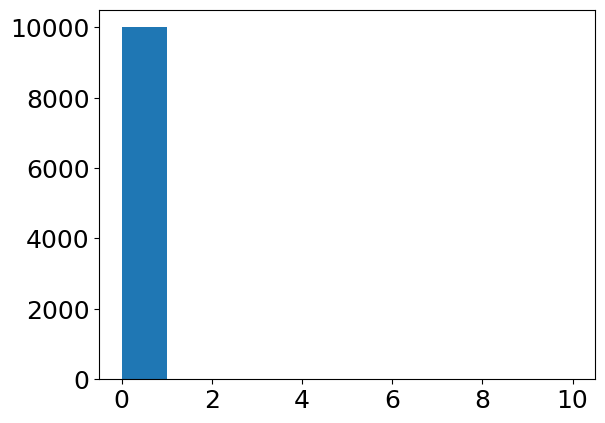

In [94]:
plt.hist(weights_fit, range = [0,10]), weights_fit

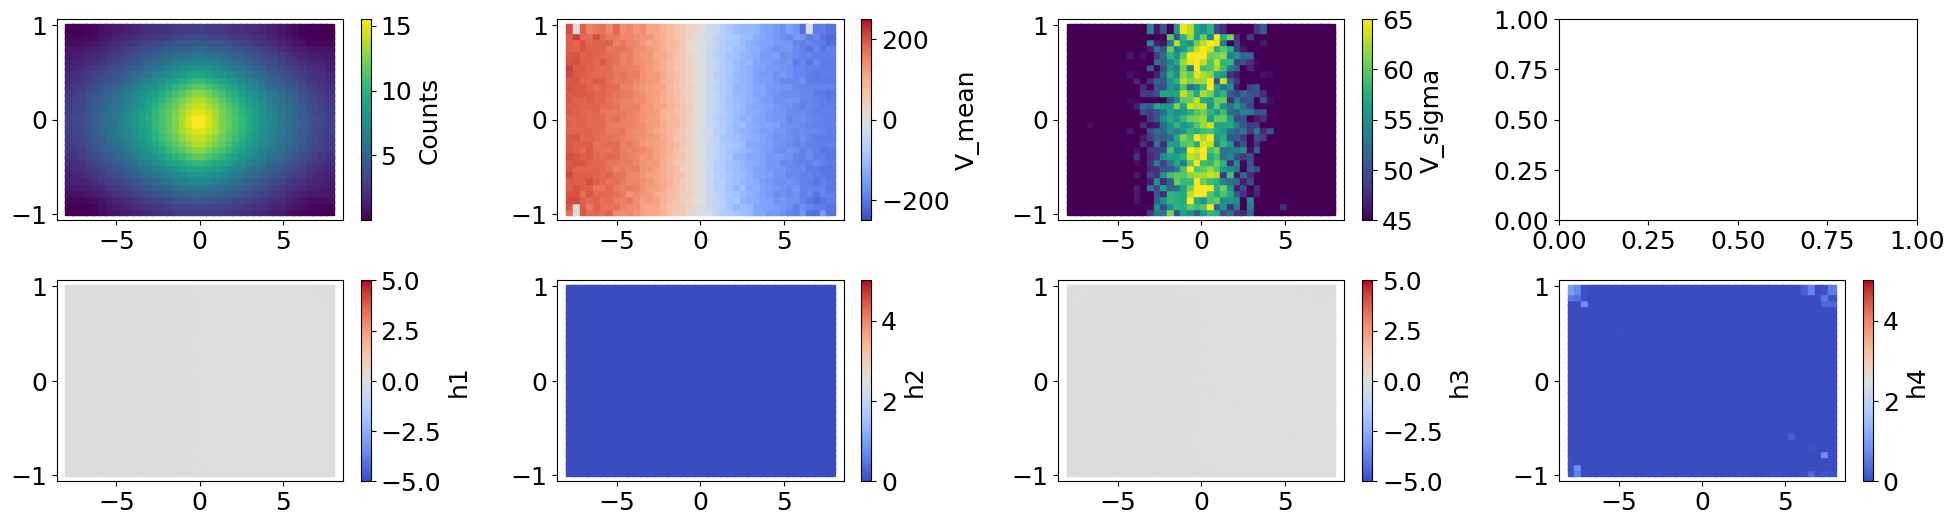

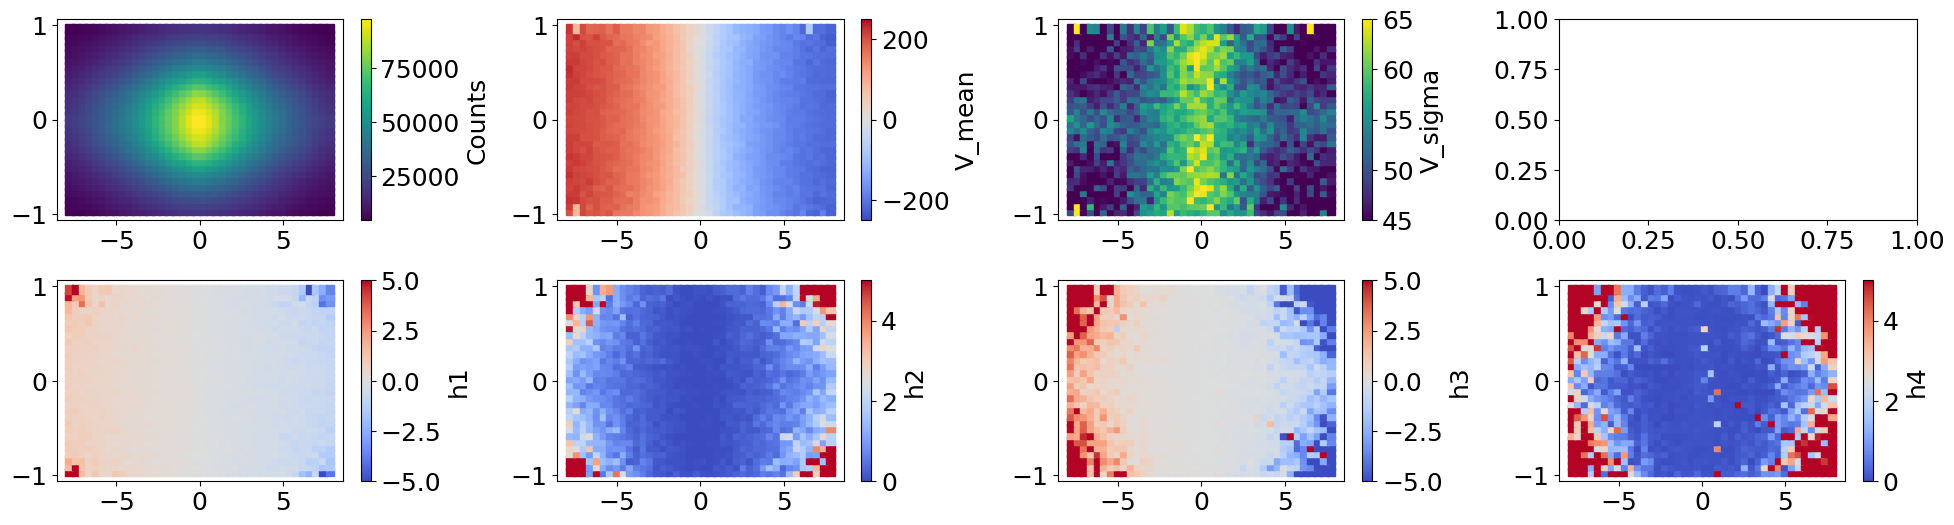

In [91]:
fig2, ax2 = plt.subplots(2,4, figsize=(24,6), gridspec_kw={'wspace':0.4, 'hspace':0.3})
cb = ax2[0,0].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=density_2DXY, 
                 marker = 's', cmap='viridis', rasterized = True)
fig2.colorbar(cb, ax=ax2[0,0], label='Counts')
cb = ax2[0,1].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=V_model, 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin=-250, vmax=250)
fig2.colorbar(cb, ax=ax2[0,1], label='V_mean')
cb = ax2[0,2].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=sigma_model, 
                 marker = 's', cmap='viridis', rasterized = True, vmin = 45, vmax = 65)
fig2.colorbar(cb, ax=ax2[0,2], label='V_sigma')
cb = ax2[1,0].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=h1_model, 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin = -5, vmax = 5)
fig2.colorbar(cb, ax=ax2[1,0], label='h1')
cb = ax2[1,1].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=h2_model, 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin = 0, vmax = 5)
fig2.colorbar(cb, ax=ax2[1,1], label='h2')
cb = ax2[1,2].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=h3_model, 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin = -5, vmax = 5)
fig2.colorbar(cb, ax=ax2[1,2], label='h3')
cb = ax2[1,3].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=h4_model, 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin = 0, vmax = 5)
fig2.colorbar(cb, ax=ax2[1,3], label='h4')

fig2, ax2 = plt.subplots(2,4, figsize=(24,6), gridspec_kw={'wspace':0.4, 'hspace':0.3})
cb = ax2[0,0].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=density_2DXY_unity, 
                 marker = 's', cmap='viridis', rasterized = True)
fig2.colorbar(cb, ax=ax2[0,0], label='Counts')
cb = ax2[0,1].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=V_model_unity, 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin=-250, vmax=250)
fig2.colorbar(cb, ax=ax2[0,1], label='V_mean')
cb = ax2[0,2].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=sigma_model_unity, 
                 marker = 's', cmap='viridis', rasterized = True, vmin = 45, vmax = 65)
fig2.colorbar(cb, ax=ax2[0,2], label='V_sigma')
cb = ax2[1,0].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=h1_model_unity, 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin = -5, vmax = 5)
fig2.colorbar(cb, ax=ax2[1,0], label='h1')
cb = ax2[1,1].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=h2_model_unity, 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin = 0, vmax = 5)
fig2.colorbar(cb, ax=ax2[1,1], label='h2')
cb = ax2[1,2].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=h3_model_unity, 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin = -5, vmax = 5)
fig2.colorbar(cb, ax=ax2[1,2], label='h3')
cb = ax2[1,3].scatter(df_XY['X_grid'], df_XY['Y_grid'], c=h4_model_unity, 
                 marker = 's', cmap='coolwarm', rasterized = True, vmin = 0, vmax = 5)
fig2.colorbar(cb, ax=ax2[1,3], label='h4')

In [ ]:

# @jax.jit
def model(params_halo_pot, params_disk_rho, dict_data):

    A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4, v0, s = integrate(
        params_halo_pot,
        params_disk_rho,
        dict_data
    )

    A_h1 = jnp.where(jnp.fabs(A_h1)>2, 0.0, A_h1)
    A_h2 = jnp.where(jnp.fabs(A_h2)>2, -1/np.sqrt(2), A_h2)
    A_h3 = jnp.where(jnp.fabs(A_h3)>2, 0.0, A_h3)
    A_h4 = jnp.where(jnp.fabs(A_h4)>2, 3/np.sqrt(24), A_h4)

    y_Rzphi = dict_data['Rzphi_density_data'].astype(jnp.float32)
    y_xy = dict_data['XY_density_data'].astype(jnp.float32)
    y_h1 = dict_data['h1_data'].astype(jnp.float32)
    y_h2 = dict_data['h2_data'].astype(jnp.float32)
    y_h3 = dict_data['h3_data'].astype(jnp.float32)
    y_h4 = dict_data['h4_data'].astype(jnp.float32)

    sig_Rzphi = 0.02 * y_Rzphi + 1.0
    sig_xy = 0.01 * y_xy + 1.0
    frac_err_min = 0.1
    sig_A1 = jnp.where(frac_err_min * y_h1 > dict_data['h1_data_err'], frac_err_min * y_h1, dict_data['h1_data_err']) + EPSILON
    sig_A2 = jnp.where(frac_err_min * y_h2 > dict_data['h2_data_err'], frac_err_min * y_h2, dict_data['h2_data_err']) + EPSILON
    sig_A3 = jnp.where(frac_err_min * y_h3 > dict_data['h3_data_err'], frac_err_min * y_h3, dict_data['h3_data_err']) + EPSILON
    sig_A4 = jnp.where(frac_err_min * y_h4 > dict_data['h4_data_err'], frac_err_min * y_h4, dict_data['h4_data_err']) + EPSILON

    renormalise_Rzphi = jnp.amax(y_Rzphi)
    renormalise_xy = jnp.amax(y_xy)
    renormalise_h1 = jnp.amax(jnp.fabs(y_h1))
    renormalise_h2 = jnp.amax(jnp.fabs(y_h2))
    renormalise_h3 = jnp.amax(jnp.fabs(y_h3))
    renormalise_h4 = jnp.amax(jnp.fabs(y_h4))

    y_xy = y_xy / renormalise_xy
    A_xy = A_xy / renormalise_xy
    sig_xy = sig_xy / renormalise_xy
    y_Rzphi = y_Rzphi / renormalise_Rzphi
    A_Rzphi = A_Rzphi / renormalise_Rzphi
    sig_Rzphi = sig_Rzphi / renormalise_Rzphi
    # y_h1 = y_h1 / renormalise_h1
    # A_h1 = A_h1 / renormalise_h1
    # sig_A1 = sig_A1 / renormalise_h1
    # y_h2 = y_h2 / renormalise_h2
    # A_h2 = A_h2 / renormalise_h2
    # sig_A2 = sig_A2 / renormalise_h2
    # y_h3 = y_h3 / renormalise_h3
    # A_h3 = A_h3 / renormalise_h3
    # sig_A3 = sig_A3 / renormalise_h3
    # y_h4 = y_h4 / renormalise_h4
    # A_h4 = A_h4 / renormalise_h4
    # sig_A4 = sig_A4 / renormalise_h4

    non_empty_index = dict_data['non_empty_index']
    y_xy = y_xy[non_empty_index]
    A_xy = A_xy[non_empty_index,:]
    sig_xy = sig_xy[non_empty_index]
    y_h1 = y_h1[non_empty_index]
    A_h1 = A_h1[non_empty_index,:]
    sig_A1 = sig_A1[non_empty_index]
    y_h2 = y_h2[non_empty_index]
    A_h2 = A_h2[non_empty_index,:]
    sig_A2 = sig_A2[non_empty_index]
    y_h3 = y_h3[non_empty_index]
    A_h3 = A_h3[non_empty_index,:]
    sig_A3 = sig_A3[non_empty_index]
    y_h4 = y_h4[non_empty_index]
    A_h4 = A_h4[non_empty_index,:]
    sig_A4 = sig_A4[non_empty_index]

    v0 = v0[non_empty_index]
    s = s[non_empty_index]

    print("N_xy data nan:",jnp.isnan(y_xy).sum())
    print("N_xy data non zero:",(y_xy!=0).sum())
    print('sigma_xy nan:',jnp.isnan(sig_xy).sum())
    print('sigma_xy non zero:',(sig_xy!=0).sum())
    print("h1 data nan:",jnp.isnan(y_h1).sum())
    print("h1 data non zero:",(y_h1!=0).sum())
    print("sigma_h1 nan:",jnp.isnan(sig_A1).sum())
    print("sigma_h1 non zero:",(sig_A1!=0).sum())
    print("h2 data nan:",jnp.isnan(y_h2).sum())
    print("h2 data non zero:",(y_h2!=0).sum())
    print("sigma_h2 nan:",jnp.isnan(sig_A2).sum())
    print("sigma_h2 non zero:",(sig_A2!=0).sum())
    print("h3 data nan:",jnp.isnan(y_h3).sum())
    print("h3 data non zero:",(y_h3!=0).sum())
    print("sigma_h3 nan:",jnp.isnan(sig_A3).sum())
    print("sigma_h3 non zero:",(sig_A3!=0).sum())
    print("h4 data nan:",jnp.isnan(y_h4).sum())
    print("h4 data non zero:",(y_h4!=0).sum())
    print("sigma_h4 nan:",jnp.isnan(sig_A4).sum())
    print("sigma_h4 non zero:",(sig_A4!=0).sum())
    
    weights = solve_lbfgs_softplus(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                                    y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                                    sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, 
                                    l2=1e-3, maxiter=500)

    weights = jnn.softplus(weights)

    #===================================== Calculate the net kinematics of the model =========================================


    A_h1, A_h2, A_h3, A_h4 = (A_h1 * A_xy), (A_h2 * A_xy), (A_h3 * A_xy), (A_h4 * A_xy)
    density_2DXY = A_xy @ weights
    h1_model = (A_h1 @ weights) / density_2DXY
    h2_model = (A_h2 @ weights) / density_2DXY
    h3_model = (A_h3 @ weights) / density_2DXY
    h4_model = (A_h4 @ weights) / density_2DXY

    V_model, sigma_model = h_to_V_sigma(h1_model, h2_model, v0, s)
    

    return V_model, sigma_model, h3_model, h4_model, weights


# @jax.jit
def logl(params, dict_data):


    params_halo_pot = {
        'logM': params['logM_halo'],
        'Rs':10 ** params['logRs_halo'],
        'a':1.0,
        'b':1.0,
        'c':1.0,
        'x_origin':0.0,
        'y_origin':0.0,
        'z_origin':0.0,
        'dirx':0.0,
        'diry':0.0,
        'dirz':1.0
    }

    params_disk_rho = {
        'logM': params['logM_disk'],
        'Rs': 10 ** params['logRs_disk'],
        'Hs': 10 ** params['logHs_disk'],
        'x_origin': 0.0,
        'y_origin': 0.0,
        'z_origin': 0.0,
        'dirx': 0.0,
        'diry': 0.0,
        'dirz': 1.0
    }

    V_model, sigma_model, h3_model, h4_model, weights = model(params_halo_pot, params_disk_rho, dict_data)

    jax.debug.print("`V_model` shape: {x_norm}", x_norm=V_model.shape)
    jax.debug.print("V_model with nan: {x_norm}", x_norm=jnp.isnan(V_model).sum())
    jax.debug.print("`V_model`: {x_norm}", x_norm=V_model)
    jax.debug.print("`sigma_model`: {x_norm}", x_norm=sigma_model)
    jax.debug.print("`weights`: {x_norm}", x_norm=weights)
    jax.debug.print("`weights 16th`: {x_norm}", x_norm=jnp.percentile(weights, 16))
    jax.debug.print("`weights 84th`: {x_norm}", x_norm=jnp.percentile(weights, 84))
    jax.debug.print("weights with nan: {x_norm}", x_norm=jnp.isnan(weights).sum())

    V_model = jnp.where(jnp.isnan(V_model), 0.0, V_model)
    sigma_model = jnp.where(jnp.isnan(sigma_model), 0.0, sigma_model)
    h3_model = jnp.where(jnp.isnan(h3_model), 0.0, h3_model)
    h4_model = jnp.where(jnp.isnan(h4_model), 0.0, h4_model)

    V_data, V_data_err = dict_data['V_data'], dict_data['V_data_err']
    sigma_data, sigma_data_err = dict_data['sigma_data'], dict_data['sigma_data_err']
    h3_data, h3_data_err = dict_data['h3_data'], dict_data['h3_data_err']
    h4_data, h4_data_err = dict_data['h4_data'], dict_data['h4_data_err']

    non_empty_index = dict_data['non_empty_index']
    V_data = V_data[non_empty_index]
    V_data_err = V_data_err[non_empty_index]
    sigma_data = sigma_data[non_empty_index]
    sigma_data_err = sigma_data_err[non_empty_index]
    h3_data = h3_data[non_empty_index]
    h3_data_err = h3_data_err[non_empty_index]
    h4_data = h4_data[non_empty_index]
    h4_data_err = h4_data_err[non_empty_index]

    jax.debug.print("V diff mean sigma_model: {x_norm}, {sigma}", 
                    x_norm=jnp.nanmean(jnp.fabs(V_model - V_data)), sigma=jnp.nanstd(jnp.fabs(V_model - V_data)))
    
    jax.debug.print("sigma diff mean sigma_model: {x_norm}, {sigma}", 
                    x_norm=jnp.nanmean(jnp.fabs(sigma_model - sigma_data)), sigma=jnp.nanstd(jnp.fabs(sigma_model - sigma_data)))
    
    jax.debug.print("h3 diff mean sigma_model: {x_norm}, {sigma}", 
                    x_norm=jnp.nanmean(jnp.fabs(h3_model - h3_data)), sigma=jnp.nanstd(jnp.fabs(h3_model - h3_data)))
    
    jax.debug.print("h4 diff mean sigma_model: {x_norm}, {sigma}", 
                    x_norm=jnp.nanmean(jnp.fabs(h4_model - h4_data)), sigma=jnp.nanstd(jnp.fabs(h4_model - h4_data)))


    frac_err_min = 0.1
    V_data_err = jnp.where(frac_err_min * V_data > V_data_err, frac_err_min * V_data, V_data)
    sigma_data_err = jnp.where(frac_err_min * sigma_data > sigma_data_err, frac_err_min * sigma_data, sigma_data)
    h3_data_err = jnp.where(frac_err_min * h3_data > h3_data_err, frac_err_min * h3_data, h3_data)
    h4_data_err = jnp.where(frac_err_min * h4_data > h4_data_err, frac_err_min * h4_data, h4_data)

    log_likelihood = 0
    log_likelihood += jnp.nansum( -0.5 * ((V_model - V_data)**2) / (V_data_err + 1e-3)**2 )
    log_likelihood += jnp.nansum( -0.5 * ((sigma_model - sigma_data)**2) / (sigma_data_err + 1e-3)**2 )
    log_likelihood += jnp.nansum( -0.5 * ((h3_model - h3_data)**2) / (h3_data_err + 1e-3)**2 )
    log_likelihood += jnp.nansum( -0.5 * ((h4_model - h4_data)**2) / (h4_data_err + 1e-3)**2 )

    return log_likelihood, V_model, sigma_model, h3_model, h4_model

In [129]:
%load_ext autoreload
%autoreload 2

import pickle

import jax
import jaxopt
import jax.nn as jnn
import jax.numpy as jnp
import jax.scipy as jsp
from functools import partial

import time as tt
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 18

import os
import corner
import numpy as np
import multiprocessing as mp

from potentials import *
from integrants_with_binning import *
from ghMoments import *
from utils import *
from constants import EPSILON

from potentials import NFW_acceleration
from densities import MiyamotoNagai_density

from CylindricalSpline import get_phi_m, get_acc, evaluate_phi_axisymmetric

path = '/home/hz420/python_script/SchwarMAX/'
# @jax.jit
def potential_func(x, y, z, dict_phi, params_halo):
    """ Returns Phi(R, z) """
    phi_halo = NFW_potential(x, y, z, params_halo)
    phi_disk = evaluate_phi_axisymmetric(x, y, z, dict_phi)
    return phi_halo + phi_disk

# @jax.jit
def density_func(x, y, z, params):
    """ Returns Stellar Density nu(R, z) """
    # Double Exponential Disk
    val = MiyamotoNagai_density(x, y, z, params)
    return val

# @jax.jit
def dPhi_dz(x, y, z, dict_phi, params_halo):
    # Numerical derivative of Potential w.r.t z
    d = 5e-3
    return (potential_func(x, y, z+d, dict_phi, params_halo) - potential_func(x, y, z-d, dict_phi, params_halo)) / (2*d)

# @jax.jit
def dPhi_dR(x, y, z, dict_phi, params_halo):
    # Numerical derivative of Potential w.r.t R
    d = 5e-3
    R = jnp.sqrt(x**2 + y**2)
    return (potential_func(R+d, 0, z, dict_phi, params_halo) - potential_func(R-d, 0, z, dict_phi, params_halo)) / (2*d)

# @jax.jit
def get_jeans_moments(x_star, y_star, z_star, dict_phi, params_disc, params_halo, anisotropy_b=1.0):
    """
    Computes (v_mean, sigma_R, sigma_z, sigma_phi) for a star at (R, z).
    
    Parameters:
    -----------
    x_star, y_star, z_star : float
        Coordinates of the particle.
    density_fn : function
        Function returning stellar density nu(R, z).
    anisotropy_b : float
        sigma_R^2 / sigma_z^2. Default 1.0 (isotropic).
    """
    R_star = jnp.sqrt(x_star**2 + y_star**2)
    
    # --- Step 1: Compute Sigma_z (Vertical Integration) ---
    
    # Integrand: nu(R, z) * dPhi/dz
    def integrand(z_prime):
        return density_func(x_star, y_star, z_prime, params_disc) * dPhi_dz(x_star, y_star, z_prime, dict_phi, params_halo)
    
    # Integrate from z_star to infinity (e.g., 20 kpc)
    # Note: We assume symmetry, so we integrate |z| to infinity
    pts = jnp.linspace(jnp.abs(z_star), 10.0, 1000)
    dx = pts[1] - pts[0]
    # integrand_val = integrand(pts)
    integrand_val = jax.vmap(integrand, in_axes = (0))(pts)
    integral_val = jsp.integrate.trapezoid(integrand_val, pts, dx)
    
    nu_val = density_func(x_star, y_star, z_star, params_disc)
    # if nu_val <= 0: return 0, 0, 0, 0
    
    sigma_z2 = (1.0 / nu_val) * integral_val
    
    sigma_z2 = jnp.maximum(sigma_z2, 0.0)

    sigma_z = jnp.sqrt(sigma_z2)
    
    # --- Step 2: Compute Sigma_R (Anisotropy assumption) ---
    sigma_R2 = anisotropy_b * sigma_z2
    sigma_R = jnp.sqrt(sigma_R2)
    
    # --- Step 3: Compute v_phi_total^2 (Radial Equation) ---
    # We need d(nu * sigma_R^2) / dR
    # Since sigma_R^2 = b * sigma_z^2, we need d(b * Integral) / dR
    
    # Define a helper to calculate the "Vertical Pressure" P_zz = nu * sigma_z^2 at any R
    def vertical_pressure(r_in):
        # We need to re-integrate at radius r_in to get the pressure there
        def integrand_r(z_prime):
            return density_func(r_in, 0, z_prime, params_disc) * dPhi_dz(r_in, 0, z_prime, dict_phi, params_halo)
        
        pts = jnp.linspace(jnp.abs(z_star), 10.0, 1000)
        dx = pts[1] - pts[0]
        # integrand_val = integrand(pts)
        integrand_val = jax.vmap(integrand_r, in_axes = (0))(pts)
        integral_val = jsp.integrate.trapezoid(integrand_val, pts, dx)
        return integral_val # This is (nu * sigma_z^2)

    # Calculate derivative w.r.t R using central difference
    dR = 5e-3
    Pzz_plus = vertical_pressure(R_star + dR)
    Pzz_minus = vertical_pressure(R_star - dR)
    d_nu_sigR2_dR = anisotropy_b * (Pzz_plus - Pzz_minus) / (2*dR)
    
    # Radial Jeans Equation:
    # v_phi_sq = sigma_R^2 + (R/nu) * d(nu*sigR^2)/dR + R * dPhi/dR
    term1 = sigma_R2
    term2 = (R_star / nu_val) * d_nu_sigR2_dR
    term3 = R_star * dPhi_dR(x_star, y_star, z_star, dict_phi, params_halo)
    
    v_phi_total_sq = term1 + term2 + term3
    
    # --- Step 4: Separate Rotation vs Dispersion ---
    # Assumption: sigma_phi approx sigma_R (Round velocity ellipsoid in plane)
    sigma_phi = sigma_R
    
    v_streaming_sq = v_phi_total_sq - sigma_phi**2

    v_streaming_sq = jnp.maximum(v_streaming_sq, 0.0)
    v_mean_phi = jnp.sqrt(v_streaming_sq)

    output = jax.lax.cond(nu_val<=0, lambda: (0.0, 0.0, 0.0, 0.0), lambda: (v_mean_phi, sigma_R, sigma_z, sigma_phi))
    
    return output


# @jax.jit
def _nll_z(z, 
            A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4, 
            y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
            sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, l2):

    x = jnn.softplus(z)  # strictly positive
    # x = jnp.exp(z)  # strictly positive
    # jax.debug.print("A_Rzphi's shape: {x_norm}", x_norm=A_Rzphi.shape)
    # jax.debug.print("x's shape: {x_norm}", x_norm=x.shape)
    r_3dRzphi = (A_Rzphi @ x - y_Rzphi) / sig_Rzphi

    mass_tot = jnp.sum(y_Rzphi)
    N_orb = len(x)
    wi = ( mass_tot / N_orb ) * jnp.ones_like(x)

    density_2DXY = A_xy @ x
    r_2dXY = (density_2DXY - y_xy) / sig_xy

    A_h1, A_h2, A_h3, A_h4 = (A_h1 * A_xy), (A_h2 * A_xy), (A_h3 * A_xy), (A_h4 * A_xy)

    y_h1_model = (A_h1 @ x) / y_xy
    y_h2_model = (A_h2 @ x) / y_xy
    y_h3_model = (A_h3 @ x) / y_xy
    y_h4_model = (A_h4 @ x) / y_xy

    clip_val = 10.0
    y_h1_model = jnp.where(y_h1_model > clip_val, clip_val, y_h1_model)
    y_h2_model = jnp.where(y_h2_model > clip_val, clip_val, y_h2_model)
    y_h3_model = jnp.where(y_h3_model > clip_val, clip_val, y_h3_model)
    y_h4_model = jnp.where(y_h4_model > clip_val, clip_val, y_h4_model)
    y_h1_model = jnp.where(y_h1_model < -clip_val, -clip_val, y_h1_model)
    y_h2_model = jnp.where(y_h2_model < -clip_val, -clip_val, y_h2_model)
    y_h3_model = jnp.where(y_h3_model < -clip_val, -clip_val, y_h3_model)
    y_h4_model = jnp.where(y_h4_model < -clip_val, -clip_val, y_h4_model)

    r_h1 = ( y_h1_model - y_h1 ) / sig_A1
    r_h2 = ( y_h2_model - y_h2 ) / sig_A2
    r_h3 = ( y_h3_model - y_h3 ) / sig_A3
    r_h4 = ( y_h4_model - y_h4 ) / sig_A4

    val1 = 0.5 * jnp.dot(r_3dRzphi, r_3dRzphi) / len(r_3dRzphi) * 5
    val2 = 0.5 * jnp.dot(r_2dXY, r_2dXY) / len(r_2dXY) * 5
    val4 = 0.5 * jnp.dot(r_h1, r_h1) / len(r_h1)# * 5
    val5 = 0.5 * jnp.dot(r_h2, r_h2) / len(r_h2)# * 5
    val3 = 0.5 * jnp.dot(r_h3, r_h3) / len(r_h3)# * 5
    val6 = 0.5 * jnp.dot(r_h4, r_h4) / len(r_h4)# * 5

    x_renormalised = x / wi
    # regularisation_factor = (l2 / N_orb) * jnp.dot(x_renormalised, x_renormalised)
    regularisation_factor = (l2 / N_orb) * jnp.sum(x_renormalised * jnp.log(x_renormalised + EPSILON))

    jax.debug.print("z={val1}", 
                    val1=z,)
    jax.debug.print("NLL components: Rzphi={val1}, XY={val2}, h1={val3}, h2={val4}, h3={val5}, h4={val6}, reg={reg}, tot={tot}", 
                    val1=val1, val2=val2, val3=val3, val4=val4, val5=val5, val6=val6, reg=regularisation_factor, 
                    tot=val1 + val2 + val3 + val4 + val5 + val6 + regularisation_factor)


    return val1 + val2 + val3 + val4 + val5 + val6 + regularisation_factor
_nll_z = jax.value_and_grad(_nll_z)

# @jax.jit
def solve_lbfgs_softplus(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                        y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                        sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4,
                        l2=1, maxiter=500, tol=1e-6):
    
    jax.debug.print("A_Rzphi shape: {x_norm}", x_norm=A_Rzphi.shape)
    jax.debug.print("total mass in Rzphi data: {x_norm}", x_norm=jnp.sum(y_Rzphi))
    jax.debug.print("initial guess: {x_norm}", x_norm=(jnp.sum(y_Rzphi) / A_Rzphi.shape[1]))
    z0 = jnp.ones(A_Rzphi.shape[1], A_Rzphi.dtype) * (jnp.sum(y_Rzphi) / A_Rzphi.shape[1])  # initial guess
    # z0 = jnp.zeros(A_Rzphi.shape[1], A_Rzphi.dtype)
    solver = jaxopt.LBFGS(fun=_nll_z, value_and_grad=True, maxiter=maxiter, tol=tol, implicit_diff=True)
    res = solver.run(z0, 
                    A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                    y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                    sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, l2)
    x_hat = jnn.softplus(res.params)
    # x_hat = jnp.exp(res.params)
    return x_hat

def solve_two_stage(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                    y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                    sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4,
                    l2=1, maxiter=300):
    
    # Stage 1: Fit density only
    def density_only_loss(z):
        x = jnn.softplus(z)
        r_3dRzphi = (A_Rzphi @ x - y_Rzphi) / sig_Rzphi
        r_2dXY = (A_xy @ x - y_xy) / sig_xy
        return 0.5 * jnp.dot(r_3dRzphi, r_3dRzphi) + 0.5 * jnp.dot(r_2dXY, r_2dXY)


    
    z0 = jnp.ones(A_Rzphi.shape[1]) * (jnp.sum(y_Rzphi) / A_Rzphi.shape[1])  # initial guess    
    # z0 = jnp.ones(A_Rzphi.shape[1], A_Rzphi.dtype) * (jnp.sum(y_Rzphi) / A_Rzphi.shape[1]) + (jax.random.normal(jax.random.PRNGKey(45678), (A_Rzphi.shape[1],)) * 0.5)
    solver1 = jaxopt.LBFGS(fun=density_only_loss, maxiter=maxiter//2, tol = 1e-3)
    res1 = solver1.run(z0)
    # x_hat = jnn.softplus(res1.params)

    # Stage 2: Refine with all constraints, starting from Stage 1 solution
    solver2 = jaxopt.LBFGS(fun=_nll_z, value_and_grad=True, maxiter=maxiter//2, tol = 1e-3)
    res2 = solver2.run(res1.params, A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                    y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                    sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, l2)

    x_hat = jnn.softplus(res2.params)
    return x_hat

from jaxopt import BoxOSQP
from functools import partial

# @partial(jax.jit, static_argnames=('maxiter',))
def solve_qp(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
             y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
             sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4,
             l2=1e-5, maxiter=500):
    """
    Quadratic programming for Schwarzschild modeling using BoxOSQP.
    """
    n_orbits = A_Rzphi.shape[1]
    
    # Linearized kinematic matrices
    A_h1_lin = (A_h1 * A_xy) / y_xy[:, None]
    A_h2_lin = (A_h2 * A_xy) / y_xy[:, None]
    A_h3_lin = (A_h3 * A_xy) / y_xy[:, None]
    A_h4_lin = (A_h4 * A_xy) / y_xy[:, None]
    
    # Stack all constraints
    A = jnp.vstack([
        A_Rzphi / sig_Rzphi[:, None],
        A_xy / sig_xy[:, None],
        A_h1_lin / sig_A1[:, None],
        A_h2_lin / sig_A2[:, None],
        A_h3_lin / sig_A3[:, None],
        A_h4_lin / sig_A4[:, None],
    ])
    
    y = jnp.concatenate([
        y_Rzphi / sig_Rzphi,
        y_xy / sig_xy,
        y_h1 / sig_A1,
        y_h2 / sig_A2,
        y_h3 / sig_A3,
        y_h4 / sig_A4,
    ])
    
    # QP matrices: min 0.5 * x^T Q x + c^T x
    Q = A.T @ A + l2 * jnp.eye(n_orbits)
    c = -A.T @ y
    
    # Constraint: l <= A_constraint @ x <= u
    # For x >= 0, use A_constraint = I, l = 0, u = inf
    A_constraint = jnp.eye(n_orbits)
    l = jnp.zeros(n_orbits)
    u = jnp.full(n_orbits, jnp.inf)
    
    qp = BoxOSQP(maxiter=maxiter, tol=1e-3)
    sol = qp.run(params_obj=(Q, c), params_eq=A_constraint, params_ineq=(l, u)).params
    
    return sol.primal[0]

from functools import partial

# @partial(jax.jit, static_argnames=('maxiter',))
def solve_fista(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4,
                l2=1e-5, maxiter=2000):
    """
    FISTA for non-negative least squares.
    
    Solves: min 0.5 * ||A @ x - y||^2 + 0.5 * l2 * ||x||^2
            s.t. x >= 0
    """
    n_orbits = A_Rzphi.shape[1]
    
    # Linearized kinematic matrices
    A_h1_lin = (A_h1 * A_xy) / y_xy[:, None]
    A_h2_lin = (A_h2 * A_xy) / y_xy[:, None]
    A_h3_lin = (A_h3 * A_xy) / y_xy[:, None]
    A_h4_lin = (A_h4 * A_xy) / y_xy[:, None]
    
    # Stack all constraints
    A = jnp.vstack([
        A_Rzphi / sig_Rzphi[:, None],
        A_xy / sig_xy[:, None],
        A_h1_lin / sig_A1[:, None],
        A_h2_lin / sig_A2[:, None],
        A_h3_lin / sig_A3[:, None],
        A_h4_lin / sig_A4[:, None],
    ])
    
    y = jnp.concatenate([
        y_Rzphi / sig_Rzphi,
        y_xy / sig_xy,
        y_h1 / sig_A1,
        y_h2 / sig_A2,
        y_h3 / sig_A3,
        y_h4 / sig_A4,
    ])
    
    # Precompute normal equations
    AtA = A.T @ A + l2 * jnp.eye(n_orbits)
    Aty = A.T @ y
    
    # Lipschitz constant
    L = jnp.linalg.norm(AtA, ord=2)
    step_size = 1.0 / L
    
    def fista_step(carry, _):
        x, x_old, t = carry
        
        # Gradient step
        grad = AtA @ x - Aty
        x_new = jnp.clip(x - step_size * grad, 0, None)
        
        # FISTA momentum
        t_new = (1 + jnp.sqrt(1 + 4 * t**2)) / 2
        x_accel = jnp.clip(x_new + ((t - 1) / t_new) * (x_new - x_old), 0, None)
        
        return (x_accel, x_new, t_new), None
    
    x0 = jnp.ones(n_orbits) / n_orbits
    (x_final, _, _), _ = jax.lax.scan(fista_step, (x0, x0, 1.0), None, length=maxiter)
    
    return x_final

# @jax.jit
def integrate(params_halo_pot, params_disk_rho, dict_data):

    w0 = dict_data['w0']
    n_particles = w0.shape[0]
    v0 = dict_data['v0']
    s = dict_data['s']

    #=========================================== GET DISC POTENTIAL =====================================================

    NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax = 50, 30, 1e-2, 30.0, 1e-3, 15.0, 8.
    Nphi = 200
    N_int = 10_000
    dict_phi = get_phi_m(MiyamotoNagai_density, params_disk_rho, NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax, Nphi, N_int)

    #=========================================== GET INITIAL VELOCITY ===================================================

    get_jeans_moments_vmap = jax.vmap(get_jeans_moments, in_axes=(0,0,0,None,None,None,None))
    # jeans_moments = get_jeans_moments(x_p, y_p, z_p, dict_phi, params_disk_rho,params_halo_pot, anisotropy_b=1.0)
    jeans_moments = get_jeans_moments_vmap(w0[:,0], w0[:,1], w0[:,2], dict_phi, params_disk_rho, params_halo_pot, 1.)

    v_rot, sig_R, sig_z, sig_phi = jeans_moments
    key1, key2, key3 = jax.random.PRNGKey(42), jax.random.PRNGKey(109), jax.random.PRNGKey(2026)
    g1, g2, g3 = jax.random.normal(key1, (n_particles,)), jax.random.normal(key2, (n_particles,)), jax.random.normal(key3, (n_particles,))
    vR = g1 * sig_R
    vz = g2 * sig_z
    vphi = v_rot + g3 * sig_phi

    x, y, vx, vy = getCartesianFromCylindrical_clockwise(jnp.sqrt(w0[:,0]**2 + w0[:,1]**2), jnp.arctan2(w0[:,1], w0[:,0]), vR, vphi)

    w0_new = jnp.array([x, y, w0[:,2], vx, vy, vz]).T

    #=========================================== Integrate orbits =======================================================
    # @jax.jit
    def acc_fn(x, y, z):
        a_halo = NFW_acceleration(x, y, z,  params_halo_pot)
        a_disk = get_acc(x, y, z, dict_phi)
        return a_halo + a_disk

    time = 10. #Gyr
    n_steps = 5000
    dt = time / n_steps
    unroll = False
    initial_time = 0.0

    Rzphi_bin_counts, Nxy, h1, h2, h3, h4 = jax.vmap(integrate_leapfrog_grid, in_axes=(0, None, None, None, None, None, None, None, None, None, None, None, None, None))\
                        (w0_new, acc_fn, n_steps, dt, initial_time, unroll,
                        jnp.array([[0,10.],[-1.5,1.5],[-jnp.pi, jnp.pi]]), jnp.array([[-8.,8.],[-1.,1.]]),
                        jnp.array([10,6,6]), jnp.array([40,30]), 360, 1200,
                        v0, s)

    # jax.debug.print("h1 shape: {x_norm}", x_norm=h1.shape)
    # jax.debug.print("h1 nan: {x_norm}", x_norm=jnp.isnan(h1).sum())
    # print("h1 shape: {x_norm}",h1.shape)
    # print("h1 nan: {x_norm}",jnp.isnan(h1).sum())
    # print("h1 non zero: {x_norm}",(h1!=0).sum())
    # print("h2 shape: {x_norm}",h2.shape)
    # print("h2 nan: {x_norm}",jnp.isnan(h2).sum())
    # print("h2 non zero: {x_norm}",(h2!=0).sum())
    # print("h3 shape: {x_norm}",h3.shape)
    # print("h3 nan: {x_norm}",jnp.isnan(h3).sum())
    # print("h3 non zero: {x_norm}",(h3!=0).sum())
    # print("h4 shape: {x_norm}",h4.shape)
    # print("h4 nan: {x_norm}",jnp.isnan(h4).sum())
    # print("h4 non zero: {x_norm}",(h4!=0).sum())
    # print("Nxy nan: {x_norm}",jnp.isnan(Nxy).sum())
    # print("Nxy non zero: {x_norm}",(Nxy!=0).sum())
    #=========================================== Orbital weights optimisation ============================================
    A_Rzphi = Rzphi_bin_counts.T / n_steps
    A_xy = Nxy.T / n_steps
    A_h1 = h1.T
    A_h2 = h2.T
    A_h3 = h3.T
    A_h4 = h4.T

    return A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4, v0, s

# @jax.jit
def integrate_voronoi(params_halo_pot, params_disk_rho, dict_data):

    w0 = dict_data['w0']
    n_particles = w0.shape[0]
    v0 = dict_data['v0']
    s = dict_data['s']
    num_per_bin = dict_data['num_per_bin']
    bin_mapping = dict_data['bin_mapping']
    num_Vbin = dict_data['total_bins']
    #=========================================== GET DISC POTENTIAL =====================================================

    NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax = 50, 30, 1e-2, 30.0, 1e-3, 15.0, 8.
    Nphi = 200
    N_int = 10_000
    dict_phi = get_phi_m(MiyamotoNagai_density, params_disk_rho, NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax, Nphi, N_int)

    #=========================================== GET INITIAL VELOCITY ===================================================

    get_jeans_moments_vmap = jax.vmap(get_jeans_moments, in_axes=(0,0,0,None,None,None,None))
    # jeans_moments = get_jeans_moments(x_p, y_p, z_p, dict_phi, params_disk_rho,params_halo_pot, anisotropy_b=1.0)
    jeans_moments = get_jeans_moments_vmap(w0[:,0], w0[:,1], w0[:,2], dict_phi, params_disk_rho, params_halo_pot, 1.)

    v_rot, sig_R, sig_z, sig_phi = jeans_moments
    key1, key2, key3 = jax.random.PRNGKey(42), jax.random.PRNGKey(109), jax.random.PRNGKey(2026)
    # g1, g2, g3 = jax.random.normal(key1, (n_particles,)), jax.random.normal(key2, (n_particles,)), jax.random.normal(key3, (n_particles,))
    g1, g2, g3 = (jax.random.uniform(key1, (n_particles,))-0.5)*2, (jax.random.uniform(key2, (n_particles,))-0.5)*2, (jax.random.uniform(key3, (n_particles,))-0.5)*2
    vR = g1 * sig_R * 2
    vz = g2 * sig_z * 2
    vphi = v_rot + g3 * sig_phi * 2

    x, y, vx, vy = getCartesianFromCylindrical_clockwise(jnp.sqrt(w0[:,0]**2 + w0[:,1]**2), jnp.arctan2(w0[:,1], w0[:,0]), vR, vphi)

    w0_new = jnp.array([x, y, w0[:,2], vx, vy, vz]).T

    #=========================================== Integrate orbits =======================================================
    @jax.jit
    def acc_fn(x, y, z):
        a_halo = NFW_acceleration(x, y, z,  params_halo_pot)
        a_disk = get_acc(x, y, z, dict_phi)
        return a_halo + a_disk

    time = 10. #Gyr
    n_steps = 5000
    dt = time / n_steps
    unroll = False
    initial_time = 0.0

    Rzphi_bin_counts, surface_density, h1, h2, h3, h4 = jax.vmap(integrate_leapfrog_voronoi, 
                                                     in_axes=(0, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None))\
                        (w0_new, acc_fn, n_steps, dt, initial_time, unroll,
                        num_Vbin, bin_mapping, num_per_bin,
                        jnp.array([[0,10.],[-3,3],[-jnp.pi, jnp.pi]]), jnp.array([[-10.,10.],[-3.,3.]]),
                        jnp.array([10,6,6]), jnp.array([60,40]), 360,
                        v0, s)

    # jax.debug.print("h1 shape: {x_norm}", x_norm=h1.shape)
    # jax.debug.print("h1 nan: {x_norm}", x_norm=jnp.isnan(h1).sum())
    # print("h1 shape: {x_norm}",h1.shape)
    # print("h1 nan: {x_norm}",jnp.isnan(h1).sum())
    # print("h1 non zero: {x_norm}",(h1!=0).sum())
    # print("h2 shape: {x_norm}",h2.shape)
    # print("h2 nan: {x_norm}",jnp.isnan(h2).sum())
    # print("h2 non zero: {x_norm}",(h2!=0).sum())
    # print("h3 shape: {x_norm}",h3.shape)
    # print("h3 nan: {x_norm}",jnp.isnan(h3).sum())
    # print("h3 non zero: {x_norm}",(h3!=0).sum())
    # print("h4 shape: {x_norm}",h4.shape)
    # print("h4 nan: {x_norm}",jnp.isnan(h4).sum())
    # print("h4 non zero: {x_norm}",(h4!=0).sum())
    # print("Nxy nan: {x_norm}",jnp.isnan(Nxy).sum())
    # print("Nxy non zero: {x_norm}",(Nxy!=0).sum())
    #=========================================== Orbital weights optimisation ============================================
    A_Rzphi = Rzphi_bin_counts.T / n_steps
    A_xy = surface_density.T / n_steps
    A_h1 = h1.T
    A_h2 = h2.T
    A_h3 = h3.T
    A_h4 = h4.T

    return A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4, v0, s


def find_weights(dict_data, A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4, v0, s):

    y_Rzphi = dict_data['Rzphi_density_data'].astype(jnp.float32)
    y_xy = dict_data['XY_density_data'].astype(jnp.float32)
    y_h1 = dict_data['h1_data'].astype(jnp.float32)
    y_h2 = dict_data['h2_data'].astype(jnp.float32)
    y_h3 = dict_data['h3_data'].astype(jnp.float32)
    y_h4 = dict_data['h4_data'].astype(jnp.float32)

    sig_Rzphi = 0.02 * y_Rzphi + 1.0
    sig_xy = 0.01 * y_xy + 1.0
    # frac_err_min = 0.1
    h_err_min = 0.03
    sig_A1 = jnp.where(h_err_min > dict_data['h1_data_err'], h_err_min, dict_data['h1_data_err']) + EPSILON
    sig_A2 = jnp.where(h_err_min > dict_data['h2_data_err'], h_err_min, dict_data['h2_data_err']) + EPSILON
    sig_A3 = jnp.where(h_err_min > dict_data['h3_data_err'], h_err_min, dict_data['h3_data_err']) + EPSILON
    sig_A4 = jnp.where(h_err_min > dict_data['h4_data_err'], h_err_min, dict_data['h4_data_err']) + EPSILON


    mean_mass_per_orb = jnp.sum(y_Rzphi) / A_Rzphi.shape[1]

    y_xy = y_xy / mean_mass_per_orb
    # A_xy = A_xy / mean_mass_per_orb
    sig_xy = sig_xy / mean_mass_per_orb
    y_Rzphi = y_Rzphi / mean_mass_per_orb
    # A_Rzphi = A_Rzphi / mean_mass_per_orb
    sig_Rzphi = sig_Rzphi / mean_mass_per_orb

    weights = solve_lbfgs_softplus(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                                    y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                                    sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, 
                                    l2=1, maxiter=500)
    # weights = solve_two_stage(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
    #                                 y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
    #                                 sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, 
    #                                 l2=1, maxiter=800)
    # weights = solve_qp(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
    #                                 y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
    #                                 sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, 
    #                                 l2=1, maxiter=500)
    # weights = solve_fista(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
    #                                 y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
    #                                 sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, 
    #                                 l2=1, maxiter=500)

    # weights = jnn.softplus(weights)

    #===================================== Calculate the net kinematics of the model =========================================


    A_h1, A_h2, A_h3, A_h4 = (A_h1 * A_xy), (A_h2 * A_xy), (A_h3 * A_xy), (A_h4 * A_xy)
    density_2DXY = A_xy @ weights
    h1_model = (A_h1 @ weights) / y_xy
    h2_model = (A_h2 @ weights) / y_xy
    h3_model = (A_h3 @ weights) / y_xy
    h4_model = (A_h4 @ weights) / y_xy

    V_model, sigma_model = h_to_V_sigma(h1_model, h2_model, v0, s)

    weights_unity = jnp.ones_like(weights)
    density_2DXY_unity = A_xy @ weights_unity
    h1_model_unity = (A_h1 @ weights_unity) / y_xy
    h2_model_unity = (A_h2 @ weights_unity) / y_xy
    h3_model_unity = (A_h3 @ weights_unity) / y_xy
    h4_model_unity = (A_h4 @ weights_unity) / y_xy
    V_model_unity, sigma_model_unity = h_to_V_sigma(h1_model_unity, h2_model_unity, v0, s)

    return [density_2DXY, V_model, sigma_model, h1_model, h2_model, h3_model, h4_model, weights], [density_2DXY_unity, V_model_unity, sigma_model_unity, h1_model_unity, h2_model_unity, h3_model_unity, h4_model_unity]


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [112]:
df_ic = pd.read_csv(path + 'mock_initial_conditions_xyz.csv')
df_ic = df_ic[np.sqrt(df_ic['x']**2 + df_ic['y']**2) < 10.0]
df_ic = df_ic[np.fabs(df_ic['z']) < 3.0]

n_particles =  20_000

print(n_particles)
np.random.seed(42)
index = np.random.choice(len(df_ic['x']), size=n_particles, replace=False)
df_ic = df_ic.iloc[index]
# w0 = jnp.array([df_ic['x'], df_ic['y'], df_ic['z'], df_ic['vx'], df_ic['vy'], df_ic['vz']]).T
w0 = jnp.array(df_ic[['x','y','z']].to_numpy())


with open(path + 'mock_axisymmetric_disc_XY_voronoi.pkl', 'rb') as f:
    bin_dict = pickle.load(f)

# regular grid parameters
nX, nY = bin_dict['nX_nY']
X_min, X_max = bin_dict['X_minmax']
Y_min, Y_max = bin_dict['Y_minmax']
X_regular_grid = bin_dict['X_regular_grid']
Y_regular_grid = bin_dict['Y_regular_grid']

# voronoi binning mapping and data
xy_vbins = bin_dict['voronoi_bins_xy']
num_per_bin = jnp.array(bin_dict['num_per_bin'])
total_bins = jnp.array(bin_dict['total_bins'])
bin_mapping = jnp.array(bin_dict['bin_mapping'])
surface_density = jnp.array(bin_dict['surface_density'])
V_data = jnp.array(bin_dict['V_mean'])
sigma_data = jnp.array(bin_dict['V_sigma'])
h1_data = jnp.array(bin_dict['h1'])
h2_data = jnp.array(bin_dict['h2'])
h3_data = jnp.array(bin_dict['h3'])
h4_data = jnp.array(bin_dict['h4'])
v0 = jnp.array(bin_dict['v0'])
s = jnp.array(bin_dict['s'])

V_data_err = jnp.where(0.1 * jnp.fabs(V_data) < 10, 10, 0.1 * V_data)
sigma_data_err = jnp.where(0.1 * jnp.fabs(sigma_data) < 5, 5, 0.1 * sigma_data)
h1_data_err = jnp.where(0.1 * jnp.fabs(h1_data) < 0.03, 0.03, 0.1 * jnp.fabs(h1_data))
h2_data_err = jnp.where(0.1 * jnp.fabs(h2_data) < 0.03, 0.03, 0.1 * jnp.fabs(h2_data))
h3_data_err = jnp.where(0.1 * jnp.fabs(h3_data) < 0.03, 0.03, 0.1 * jnp.fabs(h3_data))
h4_data_err = jnp.where(0.1 * jnp.fabs(h4_data) < 0.03, 0.03, 0.1 * jnp.fabs(h4_data))

df_Rzphi_data = pd.read_csv(path + 'mock_axisymmetric_disc_Rzphi.csv')
Rzphi_density_data = jnp.array(df_Rzphi_data['mass'].to_numpy()).astype(jnp.float32)


dict_data = {
    'w0': w0,
    'v0': v0,
    's': s,
    'Rzphi_density_data': Rzphi_density_data,
    'XY_density_data': surface_density,
    'V_data': V_data,
    'V_data_err': V_data_err,
    'sigma_data': sigma_data,
    'sigma_data_err': sigma_data_err,
    'h1_data': h1_data,
    'h1_data_err': h1_data_err,
    'h2_data': h2_data,
    'h2_data_err': h2_data_err,
    'h3_data': h3_data,
    'h3_data_err': h3_data_err,
    'h4_data': h4_data,
    'h4_data_err': h4_data_err,
    'num_per_bin': num_per_bin,
    'bin_mapping': bin_mapping,
    'total_bins': total_bins.item()
}

20000


In [130]:


with open(path + '/mock_axisymmetric_disc_potential_params.pkl', 'rb') as f:
    gt_params = pickle.load(f)

N = 20
i =10
ground_truth = {
        'logM_halo': gt_params['halo_params']['logM'].item() + (i-N/2)/10,
        'logRs_halo': jnp.log10(gt_params['halo_params']['scaleRadius']).item(),
        'logM_disk': gt_params['disc_params']['logM'].item(),
        'logRs_disk': jnp.log10(gt_params['disc_params']['scaleRadius']).item(),
        'logHs_disk': jnp.log10(gt_params['disc_params']['scaleHeight']).item(),
}
# ground_truth = {
#         'logM_halo': jnp.log10(0.8*10**12).item() + (i-N/2)/10,
#         'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
#         'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
#         'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
#         'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
# }

params_halo_pot = {
    'logM': ground_truth['logM_halo'],
    'Rs':10 ** ground_truth['logRs_halo'],
    'a':1.0,
    'b':1.0,
    'c':1.0,
    'x_origin':0.0,
    'y_origin':0.0,
    'z_origin':0.0,
    'dirx':0.0,
    'diry':0.0,
    'dirz':1.0
}

params_disk_rho = {
    'logM': ground_truth['logM_disk'],
    'Rs': 10 ** ground_truth['logRs_disk'],
    'Hs': 10 ** ground_truth['logHs_disk'],
    'x_origin': 0.0,
    'y_origin': 0.0,
    'z_origin': 0.0,
    'dirx': 0.0,
    'diry': 0.0,
    'dirz': 1.0
}

A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4, v0, s = integrate_voronoi(
    params_halo_pot,
    params_disk_rho,
    dict_data
)

A_Rzphi.block_until_ready()

Array([[0.    , 0.    , 0.    , ..., 0.    , 0.0082, 0.    ],
       [0.0026, 0.    , 0.    , ..., 0.    , 0.0072, 0.    ],
       [0.0084, 0.    , 0.    , ..., 0.    , 0.0068, 0.    ],
       ...,
       [0.    , 0.0014, 0.    , ..., 0.    , 0.    , 0.    ],
       [0.    , 0.0022, 0.    , ..., 0.    , 0.    , 0.    ],
       [0.    , 0.0026, 0.    , ..., 0.    , 0.    , 0.    ]],      dtype=float32)

In [131]:
[ density_2DXY, V_model, sigma_model, h1_model, h2_model, h3_model, h4_model, weights], \
[ density_2DXY_unity, V_model_unity, sigma_model_unity, h1_model_unity, h2_model_unity, h3_model_unity, h4_model_unity] = find_weights(
    dict_data,
    A_Rzphi,
    A_xy,
    A_h1,
    A_h2,
    A_h3,
    A_h4,
    v0,
    s
)

A_Rzphi shape: (Array(360, dtype=int32, weak_type=True), Array(20000, dtype=int32, weak_type=True))
total mass in Rzphi data: 20000.0
initial guess: 1.0
z=[1. 1. 1. ... 1. 1. 1.]
NLL components: Rzphi=18612.443359375, XY=1423.01806640625, h1=6092.65283203125, h2=463.6211242675781, h3=7636.498046875, h4=15591.8583984375, reg=0.35788214206695557, tot=49820.453125
z=[1. 1. 1. ... 1. 1. 1.]
NLL components: Rzphi=18612.455078125, XY=1423.017578125, h1=6092.65576171875, h2=463.6211242675781, h3=7636.5, h4=15591.8642578125, reg=0.35788214206695557, tot=49820.47265625
z=[-2.1590874  -4.6798997   0.9669044  ...  0.6205522  -1.8233757
  0.88140243]
NLL components: Rzphi=2055.9375, XY=1633.7008056640625, h1=3295.778564453125, h2=9.354522705078125, h3=3278.762939453125, h4=3706.02001953125, reg=0.0925946980714798, tot=13979.646484375
z=[-2.1590874  -4.6798997   0.9669044  ...  0.6205522  -1.8233757
  0.88140243]
NLL components: Rzphi=2055.9375, XY=1633.701171875, h1=3295.780029296875, h2=9.3545227

((array([2716., 3170., 2772., 2517., 1687., 1110., 1072., 1382.,  881.,
           64.]),
  array([-10. ,  -8.5,  -7. ,  -5.5,  -4. ,  -2.5,  -1. ,   0.5,   2. ,
           3.5,   5. ]),
  <BarContainer object of 10 artists>),
 Array([1.6890003e-04, 2.7598831e-04, 8.4587407e-01, ..., 6.8871818e-02,
        4.1952520e-03, 9.6701175e-01], dtype=float32))

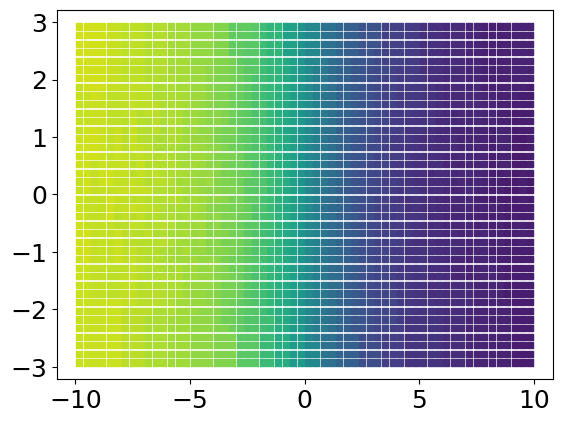

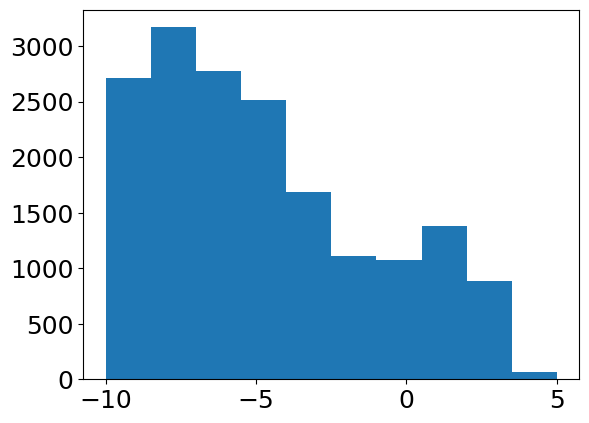

In [132]:
_v0 = v0[bin_mapping[:-1]]

plt.figure()
cb = plt.scatter(X_regular_grid, Y_regular_grid, c=_v0,
                s = 20, cmap='viridis', marker = 's', vmin = -200, vmax = 200)

plt.figure()
plt.hist(jnp.log(weights), range = [-10, 5]), weights,

In [1]:
from model import * 


import pickle

import jax
import jaxopt
import jax.nn as jnn
import jax.numpy as jnp
import jax.scipy as jsp
from functools import partial

import time as tt
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 18

import os
import corner
import numpy as np
import multiprocessing as mp

from potentials import *
from integrants_with_binning import *
from ghMoments import *
from utils import *
from constants import EPSILON

from potentials import NFW_acceleration
from densities import MiyamotoNagai_density
from sample_from_density import sample_from_density_grid

from CylindricalSpline import get_phi_m, get_acc, evaluate_phi_axisymmetric

# path = '/home/hz420/python_script/SchwarMAX/'
path = '/Users/hanyuan/Dropbox/python_script/SchwarMAX/'

def get_dict_data(path):

    with open(path + 'mock_Nbody_disc_bulge_XY_withRot.pkl', 'rb') as f:
        bin_dict = pickle.load(f)

    # voronoi binning mapping and data
    num_per_bin = jnp.array(bin_dict['num_per_bin'])
    total_bins = jnp.array(bin_dict['total_bins'])
    bin_mapping = jnp.array(bin_dict['bin_mapping'])
    surface_density = jnp.array(bin_dict['surface_density'])
    V_data = jnp.array(bin_dict['V_mean'])
    sigma_data = jnp.array(bin_dict['V_sigma'])
    h1_data = jnp.array(bin_dict['h1'])
    h2_data = jnp.array(bin_dict['h2'])
    h3_data = jnp.array(bin_dict['h3'])
    h4_data = jnp.array(bin_dict['h4'])
    v0 = jnp.array(bin_dict['v0'])
    s = jnp.array(bin_dict['s'])
    alpha, beta, gamma = bin_dict['orientation']

    V_data_err = jnp.where(0.1 * jnp.fabs(V_data) < 10, 10, 0.1 * V_data)
    sigma_data_err = jnp.where(0.1 * jnp.fabs(sigma_data) < 5, 5, 0.1 * sigma_data)
    h1_data_err = jnp.where(0.1 * jnp.fabs(h1_data) < 0.03, 0.03, 0.1 * jnp.fabs(h1_data))
    h2_data_err = jnp.where(0.1 * jnp.fabs(h2_data) < 0.03, 0.03, 0.1 * jnp.fabs(h2_data))
    h3_data_err = jnp.where(0.1 * jnp.fabs(h3_data) < 0.03, 0.03, 0.1 * jnp.fabs(h3_data))
    h4_data_err = jnp.where(0.1 * jnp.fabs(h4_data) < 0.03, 0.03, 0.1 * jnp.fabs(h4_data))

    # df_Rzphi_data = pd.read_csv(path + 'mock_axisymmetric_disc_Rzphi.csv')
    # Rzphi_density_data = jnp.array(df_Rzphi_data['mass'].to_numpy()).astype(jnp.float32)
    with open(path + 'mock_axisymmetric_disc_Rzphi.pkl', 'rb') as f:
        Rzphi_density_data = pickle.load(f)

    R_grid, z_grid, phi_grid = Rzphi_density_data['R_grid'], Rzphi_density_data['z_grid'], Rzphi_density_data['phi_grid']
    dR = np.unique(R_grid)[1] - np.unique(R_grid)[0]
    dz = np.unique(z_grid)[1] - np.unique(z_grid)[0]
    dphi = np.unique(phi_grid)[1] - np.unique(phi_grid)[0]
    sample_for_integration = Rzphi_density_data['sample_for_integration']

    from scipy.stats import qmc
    X_regular_grid, Y_regular_grid = bin_dict['X_regular_grid'], bin_dict['Y_regular_grid']
    dX = jnp.unique(X_regular_grid)[1] - jnp.unique(X_regular_grid)[0]
    dY = jnp.unique(Y_regular_grid)[1] - jnp.unique(Y_regular_grid)[0]
    sampler = qmc.Sobol(d=3, scramble=False)
    sample = sampler.random_base2(m=10)


    dict_data = {
        # 'w0': w0,
        'v0': v0,
        's': s,

        # 'Rzphi_density_data': Rzphi_density_data,
        'XY_density_data': surface_density,
        'V_data': V_data,
        'V_data_err': V_data_err,
        'sigma_data': sigma_data,
        'sigma_data_err': sigma_data_err,
        'h1_data': h1_data,
        'h1_data_err': h1_data_err,
        'h2_data': h2_data,
        'h2_data_err': h2_data_err,
        'h3_data': h3_data,
        'h3_data_err': h3_data_err,
        'h4_data': h4_data,
        'h4_data_err': h4_data_err,
        'num_per_bin': num_per_bin,
        'bin_mapping': bin_mapping,
        'total_bins': total_bins.item(),

        'R_grid': R_grid,
        'z_grid': z_grid,
        'phi_grid': phi_grid,
        'dR': dR,
        'dz': dz,
        'dphi': dphi,
        'sample_for_integration': sample_for_integration,

        'X_regular_grid': X_regular_grid,
        'Y_regular_grid': Y_regular_grid,
        'dX': dX,
        'dY': dY,
        'sample_for_integration_XY': sample,
    }

    return dict_data

In [2]:
    # df_ic = pd.read_csv(path + 'mock_initial_conditions_xyz.csv')
    # df_ic = df_ic[np.sqrt(df_ic['x']**2 + df_ic['y']**2) < 15.0]
    # df_ic = df_ic[np.fabs(df_ic['z']) < 5.0]

    # n_particles =  20_000
    # print(n_particles)
    # np.random.seed(42)
    # index = np.random.choice(len(df_ic['x']), size=n_particles, replace=False)
    # df_ic = df_ic.iloc[index]
    # # w0 = jnp.array([df_ic['x'], df_ic['y'], df_ic['z'], df_ic['vx'], df_ic['vy'], df_ic['vz']]).T
    # w0 = jnp.array(df_ic[['x','y','z']].to_numpy())
dict_data = get_dict_data(path)
@jax.jit
def density_func(x, y, z, params):
    """ Returns Stellar Density nu(R, z) """
    # Double Exponential Disk
    val = DoubleExponentialDisk_density(x, y, z, params) + Hernquist_density(x, y, z, params)
    return val

logMhalo_best_fit, logrho0_best_fit, logM_bulge_best_fit, logRh_disk_best_fit, logRs_disk_best_fit, logHs_disk_best_fit, logRs_bulge_best_fit,\
      alpha_best_fit, beta_best_fit, gamma_best_fit, logLM_best_fit = (11.8, 8.8, 10.4, 1.2, 0.45, -0.24, -0.1, 30*np.pi/180, 20*np.pi/180, 0*np.pi/180, 0)

alpha = alpha_best_fit * 180/np.pi
beta = beta_best_fit * 180/np.pi
gamma = gamma_best_fit * 180/np.pi
ground_truth = [logMhalo_best_fit,
                logrho0_best_fit,
                logM_bulge_best_fit,
                logRh_disk_best_fit,
                logRs_disk_best_fit,
                logHs_disk_best_fit,
                logRs_bulge_best_fit,
                alpha,
                beta,
                gamma,
                logLM_best_fit
]

params_halo_pot = {
    'logM': ground_truth[0],
    'Rs':10 ** ground_truth[3],
    'a':1.0,
    'b':1.0,
    'c':1.0,
    'x_origin':0.0,
    'y_origin':0.0,
    'z_origin':0.0,
    'dirx':0.0,
    'diry':0.0,
    'dirz':1.0
}

params_disk_rho = {
    'rho0_disc': 10 ** ground_truth[1],
    'Rd_disc': 10 ** ground_truth[4],
    'hz_disc': 10 ** ground_truth[5],
    'light_to_mass_ratio': 10 ** ground_truth[10],
    'x_origin': 0.0,
    'y_origin': 0.0,
    'z_origin': 0.0,
    'dirx': 0.0,
    'diry': 0.0,
    'dirz': 1.0,
    'alpha': ground_truth[7],
    'beta': ground_truth[8],
    'gamma': ground_truth[9],
    'logM_bulge': ground_truth[2],
    'Rs_bulge': 10 ** ground_truth[6]
}


bounds = jnp.array(
    [
        [-15.0, 15.0],  # x
        [-15.0, 15.0],  # y
        [-5.0, 5.0],    # z
    ],
    dtype=jnp.float32,
)

n_samples = 20_000
n_x = 48
n_y = 48
n_z = 32


key = jax.random.PRNGKey(0)
sample_ic_dict = sample_from_density_grid(
    key,
    density_func,
    params_disk_rho,
    bounds,
    n_samples=n_samples,
    n_x=n_x,
    n_y=n_y,
    n_z=n_z,
)
samples = np.asarray(sample_ic_dict["samples"])
dict_data['w0'] = jnp.array(samples)

In [3]:
dict_data['logl_density_max'] = -0.24
logMhalo_best_fit, logrho0_best_fit, logM_bulge_best_fit, logRh_disk_best_fit, logRs_disk_best_fit, logHs_disk_best_fit, logRs_bulge_best_fit,\
      alpha_best_fit, beta_best_fit, gamma_best_fit, logLM_best_fit = (11.8, 8.8, 10.4, 1.2, 0.45, -0.24, -0.1, 30*np.pi/180, 20*np.pi/180, 0*np.pi/180, 0)
# logMhalo_best_fit, logrho0_best_fit, logM_bulge_best_fit, logRh_disk_best_fit, logRs_disk_best_fit, logHs_disk_best_fit, logRs_bulge_best_fit,\
#       alpha_best_fit, beta_best_fit, gamma_best_fit, logLM_best_fit = (11.218750, 8.9, 10.4, 1.122504, 0.965337, -1.068458, -0.1, -0.932660, -0.564505, 0.245437, -0.218750)
disc_mass_tot = 10**logHs_disk_best_fit * 4 * np.pi * 10**(2*logRs_disk_best_fit) * 10**logHs_disk_best_fit  # Total mass from best-fit parameters


alpha = alpha_best_fit * 180/np.pi
beta = beta_best_fit * 180/np.pi
gamma = gamma_best_fit * 180/np.pi
ground_truth = [logMhalo_best_fit,
                logrho0_best_fit,
                logM_bulge_best_fit,
                logRh_disk_best_fit,
                logRs_disk_best_fit,
                logHs_disk_best_fit,
                logRs_bulge_best_fit,
                alpha,
                beta,
                gamma,
                logLM_best_fit
]

params_halo_pot = {
    'logM': ground_truth[0],
    'Rs':10 ** ground_truth[3],
    'a':1.0,
    'b':1.0,
    'c':1.0,
    'x_origin':0.0,
    'y_origin':0.0,
    'z_origin':0.0,
    'dirx':0.0,
    'diry':0.0,
    'dirz':1.0
}

params_disk_rho = {
    'rho0_disc': 10 ** ground_truth[1],
    'Rd_disc': 10 ** ground_truth[4],
    'hz_disc': 10 ** ground_truth[5],
    'light_to_mass_ratio': 10 ** ground_truth[10],
    'x_origin': 0.0,
    'y_origin': 0.0,
    'z_origin': 0.0,
    'dirx': 0.0,
    'diry': 0.0,
    'dirz': 1.0,
    'alpha': ground_truth[7],
    'beta': ground_truth[8],
    'gamma': ground_truth[9],
    'logM_bulge': ground_truth[2],
    'Rs_bulge': 10 ** ground_truth[6]
}

density_set, V_model, sigma_model, h1_set, h2_set, h3_set, h4_set,\
        density_unity_set, _V_model_unity, _sigma_model_unity, h1_unity_set, h2_unity_set, h3_unity_set, h4_unity_set,\
              weights = model_for_plotting(params_halo_pot, params_disk_rho, dict_data, dict_data['total_bins'])
V_model.block_until_ready()

print('Done')


ValueError: Non-hashable static arguments are not supported. An error occurred while trying to hash an object of type <class 'jax._src.interpreters.batching.BatchTracer'>, VmapTracer<~int32[]>. The error was:
TypeError: unhashable type: 'BatchTracer'


(array([ 599.,  772., 1001., 1308., 1509., 1366., 1240., 1001.,  807.,
         564.,  445.,  338.,  260.,  219.,  204.,  190.,  288.,  439.,
         601.,  795.,  795.,  693.,  493.,  373.,  280.,  198.,  134.,
         126.,   72.,   54.]),
 array([-10. ,  -9.5,  -9. ,  -8.5,  -8. ,  -7.5,  -7. ,  -6.5,  -6. ,
         -5.5,  -5. ,  -4.5,  -4. ,  -3.5,  -3. ,  -2.5,  -2. ,  -1.5,
         -1. ,  -0.5,   0. ,   0.5,   1. ,   1.5,   2. ,   2.5,   3. ,
          3.5,   4. ,   4.5,   5. ]),
 <BarContainer object of 30 artists>)

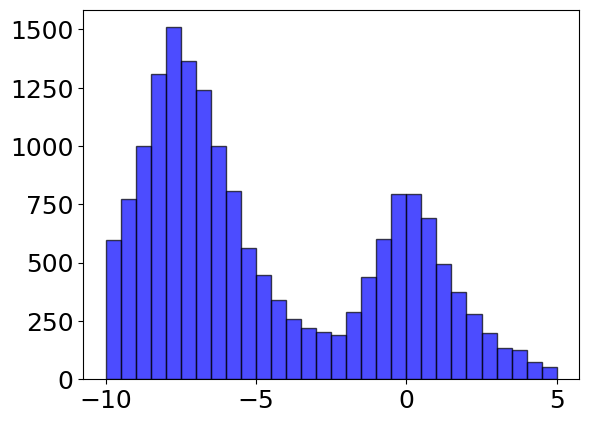

In [17]:
plt.hist(jnp.log(weights), range = [-10, 5], bins=30, alpha=0.7, color='blue', edgecolor='black')

In [10]:
(density_2DXY_data / mean_mass_per_orb - density_2DXY_weighted) / (density_2DXY_data / mean_mass_per_orb)

Array([0.33955666, 0.33955666, 0.33955666, ..., 0.3340666 , 0.3340666 ,
       0.3340666 ], dtype=float32)

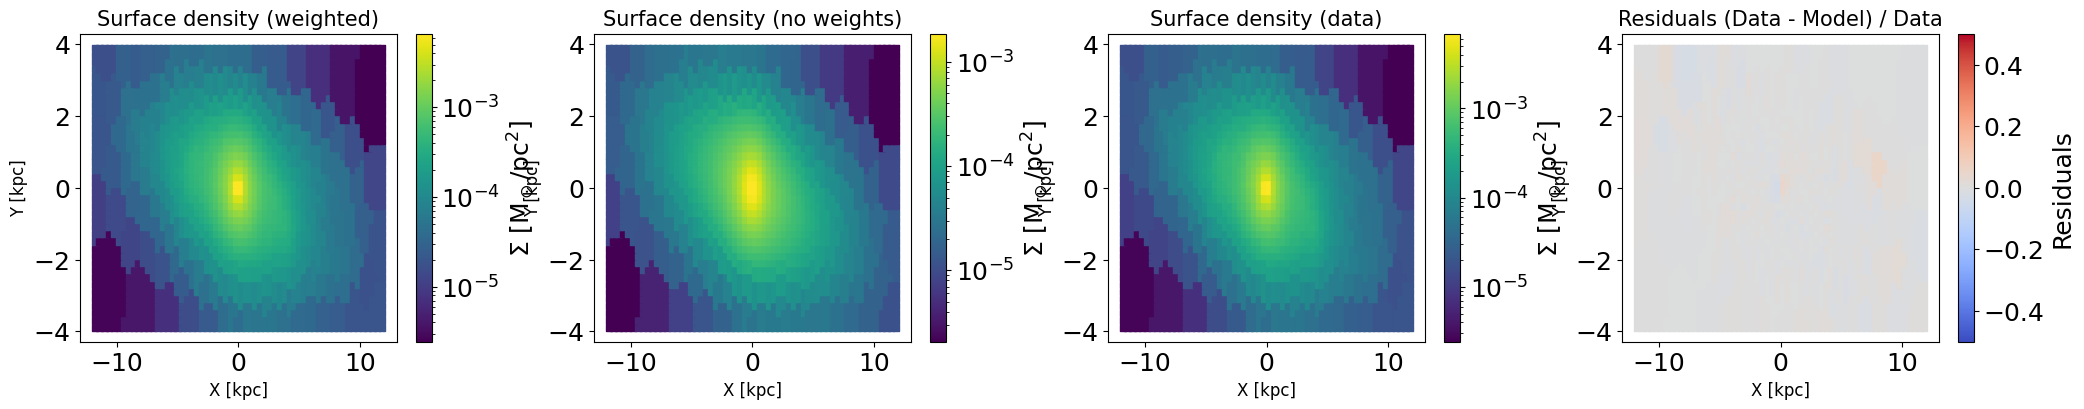

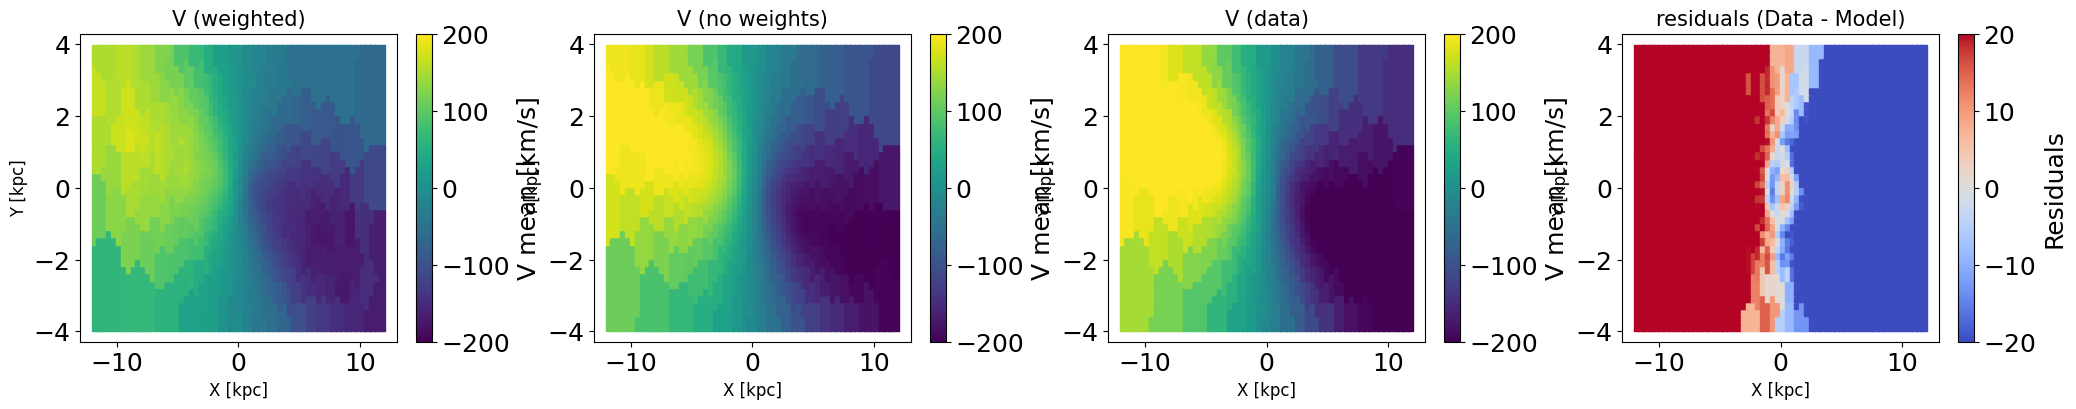

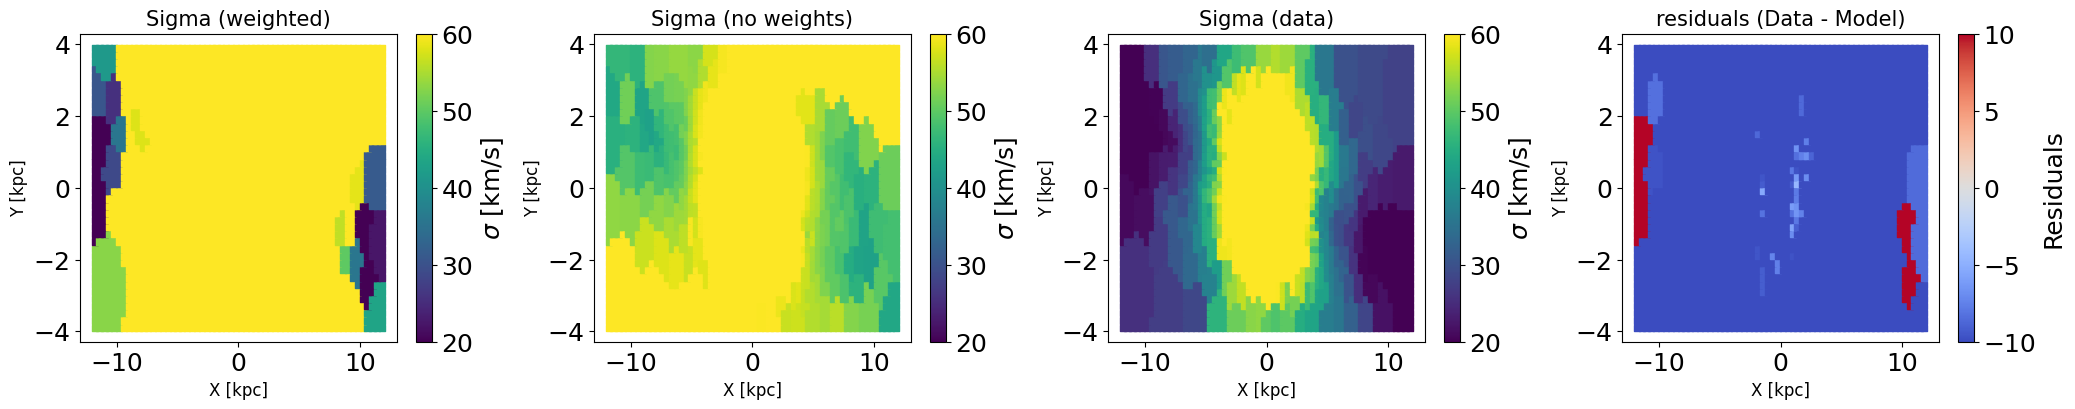

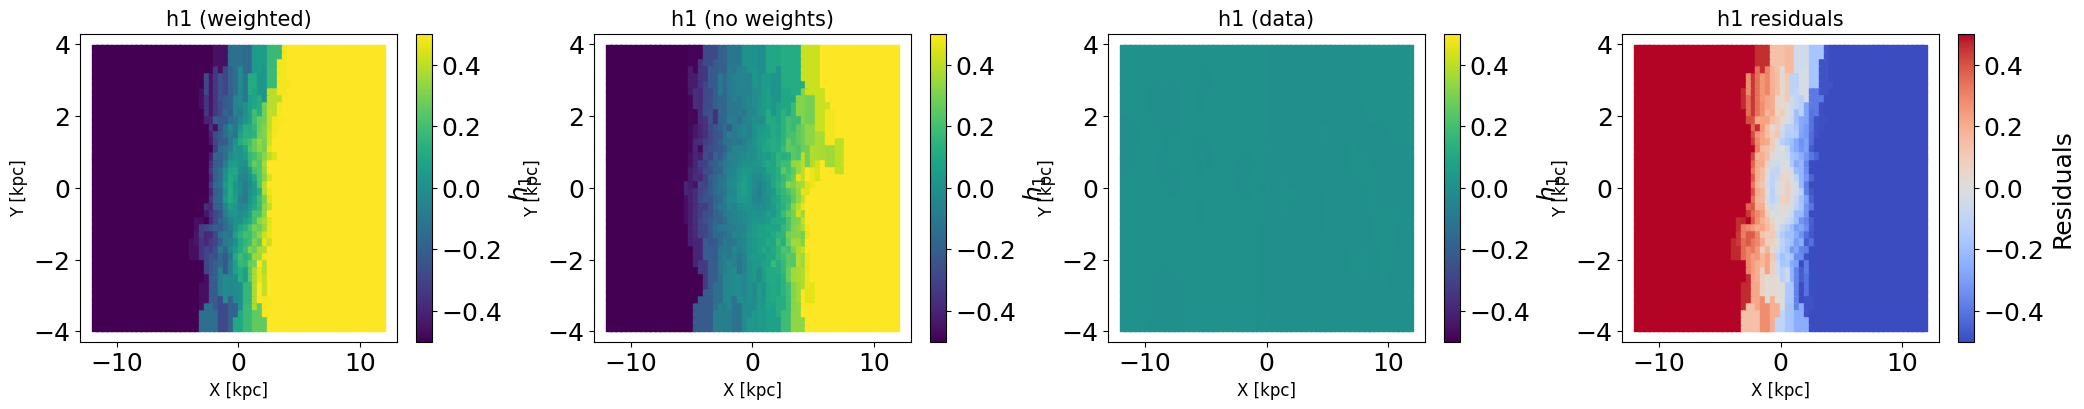

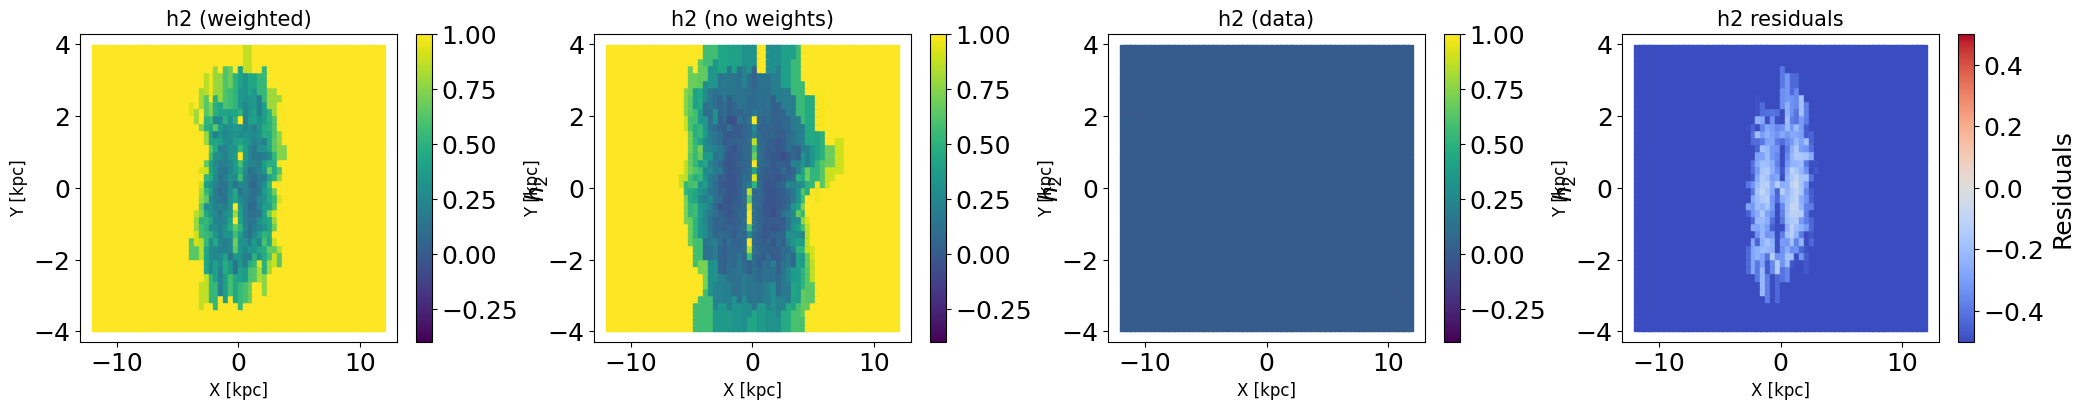

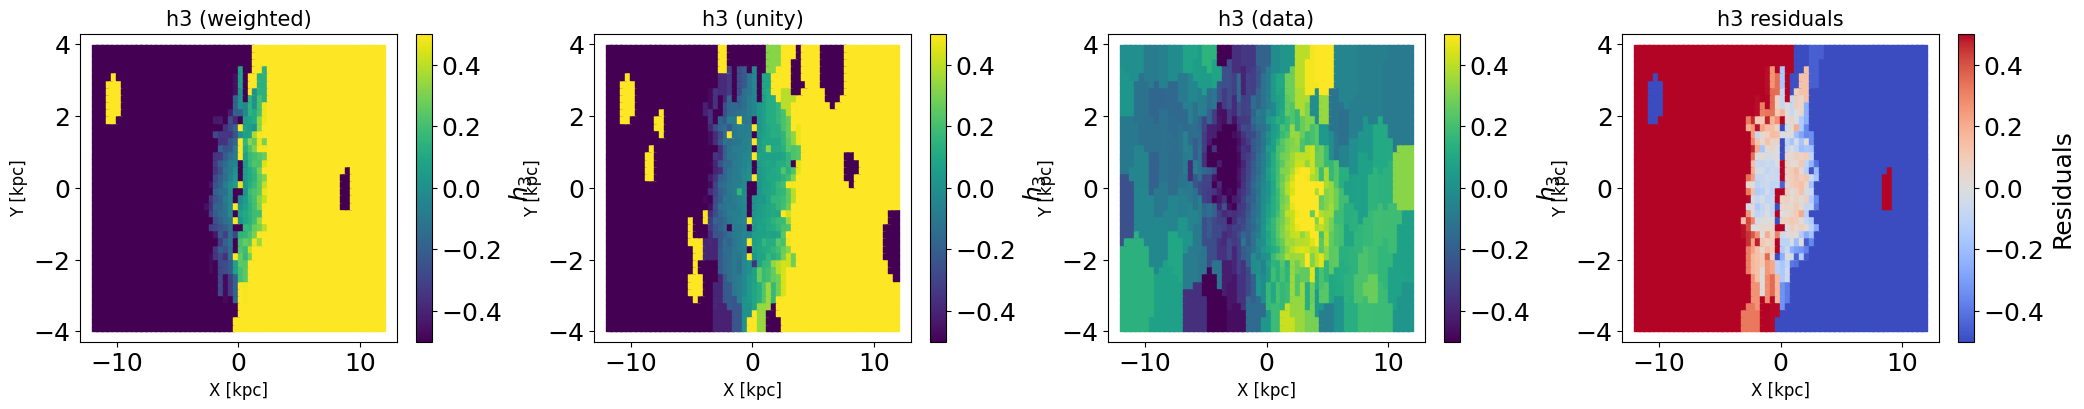

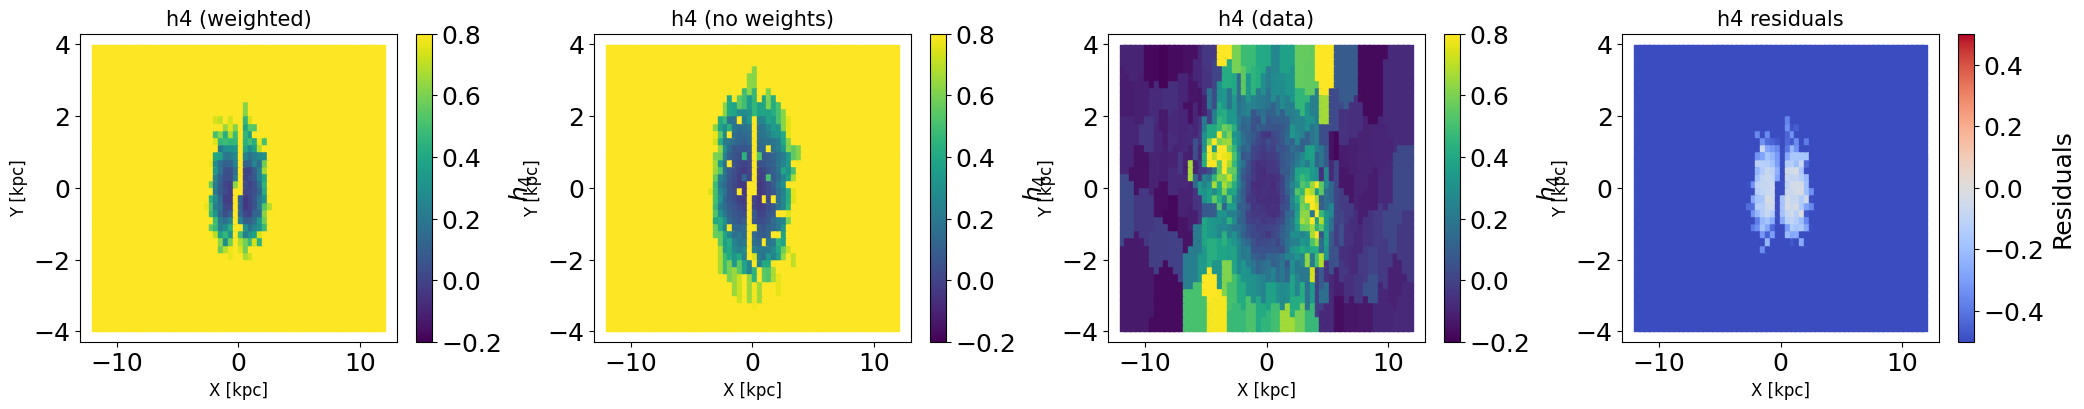

In [21]:
@jax.jit
def density_func(x, y, z, params):
    """ Returns Stellar Density nu(R, z) """
    # Double Exponential Disk
    val = DoubleExponentialDisk_density(x, y, z, params) + Hernquist_density(x, y, z, params)
    return val

@jax.jit
def density_func_Rz(R, z, phi, params):
    x = R * jnp.cos(phi)
    y = R * jnp.sin(phi)
    return density_func(x, y, z, params)

@partial(jax.jit, static_argnames=['rho_fct'])
def get_mass(R_grid, z_grid, phi_grid, rho_fct, dict_params, dR, dz, dphi, sample):
    R_samples = R_grid + (sample[:,0] - 0.5) * dR
    z_samples = z_grid + (sample[:,1] - 0.5) * dz
    phi_samples = phi_grid + (sample[:,2] - 0.5) * dphi
    density_samples = rho_fct(R_samples, z_samples, phi_samples, dict_params)
    mass_tot = jnp.sum(density_samples * R_samples) / sample.shape[0]
    return mass_tot

R_grid, dR = dict_data['R_grid'], dict_data['dR']
z_grid, dz = dict_data['z_grid'], dict_data['dz']
phi_grid, dphi = dict_data['phi_grid'], dict_data['dphi']
Rzphi_density_data = jax.vmap(get_mass, in_axes=[0, 0, 0, None, None, None, None, None, None])(
            R_grid, z_grid, phi_grid, density_func_Rz, params_disk_rho, dR, dz, dphi, dict_data['sample_for_integration']
)
bin_mapping = dict_data['bin_mapping']
mean_mass_per_orb = jnp.sum(Rzphi_density_data) / len(weights)
index_remap = bin_mapping[:-1]

density_2DXY, y_xy, sig_xy = density_set
h1_model, y_h1, sig_A1 = h1_set
h2_model, y_h2, sig_A2 = h2_set
h3_model, y_h3, sig_A3 = h3_set
h4_model, y_h4, sig_A4 = h4_set

density_2DXY_weighted = density_2DXY[index_remap]
V_model_weighted = V_model[index_remap]
sigma_model_weighted = sigma_model[index_remap]
h1_model_weighted = h1_model[index_remap]
h2_model_weighted = h2_model[index_remap]
h3_model_weighted = h3_model[index_remap]
h4_model_weighted = h4_model[index_remap]

density_2DXY_unity, y_xy, sig_xy = density_unity_set
h1_model_unity, y_h1, sig_A1 = h1_unity_set
h2_model_unity, y_h2, sig_A2 = h2_unity_set
h3_model_unity, y_h3, sig_A3 = h3_unity_set
h4_model_unity, y_h4, sig_A4 = h4_unity_set

density_2DXY_unity = density_2DXY_unity[index_remap]
V_model_unity = _V_model_unity[index_remap]
sigma_model_unity = _sigma_model_unity[index_remap]
h1_model_unity = h1_model_unity[index_remap]
h2_model_unity = h2_model_unity[index_remap]
h3_model_unity = h3_model_unity[index_remap]
h4_model_unity = h4_model_unity[index_remap]

surface_density = dict_data['XY_density_data']
V_data = dict_data['V_data']
sigma_data = dict_data['sigma_data']
h1_data = dict_data['h1_data']
h2_data = dict_data['h2_data']
h3_data = dict_data['h3_data']
h4_data = dict_data['h4_data']
X_regular_grid = dict_data['X_regular_grid']
Y_regular_grid = dict_data['Y_regular_grid']

density_2DXY_data = surface_density[index_remap]
V_model_data = V_data[index_remap]
sigma_model_data = sigma_data[index_remap]
h1_model_data = h1_data[index_remap]
h2_model_data = h2_data[index_remap]
h3_model_data = h3_data[index_remap]
h4_model_data = h4_data[index_remap]

density_2DXY_data = density_2DXY_data / mean_mass_per_orb

# fig1,ax1 = plt.subplots(2,4,figsize=(30,7), gridspec_kw={'hspace':0.5, 'wspace':0.3})
# fig1.suptitle('2D spatial and kinematic maps in Voronoi bins', fontsize=20, y = 1.03)
# cb1 = ax1[0,0].scatter(X_regular_grid, Y_regular_grid, c=density_2DXY_weighted, 
#                 s = 20, cmap='viridis', marker = 's', norm = 'log')
# fig1.colorbar(cb1, ax=ax1[0,0], label=r'$\Sigma$ [M$_\odot$/pc$^2$]')
# ax1[0,0].set_title('Surface density')
# ax1[0,0].set_xlabel('X [kpc]')
# ax1[0,0].set_ylabel('Y [kpc]')

fig0, ax0 = plt.subplots(1,4, figsize = (25,4), gridspec_kw={'hspace':0.5, 'wspace':0.3})

cb = ax0[0].scatter(X_regular_grid, Y_regular_grid, c=density_2DXY_weighted,
                s = 20, cmap='viridis', marker = 's', norm = 'log')
ax0[0].set_title('Surface density (weighted)', fontsize=15)
ax0[0].set_xlabel('X [kpc]', fontsize=12)
ax0[0].set_ylabel('Y [kpc]', fontsize=12)
fig0.colorbar(cb, ax=ax0[0], label=r'$\Sigma$ [M$_\odot$/pc$^2$]')

cb = ax0[1].scatter(X_regular_grid, Y_regular_grid, c=density_2DXY_unity,
                s = 20, cmap='viridis', marker = 's', norm = 'log')
ax0[1].set_title('Surface density (no weights)', fontsize=15)
ax0[1].set_xlabel('X [kpc]', fontsize=12)
ax0[1].set_ylabel('Y [kpc]', fontsize=12)
fig0.colorbar(cb, ax=ax0[1], label=r'$\Sigma$ [M$_\odot$/pc$^2$]')

cb = ax0[2].scatter(X_regular_grid, Y_regular_grid, c=density_2DXY_data,
                s = 20, cmap='viridis', marker = 's', norm = 'log')
ax0[2].set_title('Surface density (data)', fontsize=15)
ax0[2].set_xlabel('X [kpc]', fontsize=12)
ax0[2].set_ylabel('Y [kpc]', fontsize=12)
fig0.colorbar(cb, ax=ax0[2], label=r'$\Sigma$ [M$_\odot$/pc$^2$]')


res = (density_2DXY_data - density_2DXY_weighted) / (density_2DXY_data)
cb = ax0[3].scatter(X_regular_grid, Y_regular_grid, c=res,
                s = 20, cmap='coolwarm', marker = 's', vmin = -0.5, vmax = 0.5)
ax0[3].set_title('Residuals (Data - Model) / Data', fontsize=15)
ax0[3].set_xlabel('X [kpc]', fontsize=12)
ax0[3].set_ylabel('Y [kpc]', fontsize=12)
fig0.colorbar(cb, ax=ax0[3], label='Residuals')

# fig0.savefig('/data/hz420-2/SchwarMAX/plots/Mock_axisymmetric_disc_2Ddensity.png', bbox_inches='tight', dpi=300)
# =============================================================================================

fig1, ax1 = plt.subplots(1,4, figsize = (25,4), gridspec_kw={'hspace':0.5, 'wspace':0.3})

cb = ax1[0].scatter(X_regular_grid, Y_regular_grid, c=V_model_weighted,
                s = 20, cmap='viridis', marker = 's', vmin = -200, vmax = 200)
ax1[0].set_title('V (weighted)', fontsize=15)
ax1[0].set_xlabel('X [kpc]', fontsize=12)
ax1[0].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[0], label=r'V mean [km/s]')

cb = ax1[1].scatter(X_regular_grid, Y_regular_grid, c=V_model_unity,
                s = 20, cmap='viridis', marker = 's', vmin = -200, vmax = 200)
ax1[1].set_title('V (no weights)', fontsize=15)
ax1[1].set_xlabel('X [kpc]', fontsize=12)
ax1[1].set_ylabel('Y [kpc]', fontsize=12) 
fig1.colorbar(cb, ax=ax1[1], label=r'V mean [km/s]')

cb = ax1[2].scatter(X_regular_grid, Y_regular_grid, c=V_model_data,
                s = 20, cmap='viridis', marker = 's', vmin = -200, vmax = 200)
ax1[2].set_title('V (data)', fontsize=15)
ax1[2].set_xlabel('X [kpc]', fontsize=12)
ax1[2].set_ylabel('Y [kpc]', fontsize=12) 
fig1.colorbar(cb, ax=ax1[2], label=r'V mean [km/s]')

res = (V_model_data - V_model_weighted)
cb = ax1[3].scatter(X_regular_grid, Y_regular_grid, c=res,
                s = 20, cmap='coolwarm', marker = 's', vmin = -20, vmax = 20)
ax1[3].set_title('residuals (Data - Model)', fontsize=15)
ax1[3].set_xlabel('X [kpc]', fontsize=12)
ax1[3].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[3], label='Residuals')

# fig1.savefig('/data/hz420-2/SchwarMAX/plots/Mock_axisymmetric_disc_V_mean.png', bbox_inches='tight', dpi=300)
# =============================================================================================

fig1, ax1 = plt.subplots(1,4, figsize = (25,4), gridspec_kw={'hspace':0.5, 'wspace':0.3})

cb = ax1[0].scatter(X_regular_grid, Y_regular_grid, c=sigma_model_weighted,
                s = 20, cmap='viridis', marker = 's', vmin = 20, vmax = 60)
ax1[0].set_title('Sigma (weighted)', fontsize=15)
ax1[0].set_xlabel('X [kpc]', fontsize=12)
ax1[0].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[0], label=r'$\sigma$ [km/s]')

cb = ax1[1].scatter(X_regular_grid, Y_regular_grid, c=sigma_model_unity,
                s = 20, cmap='viridis', marker = 's', vmin = 20, vmax = 60)
ax1[1].set_title('Sigma (no weights)', fontsize=15)
ax1[1].set_xlabel('X [kpc]', fontsize=12)
ax1[1].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[1], label=r'$\sigma$ [km/s]')

cb = ax1[2].scatter(X_regular_grid, Y_regular_grid, c=sigma_model_data,
                s = 20, cmap='viridis', marker = 's', vmin = 20, vmax = 60)
ax1[2].set_title('Sigma (data)', fontsize=15)
ax1[2].set_xlabel('X [kpc]', fontsize=12)
ax1[2].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[2], label=r'$\sigma$ [km/s]')

res = (sigma_model_data - sigma_model_weighted)
cb = ax1[3].scatter(X_regular_grid, Y_regular_grid, c=res,
                s = 20, cmap='coolwarm', marker = 's', vmin = -10, vmax = 10)
ax1[3].set_title('residuals (Data - Model)', fontsize=15)
ax1[3].set_xlabel('X [kpc]', fontsize=12)
ax1[3].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[3], label='Residuals')

# fig1.savefig('/data/hz420-2/SchwarMAX/plots/Mock_axisymmetric_disc_Sigma.png', bbox_inches='tight', dpi=300)
# =============================================================================================

fig1, ax1 = plt.subplots(1,4, figsize = (25,4), gridspec_kw={'hspace':0.5, 'wspace':0.3})

cb = ax1[0].scatter(X_regular_grid, Y_regular_grid, c=h1_model_weighted,
                s = 20, cmap='viridis', marker = 's', vmin = -0.5, vmax = 0.5)
ax1[0].set_title('h1 (weighted)', fontsize=15)
ax1[0].set_xlabel('X [kpc]', fontsize=12)
ax1[0].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[0], label=r'$h_1$')

cb = ax1[1].scatter(X_regular_grid, Y_regular_grid, c=h1_model_unity,
                s = 20, cmap='viridis', marker = 's', vmin = -0.5, vmax = 0.5)
ax1[1].set_title('h1 (no weights)', fontsize=15)
ax1[1].set_xlabel('X [kpc]', fontsize=12)
ax1[1].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[1], label=r'$h_1$')

cb = ax1[2].scatter(X_regular_grid, Y_regular_grid, c=h1_model_data,
                s = 20, cmap='viridis', marker = 's', vmin = -0.5, vmax = 0.5)
ax1[2].set_title('h1 (data)', fontsize=15)
ax1[2].set_xlabel('X [kpc]', fontsize=12)
ax1[2].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[2], label=r'$h_1$')

res = (h1_model_data - h1_model_weighted)
cb = ax1[3].scatter(X_regular_grid, Y_regular_grid, c=res,
                s = 20, cmap='coolwarm', marker = 's', vmin = -0.5, vmax = 0.5)
ax1[3].set_title('h1 residuals', fontsize=15)
ax1[3].set_xlabel('X [kpc]', fontsize=12)
ax1[3].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[3], label='Residuals')

# fig1.savefig('/data/hz420-2/SchwarMAX/plots/Mock_axisymmetric_disc_h1.png', bbox_inches='tight', dpi=300)
# =============================================================================================

fig1, ax1 = plt.subplots(1,4, figsize = (25,4), gridspec_kw={'hspace':0.5, 'wspace':0.3})

cb = ax1[0].scatter(X_regular_grid, Y_regular_grid, c=h2_model_weighted,
                s = 20, cmap='viridis', marker = 's', vmin = -0.4, vmax = 1)
ax1[0].set_title('h2 (weighted)', fontsize=15)
ax1[0].set_xlabel('X [kpc]', fontsize=12)
ax1[0].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[0], label=r'$h_2$')

cb = ax1[1].scatter(X_regular_grid, Y_regular_grid, c=h2_model_unity,
                s = 20, cmap='viridis', marker = 's', vmin = -0.4, vmax = 1)
ax1[1].set_title('h2 (no weights)', fontsize=15)
ax1[1].set_xlabel('X [kpc]', fontsize=12)
ax1[1].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[1], label=r'$h_2$')

cb = ax1[2].scatter(X_regular_grid, Y_regular_grid, c=h2_model_data,
                s = 20, cmap='viridis', marker = 's', vmin = -0.4, vmax = 1)
ax1[2].set_title('h2 (data)', fontsize=15)
ax1[2].set_xlabel('X [kpc]', fontsize=12)
ax1[2].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[2], label=r'$h_2$')

res = (h2_model_data - h2_model_weighted)
cb = ax1[3].scatter(X_regular_grid, Y_regular_grid, c=res,
                s = 20, cmap='coolwarm', marker = 's', vmin = -0.5, vmax = 0.5)
ax1[3].set_title('h2 residuals', fontsize=15)
ax1[3].set_xlabel('X [kpc]', fontsize=12)
ax1[3].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[3], label='Residuals')

# fig1.savefig('/data/hz420-2/SchwarMAX/plots/Mock_axisymmetric_disc_h2.png', bbox_inches='tight', dpi=300)
# =============================================================================================

fig1, ax1 = plt.subplots(1,4, figsize = (25,4), gridspec_kw={'hspace':0.5, 'wspace':0.3})

cb = ax1[0].scatter(X_regular_grid, Y_regular_grid, c=h3_model_weighted,
                s = 20, cmap='viridis', marker = 's', vmin = -0.5, vmax = 0.5)
ax1[0].set_title('h3 (weighted)', fontsize=15)
ax1[0].set_xlabel('X [kpc]', fontsize=12)
ax1[0].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[0], label=r'$h_3$')

cb = ax1[1].scatter(X_regular_grid, Y_regular_grid, c=h3_model_unity,
                s = 20, cmap='viridis', marker = 's', vmin = -0.5, vmax = 0.5)
ax1[1].set_title('h3 (unity)', fontsize=15)
ax1[1].set_xlabel('X [kpc]', fontsize=12)
ax1[1].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[1], label=r'$h_3$')

cb = ax1[2].scatter(X_regular_grid, Y_regular_grid, c=h3_model_data,
                s = 20, cmap='viridis', marker = 's', vmin = -0.5, vmax = 0.5)
ax1[2].set_title('h3 (data)', fontsize=15)
ax1[2].set_xlabel('X [kpc]', fontsize=12)
ax1[2].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[2], label=r'$h_3$')

res = (h3_model_data - h3_model_weighted)
cb = ax1[3].scatter(X_regular_grid, Y_regular_grid, c=res,
                s = 20, cmap='coolwarm', marker = 's', vmin = -0.5, vmax = 0.5)
ax1[3].set_title('h3 residuals', fontsize=15)
ax1[3].set_xlabel('X [kpc]', fontsize=12)
ax1[3].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[3], label='Residuals')

# fig1.savefig('/data/hz420-2/SchwarMAX/plots/Mock_axisymmetric_disc_h3.png', bbox_inches='tight', dpi=300)
# =============================================================================================

fig1, ax1 = plt.subplots(1,4, figsize = (25,4), gridspec_kw={'hspace':0.5, 'wspace':0.3})

cb = ax1[0].scatter(X_regular_grid, Y_regular_grid, c=h4_model_weighted,
                s = 20, cmap='viridis', marker = 's', vmin = -0.2, vmax = 0.8)
ax1[0].set_title('h4 (weighted)', fontsize=15)
ax1[0].set_xlabel('X [kpc]', fontsize=12)
ax1[0].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[0], label=r'$h_4$')

cb = ax1[1].scatter(X_regular_grid, Y_regular_grid, c=h4_model_unity,
                s = 20, cmap='viridis', marker = 's', vmin = -0.2, vmax = 0.8)
ax1[1].set_title('h4 (no weights)', fontsize=15)
ax1[1].set_xlabel('X [kpc]', fontsize=12)
ax1[1].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[1], label=r'$h_4$')

cb = ax1[2].scatter(X_regular_grid, Y_regular_grid, c=h4_model_data,
                s = 20, cmap='viridis', marker = 's', vmin = -0.2, vmax = 0.8)
ax1[2].set_title('h4 (data)', fontsize=15)
ax1[2].set_xlabel('X [kpc]', fontsize=12)
ax1[2].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[2], label=r'$h_4$')

res = (h4_model_data - h4_model_weighted)
cb = ax1[3].scatter(X_regular_grid, Y_regular_grid, c=res,
                s = 20, cmap='coolwarm', marker = 's', vmin = -0.5, vmax = 0.5)
ax1[3].set_title('h4 residuals', fontsize=15)
ax1[3].set_xlabel('X [kpc]', fontsize=12)
ax1[3].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[3], label='Residuals')
# fig1.savefig('/data/hz420-2/SchwarMAX/plots/Mock_axisymmetric_disc_h4.png', bbox_inches='tight', dpi=300)

In [6]:
from utils import estimate_orbital_timescale

@jax.jit
def potential_func(x, y, z, dict_phi, params_halo):
    """ Returns Phi(R, z) """
    phi_halo = NFW_potential(x, y, z, params_halo)
    phi_disk = evaluate_phi_axisymmetric(x, y, z, dict_phi)
    return phi_halo + phi_disk

@jax.jit
def density_func(x, y, z, params):
    """ Returns Stellar Density nu(R, z) """
    # Double Exponential Disk
    val = DoubleExponentialDisk_density(x, y, z, params) + Hernquist_density(x, y, z, params)
    return val

NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax = 50, 30, 1e-2, 30.0, 1e-3, 15.0, 8.
Nphi = 200
N_int = 10_000
dict_phi = get_phi_m(density_func, params_disk_rho, NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax, Nphi, N_int)

T = estimate_orbital_timescale(
    R=8.0,
    potential_fn=potential_func,              # potential_func(x,y,z,dict_phi,params_halo)
    potential_args=(dict_phi, params_halo_pot),
    z=0.0,
)

print(T * 1e3)

214.69904


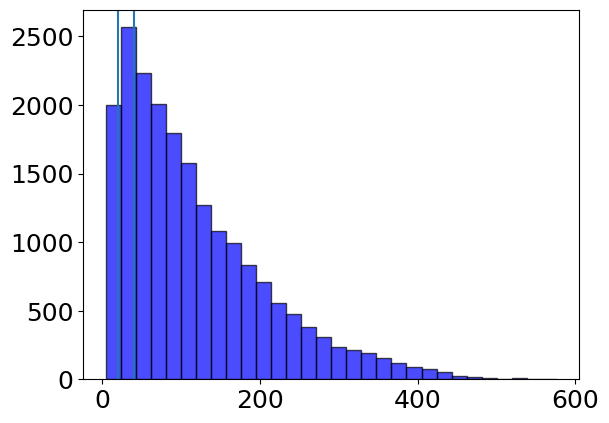

In [7]:
R_stars = jnp.sqrt(dict_data['w0'][:,0]**2 + dict_data['w0'][:,1]**2)
z_star = dict_data['w0'][:,2]

T = estimate_orbital_timescale(
    R=R_stars,
    potential_fn=potential_func,              # potential_func(x,y,z,dict_phi,params_halo)
    potential_args=(dict_phi, params_halo_pot),
    z=0.0,
)

T = jax.vmap(estimate_orbital_timescale, in_axes=(0, None, None, 0))(
    R_stars,
    potential_func,
    (dict_phi, params_halo_pot),
    z_star
)

plt.hist(T * 1e3, bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(40)
plt.axvline(20)

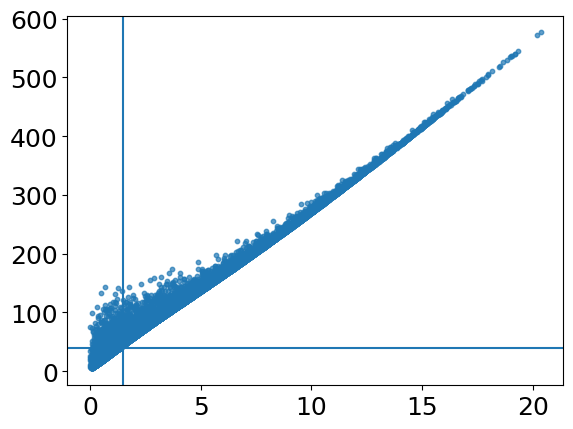

In [12]:
plt.scatter(R_stars, T * 1e3, s=10, alpha=0.7)
plt.axhline(40)
plt.axvline(1.5)

In [7]:
w0 = dict_data['w0']
w0.at[T*1e3<40]

_IndexUpdateRef(Array([[ -0.6204409 ,   0.01305699,  -0.4433042 ],
       [  2.1011488 ,   0.13939857,  -0.2752224 ],
       [ -0.5466002 ,   0.38551873,   0.02968978],
       ...,
       [  0.8968412 ,   0.6787028 ,   0.5051278 ],
       [ -2.4164627 , -10.366319  ,   1.8721143 ],
       [ -0.9216813 ,  -0.6348406 ,   0.5737654 ]], dtype=float32), Array(False, dtype=bool))